# Customer Churn Prediction — Telco

**Business problem.** A telecom operator wants to know which customers are likely to leave, so the
retention team can engage them before they go. Replacing a customer costs considerably more than
keeping one, so the deliverable is a ranked list of who to contact.

**Dataset.** IBM Telco Customer Churn — 7,043 customers, 21 columns.
**Target.** `Churn` (Yes / No).
**Model.** Decision Tree Classifier, 70:30 split, `random_state = 42`.

| Section | Contents |
|---|---|
| 0 | Setup |
| 1 | Data understanding & preparation |
| 2–7 | EDA, feature engineering, model development, evaluation, interpretation, saved model + API |

Run the cells top to bottom. The notebook reads the dataset via the relative path `../data/`, so it
must be run from inside the `notebook/` directory.

## 0. Setup

Imports and the constants used throughout. `RANDOM_STATE = 42` is mandated by the brief and is the
only seed used anywhere in the notebook.

Two library notes, because both change how the code below has to be written. **pandas 3.0** gives
text columns a dedicated `str` dtype rather than `object`, and copy-on-write is the default, so
chained assignment silently does nothing. **scikit-learn 1.9** uses `sparse_output=` on
`OneHotEncoder` (the old `sparse=` was removed) and can return pandas DataFrames from transformers
via `set_output`.

In [1]:
from io import BytesIO

import joblib
import numpy as np
import pandas as pd
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# The brief mandates this seed; it is the only one used in the notebook.
RANDOM_STATE = 42

DATA_PATH = "../data/TelcoCustomerChurn.csv"
DICT_PATH = "../data/TelcoCustomerChurn - Data Dictionary.csv"
TARGET = "Churn"
ID_COL = "customerID"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__}")

pandas 3.0.5 | numpy 2.5.3 | scikit-learn 1.9.1


---

# 1. Data Understanding & Preparation

This section establishes what the data is, fixes what is wrong with it, and produces the train/test
split and the encoding recipe that every later section depends on.

Two constraints from the brief shape how it is ordered. **No data leakage:** nothing may be fitted
before the split, so the split at 1.10 is the boundary and the only `.fit` call in this section sits
below it. **Preprocessing must apply consistently to new data:** so the encoding is built as a
single scikit-learn object that can be pickled and reused on one unseen customer at a time, which
1.13 demonstrates.

## 1.1 Loading the data

One row is one customer at one point in time, so the prediction unit is a customer. The file is read
exactly as it sits on disk — no `na_values`, no `dtype=` overrides — because the point of the next
few cells is to *find* the defects rather than paper over them during load.

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}    Columns: {df.shape[1]}")
print(f"In-memory size: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Rows: 7,043    Columns: 21
In-memory size: 7.2 MB


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1.2 Data type and structure checks

The dtype pandas infers is a claim worth verifying, not trusting. A column of numbers stored as text
is the most common defect in a CSV and it is silent: nothing errors, the feature simply never
reaches the model.

Rather than eyeball the dtypes, the check below reads the supplied data dictionary
(`TelcoCustomerChurn - Data Dictionary.csv`) and compares the *declared* type of every column
against what pandas actually loaded.

In [3]:
df.info()

data_dict = pd.read_csv(DICT_PATH)
declared = dict(zip(data_dict["Column"], data_dict["Data Type"]))

structure = pd.DataFrame({
    "column": df.columns,
    "pandas_dtype": [str(df[c].dtype) for c in df.columns],
    "declared_type": [declared[c] for c in df.columns],
    "n_unique": [df[c].nunique() for c in df.columns],
    "example": [df[c].iloc[0] for c in df.columns],
})

# A column the dictionary calls "Numerical" should have landed as an int or a float.
declared_numeric = structure["declared_type"].str.contains("Numerical")
stored_numeric = [pd.api.types.is_numeric_dtype(df[c]) for c in df.columns]
structure["agrees"] = declared_numeric == stored_numeric

print("\n--- declared type (data dictionary) vs stored dtype (pandas) ---")
print(structure.to_string(index=False))

mismatch = structure.loc[~structure["agrees"]]
print(f"\nColumns where the two disagree: {len(mismatch)}")
print(mismatch[["column", "declared_type", "pandas_dtype"]].to_string(index=False))

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 1.3 Diagnosing the mis-typed column

`TotalCharges` is declared numerical but arrived as text, so something in it will not parse.
`pd.to_numeric(..., errors="coerce")` turns unparseable values into `NaN`, which locates the
offending rows without modifying anything yet.

The question that matters is not how many bad rows there are but *what kind of customer* they are,
because that is what decides whether to drop them or impute them.

In [4]:
coerced = pd.to_numeric(df["TotalCharges"], errors="coerce")
bad = coerced.isna()

print(f"Rows where TotalCharges will not parse as a number: {bad.sum()}")
print(f"Distinct raw values in those cells: {[repr(v) for v in df.loc[bad, 'TotalCharges'].unique()]}")
print(f"Their tenure values   : {sorted(df.loc[bad, 'tenure'].unique().tolist())}")
print(f"Their Churn values    : {df.loc[bad, 'Churn'].value_counts().to_dict()}")
print(f"Their Contract values : {df.loc[bad, 'Contract'].value_counts().to_dict()}")

print(f"\nRows in the WHOLE dataset with tenure == 0: {(df['tenure'] == 0).sum()}")
print("-> the unparseable rows and the zero-tenure rows are the same 11 customers.")

# Corroboration: for every billed customer, TotalCharges tracks MonthlyCharges x tenure.
billed = df["tenure"] > 0
ratio = coerced[billed] / (df.loc[billed, "MonthlyCharges"] * df.loc[billed, "tenure"])
print("\nTotalCharges / (MonthlyCharges x tenure) for customers with tenure > 0:")
print(f"  median {ratio.median():.3f} | 5th pct {ratio.quantile(0.05):.3f} | 95th pct {ratio.quantile(0.95):.3f}")
print("-> that relationship evaluated at tenure == 0 gives exactly 0.")

df.loc[bad, [ID_COL, "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]]

Rows where TotalCharges will not parse as a number: 11
Distinct raw values in those cells: ["' '"]
Their tenure values   : [0]
Their Churn values    : {'No': 11}
Their Contract values : {'Two year': 10, 'One year': 1}

Rows in the WHOLE dataset with tenure == 0: 11
-> the unparseable rows and the zero-tenure rows are the same 11 customers.

TotalCharges / (MonthlyCharges x tenure) for customers with tenure > 0:
  median 1.000 | 5th pct 0.924 | 95th pct 1.075
-> that relationship evaluated at tenure == 0 gives exactly 0.


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


### What this shows

`TotalCharges` is the only disagreement with the data dictionary, and the cause is 11 cells holding
a **single space**. Pandas types a column by its worst value, so one non-numeric entry demoted the
whole column to text — and a headline spend figure would have been silently skipped by any
`select_dtypes("number")` call.

All 11 rows have `tenure == 0`, and they are the *only* zero-tenure rows in the dataset. All 11 have
`Churn == "No"` and 10 of the 11 are on two-year contracts. These are brand-new customers: signed
up, monthly charge set, but no billing cycle has closed yet.

That makes the value **knowable rather than missing**. Lifetime spend for someone billed zero times
is zero — a fact the ETL wrote as blank. The ratio check corroborates it: for every billed customer
`TotalCharges` tracks `MonthlyCharges × tenure` at a median ratio of 1.000, and that relationship at
`tenure == 0` gives exactly 0. Mean-imputing instead would assign a day-one customer roughly $2,283
of history they do not have. Section 1.8 therefore fills `0.0` and keeps all 11 customers.

## 1.4 Missing-value analysis

`isna()` only recognises `NaN`, `None` and `NaT`. It does not catch a whitespace string, the text
`"unknown"`, a `-1` sentinel, or a category that means "not applicable" — so a dataset can report
zero nulls and still be full of absent information. This section therefore runs three passes rather
than one.

In [5]:
# Pass 1 - the standard check.
print("--- pass 1: df.isna().sum() ---")
print(df.isna().sum().to_string())
print(f"\nTotal recognised nulls across all {df.shape[1]} columns: {df.isna().sum().sum()}")

# Pass 2 - whitespace-only strings, which isna() cannot see.
text_cols = df.select_dtypes(include="str").columns
blank = {c: int((df[c].astype("str").str.strip() == "").sum()) for c in text_cols}
blank = {c: n for c, n in blank.items() if n > 0}
print(f"\n--- pass 2: whitespace-only cells ---")
print(blank if blank else "none")

# Pass 3 - categories that encode "not applicable".
ADDONS = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
          "TechSupport", "StreamingTV", "StreamingMovies"]

print("\n--- pass 3: sentinel levels in the service columns ---")
print(f"'No internet service' : {(df[ADDONS[0]] == 'No internet service').sum():,} rows, "
      f"in each of {len(ADDONS)} add-on columns")
print(f"'No phone service'    : {(df['MultipleLines'] == 'No phone service').sum():,} rows, "
      f"in MultipleLines only")

print("\nAre those sentinels structural, i.e. fully determined by the parent column?")
for c in ADDONS:
    same = ((df[c] == "No internet service") == (df["InternetService"] == "No")).all()
    print(f"  {c:18s} 'No internet service' <=> InternetService == 'No' : {same}")
same = ((df["MultipleLines"] == "No phone service") == (df["PhoneService"] == "No")).all()
print(f"  {'MultipleLines':18s} 'No phone service'    <=> PhoneService == 'No'    : {same}")

--- pass 1: df.isna().sum() ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0

Total recognised nulls across all 21 columns: 0

--- pass 2: whitespace-only cells ---
{'TotalCharges': 11}

--- pass 3: sentinel levels in the service columns ---
'No internet service' : 1,526 rows, in each of 6 add-on columns
'No phone service'    : 682 rows, in MultipleLines only

Are those sentinels structural, i.e. fully determined by the parent column?
  OnlineSecurity     'No internet service' <=> InternetService == 'No' : True
  OnlineBackup       'No internet service' <=> InternetService == 

### What this shows

The standard check reports **zero nulls in all 21 columns**, and that is misleading. The dtype is
pandas' `StringDtype`, under which `' '` is perfectly valid string content, so the 11 broken
`TotalCharges` cells are invisible to `isna()`. The whitespace sweep is what finds them.

The sentinel audit turns up two more markers, and both are **structural rather than missing**:

| Marker | Columns | Rows | Determined by |
|---|---|---|---|
| `No internet service` | 6 add-on columns | 1,526 each | `InternetService == "No"` |
| `No phone service` | `MultipleLines` | 682 | `PhoneService == "No"` |

The checks above confirm each marker appears *if and only if* the parent column says so —
exhaustively, with no exceptions. So there is no missingness mechanism to model here: the value is a
deterministic function of another column and records a real fact about the customer ("has no online
backup, because they have no internet"). Both are kept as their own level. Collapsing them into
`"No"` would merge two genuinely different groups — customers who declined an add-on, and customers
who could not buy one — and section 2 will show those groups behave differently.

## 1.5 Duplicate analysis

Three different questions, and the second matters most. Fully identical rows are a data-quality
fault. A repeated **identifier** is worse: the same customer could land in both the train and test
sets, which inflates the test score for no real reason. Rows that match once the identifier is
ignored are a third case, and one that needs interpreting rather than fixing.

In [6]:
print(f"Fully duplicated rows               : {df.duplicated().sum()}")
print(f"Duplicated customerID values        : {df[ID_COL].duplicated().sum()}")
print(f"Unique customerIDs                  : {df[ID_COL].nunique():,} of {len(df):,} rows")
print(f"Duplicated rows ignoring customerID : {df.drop(columns=[ID_COL]).duplicated().sum()}")

print("\nThe last figure counts distinct customers who happen to share an attribute profile")
print("(e.g. short-tenure, phone-only, month-to-month). That is expected in a 19-field")
print("categorical space, is not a data fault, and carries no train/test leakage risk because")
print("each is a genuinely separate customer. Nothing is dropped.")

Fully duplicated rows               : 0
Duplicated customerID values        : 0
Unique customerIDs                  : 7,043 of 7,043 rows


Duplicated rows ignoring customerID : 22

The last figure counts distinct customers who happen to share an attribute profile
(e.g. short-tenure, phone-only, month-to-month). That is expected in a 19-field
categorical space, is not a data fault, and carries no train/test leakage risk because
each is a genuinely separate customer. Nothing is dropped.


## 1.6 Numerical and categorical feature identification

These lists drive the encoder, so getting them right prevents a whole class of downstream bug. It is
a modelling decision rather than a dtype lookup, because dtype misleads in both directions here:
`TotalCharges` is numeric but stored as text, and `SeniorCitizen` is stored as `int64` but is really
a binary flag — there is no meaningful "1.5 senior citizens".

`SeniorCitizen` therefore gets its own list. One-hot encoding it would emit a perfectly collinear
pair of columns carrying a single bit, and passthrough is also the safer route at inference time: a
`OneHotEncoder` fitted on `int64` silently encodes the string `"1"` as *neither* level, whereas a
passthrough column either works or fails loudly on dtype.

`customerID` is excluded from the model entirely. It is unique per row, so a tree given it could
split every customer into their own leaf and score near-perfectly on train — and it carries no
transferable signal, because every customer arriving in production has an ID the model has never
seen.

In [7]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
binary_features = ["SeniorCitizen"]
categorical_features = [
    c for c in df.columns
    if c not in numeric_features + binary_features + [TARGET, ID_COL]
]

# Coverage and disjointness. These asserts catch a typo here rather than as a
# KeyError halfway through section 4.
assert (set(numeric_features) | set(binary_features) | set(categorical_features)
        | {TARGET, ID_COL}) == set(df.columns), "feature lists do not cover every column"
assert not set(numeric_features) & set(binary_features)
assert not set(numeric_features) & set(categorical_features)
assert not set(binary_features) & set(categorical_features)
assert len(categorical_features) == 15

print(f"numeric_features     ({len(numeric_features)}): {numeric_features}")
print(f"binary_features      ({len(binary_features)}): {binary_features}")
print(f"categorical_features ({len(categorical_features)}): {categorical_features}")
print(f"target: {TARGET!r}  |  excluded identifier: {ID_COL!r}")
print(f"\nCoverage: {len(numeric_features)} + {len(binary_features)} + "
      f"{len(categorical_features)} + target + id = {df.shape[1]} columns. Asserts passed.")

print("\nWhy these are hand-declared rather than inferred:")
print(f"  select_dtypes('number') returns {df.select_dtypes(include='number').columns.tolist()}")
print("  -> wrong on both ends: it picks up SeniorCitizen (a binary flag) and")
print("     misses TotalCharges (still text at this point in the notebook).")

print("\n--- cardinality of the categorical features ---")
print(df[categorical_features].nunique().sort_values().to_string())

numeric_features     (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
binary_features      (1): ['SeniorCitizen']
categorical_features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
target: 'Churn'  |  excluded identifier: 'customerID'

Coverage: 3 + 1 + 15 + target + id = 21 columns. Asserts passed.

Why these are hand-declared rather than inferred:
  select_dtypes('number') returns ['SeniorCitizen', 'tenure', 'MonthlyCharges']
  -> wrong on both ends: it picks up SeniorCitizen (a binary flag) and
     misses TotalCharges (still text at this point in the notebook).

--- cardinality of the categorical features ---
gender              2
Partner             2
Dependents          2
PhoneService        2
PaperlessBilling    2
MultipleLines       3
OnlineSecurity      3
InternetService     3
On

## 1.7 Target-variable analysis

The class balance decides which metrics mean anything. If most customers do not churn, a model that
predicts "No" for everyone scores well on accuracy while being useless to the retention team — and
that number is the baseline every later result has to be judged against.

Numbers only here. The churn-distribution chart belongs to section 2, where the brief asks for it as
one of the required visualisations.

In [8]:
counts = df[TARGET].value_counts()
pct = df[TARGET].value_counts(normalize=True).reindex(counts.index) * 100

print(pd.DataFrame({"count": counts, "percent": pct.round(3)}).to_string())

baseline = counts.max() / len(df)
print(f"\nChurn rate                       : {pct['Yes']:.2f}%")
print(f"Class ratio (No : Yes)           : {counts['No'] / counts['Yes']:.2f} : 1")
print(f"Majority-class baseline accuracy : {baseline:.2%}   <-- the number section 5 must beat")
print(f"\nA model predicting 'No' for all {len(df):,} customers scores {baseline:.2%} accuracy")
print(f"and identifies 0 of the {counts['Yes']:,} churners. Accuracy alone cannot detect that.")

       count  percent
Churn                
No      5174   73.463
Yes     1869   26.537

Churn rate                       : 26.54%
Class ratio (No : Yes)           : 2.77 : 1
Majority-class baseline accuracy : 73.46%   <-- the number section 5 must beat

A model predicting 'No' for all 7,043 customers scores 73.46% accuracy
and identifies 0 of the 1,869 churners. Accuracy alone cannot detect that.


### What this shows

1,869 of 7,043 customers churned — **26.54%** — so the majority-class baseline is **73.46%
accuracy**. Any accuracy figure in section 5 that is not clearly above 73.46% means the model has
learned nothing.

At roughly 2.8:1 the imbalance is mild. For comparison, credit-card fraud runs nearer 580:1, where
resampling or an anomaly-detection framing is needed just to get a model that predicts the positive
class at all. Here one training row in four is a churner, which is ample signal for a decision tree,
so no resampling is required.

What the imbalance does change is the **choice of metric**: accuracy is flattered by the 73.46%
floor, so section 5 leads on recall and precision for the churn class rather than on accuracy.
`class_weight="balanced"` is still worth testing in section 4 as one of the compared configurations.

## 1.8 Data cleaning

Acting on what the previous cells found. The cell works on a copy so `df` stays pristine and the cell
is safe to re-run.

| Decision | Why |
|---|---|
| `TotalCharges` → numeric | The data dictionary declares it numerical; a single space made pandas type the whole column as text. |
| The 11 `NaN` → `0.0` | `tenure == 0` means no billing cycle has closed, so lifetime spend is a *known* 0. Mean imputation would invent ≈ $2,283 for a never-billed customer. |
| Drop `customerID` | Unique per row: memorisable by a tree, and meaningless for a customer the model has never seen. |
| Keep all 7,043 rows | No duplicates and no true missingness. Dropping the 11 would delete the entire new-joiner segment, which is exactly the cohort retention cares about. |
| Keep the service sentinels as levels | Proved structural at 1.4 — they record which product a customer holds, not a gap. |
| No outlier treatment | The `MonthlyCharges` / `TotalCharges` ranges are the product's own price grid, not error. Trees split on rank order, so extremes cannot dominate a split the way they would in a linear model. |

In [9]:
df_clean = df.copy()   # df stays pristine, so this cell is idempotent on re-run

# 1. Mis-typed column -> proper numeric dtype. The 11 ' ' cells become NaN on coercion.
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

# 2. Those 11 never-billed customers have a known lifetime spend of 0.
n_filled = int(df_clean["TotalCharges"].isna().sum())
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0.0)

# 3. Drop the identifier.
df_clean = df_clean.drop(columns=[ID_COL])

print(f"TotalCharges dtype : {df['TotalCharges'].dtype} -> {df_clean['TotalCharges'].dtype}")
print(f"Imputed 0.0 for    : {n_filled} never-billed (tenure == 0) customers")
print(f"Dropped column     : {ID_COL!r}")
print(f"Shape              : {df.shape} -> {df_clean.shape}   (all rows kept, 1 column removed)")

# --- checks ---
assert df_clean.isna().sum().sum() == 0, "nulls remain after cleaning"
assert len(df_clean) == len(df) == 7043, "rows were lost"
assert df_clean["TotalCharges"].dtype.kind == "f", "TotalCharges is not float"
assert ID_COL not in df_clean.columns, "identifier still present"
assert (df_clean.loc[df_clean["tenure"] == 0, "TotalCharges"] == 0).all()
residual = {c: int((df_clean[c].astype("str").str.strip() == "").sum())
            for c in df_clean.select_dtypes(include="str").columns}
assert sum(residual.values()) == 0, f"whitespace-only cells remain: {residual}"
print("\nCleaning checks passed.")

print("\n--- numeric summary after cleaning ---")
print(df_clean[numeric_features].describe().T.round(2).to_string())

TotalCharges dtype : str -> float64
Imputed 0.0 for    : 11 never-billed (tenure == 0) customers
Dropped column     : 'customerID'
Shape              : (7043, 21) -> (7043, 20)   (all rows kept, 1 column removed)



Cleaning checks passed.

--- numeric summary after cleaning ---
                 count     mean      std    min     25%      50%      75%      max
tenure          7043.0    32.37    24.56   0.00    9.00    29.00    55.00    72.00
MonthlyCharges  7043.0    64.76    30.09  18.25   35.50    70.35    89.85   118.75
TotalCharges    7043.0  2279.73  2266.79   0.00  398.55  1394.55  3786.60  8684.80


## 1.9 Features, target, and the positive class

Separating `X` from `y`, and encoding the target to 0/1. Which class becomes `1` matters: precision
and recall are defined relative to the positive class, so mapping it backwards would invert every
metric in section 5. The convention is the event being detected, so `Yes` (churned) → `1`. The
crosstab below is printed as visible proof of the mapping rather than a claim about it.

In [10]:
X = df_clean.drop(columns=[TARGET])
y = (df_clean[TARGET] == "Yes").astype(int)

print("--- target encoding check ---")
print(pd.crosstab(df_clean[TARGET], y, rownames=["Churn"], colnames=["y"]).to_string())

assert y[df_clean[TARGET] == "Yes"].eq(1).all(), "positive class is not 'Yes'"
assert y[df_clean[TARGET] == "No"].eq(0).all(), "negative class is not 'No'"
assert y.sum() == 1869
assert y.dtype.kind == "i"

print(f"\nX: {X.shape}    y: {y.shape}    'Yes' -> 1  ({y.sum():,} churners)")
print("Precision and recall in section 5 therefore refer to churners.")

--- target encoding check ---
y         0     1
Churn            
No     5174     0
Yes       0  1869

X: (7043, 19)    y: (7043,)    'Yes' -> 1  (1,869 churners)
Precision and recall in section 5 therefore refer to churners.


## 1.10 Train/test split — the leakage boundary

70:30, `random_state = 42`, stratified on the target. This cell is the line the brief's leakage
warning is about, so it is worth being explicit about what is being protected.

The test set exists to stand in for data that does not exist yet, and that job requires the model to
be genuinely ignorant of it. If a scaler's mean or an encoder's category list is learned from all
7,043 rows and then used in training, every training row encodes a fact about the test set; the test
score stops estimating production performance and quietly becomes optimistic. Nothing errors — the
numbers are just slightly too good, uniformly, in a way no amount of staring at the notebook
reveals. **Everything below this cell that learns, learns from `X_train` only**, and the single
`.fit` call in this section is at 1.12.

`stratify=y` is not cosmetic either. With a 26.5% positive class an unlucky random split can shift
the test churn rate by several points, which moves the very baseline the model is measured against.
The cell quantifies that rather than asserting it.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train {X_train.shape}   y_train {y_train.shape}")
print(f"X_test  {X_test.shape}   y_test  {y_test.shape}")
print(f"Split ratio: {len(X_train) / len(X):.1%} / {len(X_test) / len(X):.1%}")

print("\n--- churn rate must match across all three ---")
print(f"full  : {y.mean():.4f}   ({y.sum():,} of {len(y):,})")
print(f"train : {y_train.mean():.4f}   ({y_train.sum():,} of {len(y_train):,})")
print(f"test  : {y_test.mean():.4f}   ({y_test.sum():,} of {len(y_test):,})")
print(f"train-vs-test gap: {abs(y_train.mean() - y_test.mean()):.4f}")

# --- checks ---
assert X_train.shape == (4930, 19) and X_test.shape == (2113, 19)
assert len(X_train) + len(X_test) == 7043
assert abs(y_train.mean() - y_test.mean()) < 0.005, "stratification failed"
assert X_train.index.intersection(X_test.index).empty, "a customer appears in both splits"
assert list(X_train.columns) == list(X_test.columns)
print("\nSplit checks passed, including no index overlap between train and test.")

# Evidence for stratify=y, rather than an assertion about it.
rates = [train_test_split(X, y, test_size=0.30, random_state=s)[3].mean() for s in range(200)]
print(f"\nUnstratified test churn rate across 200 seeds: {min(rates):.2%} to {max(rates):.2%} "
      f"(spread {max(rates) - min(rates):.2%})")
print(f"Stratified: {y_test.mean():.2%}, on every seed.")

X_train (4930, 19)   y_train (4930,)
X_test  (2113, 19)   y_test  (2113,)
Split ratio: 70.0% / 30.0%

--- churn rate must match across all three ---
full  : 0.2654   (1,869 of 7,043)
train : 0.2653   (1,308 of 4,930)
test  : 0.2655   (561 of 2,113)
train-vs-test gap: 0.0002

Split checks passed, including no index overlap between train and test.



Unstratified test churn rate across 200 seeds: 24.18% to 29.11% (spread 4.92%)
Stratified: 26.55%, on every seed.


### What this shows

4,930 training and 2,113 test customers, with churn rates of 26.53% and 26.55% — a gap of 0.0002.
The index-intersection check confirms no customer appears in both halves.

The stratification evidence is the striking part: across 200 unstratified seeds the test churn rate
ranges from **24.18% to 29.11%**. That is a five-point swing in the quantity being predicted, caused
by nothing but seed luck, and it moves the majority-class baseline between roughly 70.9% and 75.8%.
A model scoring 74% would be beating the baseline or losing to it depending on which split happened
to be drawn. Because the two halves are complementary, a test set light on churners also leaves a
training set heavy with them, so the model learns one prior and is scored against another.

`stratify=y` removes that variance by sampling within each class, so the test churn rate is 26.55%
on every seed and model comparisons in sections 4–5 differ because the *models* differ.

## 1.11 Encoding architecture

The brief asks for encoding of categorical variables in this section *and* for no data leakage. Both
are satisfied by separating the recipe from the fit: this cell **defines** the transformation and
learns nothing from any data, so it cannot leak. 1.12 then fits it on the training set alone.

`build_preprocessor()` is a factory rather than one shared object because `Pipeline` fits its steps
in place without cloning them — handing the same instance to two pipelines would let the second
silently overwrite the first one's fitted state. Sections 3 and 4 call the factory for a fresh
transformer; the fitted object from 1.12 is kept only for inspection.

The choices inside it, and why each one:

- **`handle_unknown="ignore"`** — a category the model has never seen must not crash the section 7
  API. An unknown value becomes an all-zero block instead.
- **`drop=None`, not `drop="first"`** — those two options interact badly. With
  `handle_unknown="ignore"`, an unknown value and the dropped reference level *both* encode to all
  zeros, so an unseen contract type would be silently relabelled as `Month-to-month`. Keeping every
  level makes unknowns distinguishable. Trees are indifferent to the dummy-variable trap, so the
  usual reason to drop a level does not apply here.
- **`SeniorCitizen` passed through** rather than one-hot encoded, per 1.6.
- **A constant-`0.0` imputer on the numeric branch** — 1.8 repaired `TotalCharges` in pandas, where
  the reasoning could be explained, but that repair lives in a notebook cell and not in the saved
  artifact, so a brand-new customer arriving at the API would not get it. This closes the gap inside
  the picklable object. On training data it is a no-op, because the values are already filled.
- **No scaler** — a decision tree splits on rank order within a single feature, so any monotone
  rescaling is invisible to it and `StandardScaler` here produces an identical tree. The
  `scale_numeric` switch exists and is off by default, so the omission is a decision rather than an
  oversight, and a bonus logistic-regression comparison in section 4 can turn it on without a
  rewrite.
- **`set_output("pandas")` with `verbose_feature_names_out=False`** — keeps names readable
  (`Contract_Two year`, not `cat__Contract_Two year`) and gives the fitted model a real
  `feature_names_in_`, which is what makes section 6's tree plot and importance table legible.

In [12]:
def build_preprocessor(numeric=None, binary=None, categorical=None, scale_numeric=False):
    """Return a fresh, UNFITTED ColumnTransformer for the churn features.

    A factory rather than a module-level object: Pipeline fits its steps in place
    without cloning them, so sharing one instance across pipelines would let the
    second silently overwrite the first one's fitted state.

    Sections 3 and 4 call this. Section 3 can pass extended feature lists to make
    room for engineered columns without editing section 1.
    """
    numeric = numeric_features if numeric is None else list(numeric)
    binary = binary_features if binary is None else list(binary)
    categorical = categorical_features if categorical is None else list(categorical)

    # Constant-0.0 imputation rather than passthrough, so a never-billed customer
    # arriving at the section 7 API is repaired inside the pickled artifact exactly
    # as section 1.8 repaired the training data in pandas.
    numeric_branch = SimpleImputer(strategy="constant", fill_value=0.0)
    if scale_numeric:
        numeric_branch = Pipeline([("impute", numeric_branch), ("scale", StandardScaler())])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_branch, list(numeric)),
            ("flag", "passthrough", list(binary)),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=None),
             list(categorical)),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")


print("build_preprocessor() defined. This cell fits nothing and learns nothing,")
print("so no information can cross the train/test boundary here.")
build_preprocessor()

build_preprocessor() defined. This cell fits nothing and learns nothing,
so no information can cross the train/test boundary here.


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('flag', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transforme

## 1.12 Fitting the encoder on the training set

The encoder's category vocabulary is learned from the 4,930 training rows and then held fixed; the
2,113 test rows are passed through that fixed mapping. This is the cell that discharges the brief's
"encoding of categorical variables" requirement, and it sits below the split so the leakage boundary
is visible in cell order.

The expected width is `3 numeric + 1 binary flag + 41 one-hot = 45`, and the cell checks that
arithmetic against the encoder's own output rather than trusting it. The final check — that every
one-hot block sums to exactly 1 on every training row — is a single strong test that the encoder
covered every level of every categorical column.

In [13]:
preprocessor = build_preprocessor().fit(X_train)     # the only .fit in section 1

X_train_encoded = preprocessor.transform(X_train)
X_test_encoded = preprocessor.transform(X_test)
encoded_feature_names = list(preprocessor.get_feature_names_out())

cat_levels = preprocessor.named_transformers_["cat"].categories_
n_onehot = sum(len(c) for c in cat_levels)
expected = len(numeric_features) + len(binary_features) + n_onehot

print(f"Features: {X_train.shape[1]} raw -> {X_train_encoded.shape[1]} encoded")
print(f"  {len(numeric_features)} numeric + {len(binary_features)} binary flag + "
      f"{n_onehot} one-hot = {expected}")
print(f"X_train_encoded {X_train_encoded.shape}    X_test_encoded {X_test_encoded.shape}")

print("\n--- one-hot expansion per categorical feature ---")
for name, levels in zip(categorical_features, cat_levels):
    print(f"  {name:18s} {len(levels)} -> {list(levels)}")

# --- checks ---
assert X_train_encoded.shape[1] == 45 == expected, "unexpected encoded width"
assert X_train_encoded.shape[1] == X_test_encoded.shape[1]
assert list(X_train_encoded.columns) == list(X_test_encoded.columns)
assert not X_train_encoded.columns.duplicated().any(), "duplicate encoded feature names"
assert X_train_encoded.notna().all().all()
assert preprocessor.n_features_in_ == 19
for name in categorical_features:
    block = X_train_encoded.filter(regex=f"^{name}_")
    assert block.sum(axis=1).eq(1).all(), f"{name} one-hot block does not sum to 1"
print("\nEncoding checks passed. Every one-hot block sums to exactly 1 per training row.")

print(f"\nThe {len(encoded_feature_names)} encoded feature names:")
print(encoded_feature_names)
X_train_encoded.head(3)

Features: 19 raw -> 45 encoded
  3 numeric + 1 binary flag + 41 one-hot = 45
X_train_encoded (4930, 45)    X_test_encoded (2113, 45)

--- one-hot expansion per categorical feature ---
  gender             2 -> ['Female', 'Male']
  Partner            2 -> ['No', 'Yes']
  Dependents         2 -> ['No', 'Yes']
  PhoneService       2 -> ['No', 'Yes']
  MultipleLines      3 -> ['No', 'No phone service', 'Yes']
  InternetService    3 -> ['DSL', 'Fiber optic', 'No']
  OnlineSecurity     3 -> ['No', 'No internet service', 'Yes']
  OnlineBackup       3 -> ['No', 'No internet service', 'Yes']
  DeviceProtection   3 -> ['No', 'No internet service', 'Yes']
  TechSupport        3 -> ['No', 'No internet service', 'Yes']
  StreamingTV        3 -> ['No', 'No internet service', 'Yes']
  StreamingMovies    3 -> ['No', 'No internet service', 'Yes']
  Contract           3 -> ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling   2 -> ['No', 'Yes']
  PaymentMethod      4 -> ['Bank transfer (automa

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5557,5.0,80.20,384.25,0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2270,3.0,86.85,220.95,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6930,3.0,75.15,216.75,0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


## 1.13 Applying the same transformation to unseen data

The brief's closing requirement is that preprocessing "can also be applied consistently to
new/unseen data". That is easy to claim and worth demonstrating, because the section 7 API will
receive exactly one customer at a time — a very different shape from the 4,930-row frame the encoder
was fitted on.

Five checks: a single-row frame transforms to the same 45 columns; column order does not matter,
because the `ColumnTransformer` selects by name; an unseen category degrades to an all-zero block
instead of raising; a *missing* column fails loudly rather than silently; and the fitted object
survives a pickle round-trip, which is what section 7 actually depends on.

The resulting API contract is two lines: build a one-row `DataFrame` keyed by column name, and coerce
the numeric fields with `pd.to_numeric(..., errors="coerce")` — the imputer in the pipeline handles
the rest.

In [14]:
# A single new customer, exactly the payload shape section 7's API will receive.
new_customer = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "No",
    "tenure": 3, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes",
    "StreamingMovies": "Yes", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 94.35, "TotalCharges": 283.05,
}
one_row = pd.DataFrame([new_customer])
encoded_one = preprocessor.transform(one_row)
print(f"1. One-row frame -> {encoded_one.shape}. Same 45 columns as training.")

# 2. Column order must not matter: the ColumnTransformer selects by name.
reversed_cols = one_row[one_row.columns[::-1]]
assert np.allclose(preprocessor.transform(reversed_cols).to_numpy(), encoded_one.to_numpy())
print("2. Columns reversed -> bit-identical output (selection is by name, not position).")

# 3. An unseen category must not crash the API.
unseen = one_row.copy()
unseen["Contract"] = "Three year"
contract_block = preprocessor.transform(unseen).filter(regex="^Contract_")
assert contract_block.to_numpy().sum() == 0
print(f"3. Unseen Contract='Three year' -> Contract block {contract_block.to_numpy().tolist()}, "
      "no exception.")
print("   Distinguishable from every real level, which is why drop=None was chosen.")

# 4. A missing column must fail loudly, not silently.
try:
    preprocessor.transform(one_row.drop(columns=["Contract"]))
    raise AssertionError("a missing column should have raised ValueError")
except ValueError as err:
    print(f"4. Missing column -> ValueError: {str(err).splitlines()[0]}")

# 5. The fitted object must survive pickling, or section 7 cannot load it.
buf = BytesIO()
joblib.dump(preprocessor, buf)
buf.seek(0)
assert np.allclose(joblib.load(buf).transform(one_row).to_numpy(), encoded_one.to_numpy())
print(f"5. joblib round-trip ({buf.getbuffer().nbytes / 1024:.1f} KB) -> identical output.")

encoded_one

1. One-row frame -> (1, 45). Same 45 columns as training.


2. Columns reversed -> bit-identical output (selection is by name, not position).
3. Unseen Contract='Three year' -> Contract block [[0.0, 0.0, 0.0]], no exception.
   Distinguishable from every real level, which is why drop=None was chosen.
4. Missing column -> ValueError: columns are missing: {'Contract'}
5. joblib round-trip (8.1 KB) -> identical output.


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,3.0,94.35,283.05,0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## 1.14 Summary and hand-off

**What the data turned out to be.** 7,043 customers, 21 columns, one row per customer. The only
structural defect was `TotalCharges` arriving as text, because 11 never-billed customers had a blank
cell; those were imputed to a known `0.0` rather than dropped. `isna()` reported a clean dataset and
was wrong. Two sentinel levels (`No internet service`, `No phone service`) proved to be structural
facts rather than missingness and were kept as their own categories. No duplicate rows and no
duplicate identifiers. The target is 26.54% positive, giving a **73.46% majority-class baseline**.

**How leakage is prevented.** The split at 1.10 is the boundary. The only `.fit` in this section is
at 1.12 and takes `X_train`. The test set is touched only by `transform` and by shape reporting, and
stays sealed until section 5.

**Requirements traceability.**

| Brief requirement | Where |
|---|---|
| Data type and structure checks | 1.2 |
| Missing-value analysis | 1.3, 1.4 |
| Duplicate analysis | 1.5 |
| Numerical and categorical feature identification | 1.6 |
| Target-variable analysis | 1.7 |
| Data cleaning and preprocessing | 1.8 |
| Encoding of categorical variables | 1.11, 1.12 |
| Train/test split, 70:30 | 1.10 |
| `random_state = 42` | 0 (constant), 1.10 |
| Avoid data leakage | 1.10, 1.12 |
| Preprocessing applies to new/unseen data | 1.13 |

**Contract for later sections.** Section 2 should build its own
`train_df = X_train.join(y_train.rename(TARGET))` and read only that, so no visual insight can leak
a test-set fact into a modelling decision. Section 3 should append engineered column names to a copy
of the feature lists and call `build_preprocessor(numeric=..., categorical=...)` rather than editing
this section — and must compute engineered features from within-row information only, never from a
training-set aggregate, or leakage re-enters through the back door. Section 4 must call
`build_preprocessor()` for a fresh transformer and train on raw `X_train` through a `Pipeline`, not
on `X_train_encoded`.

In [15]:
checks = {
    "feature lists cover every column": (
        (set(numeric_features) | set(binary_features) | set(categorical_features)
         | {TARGET, ID_COL}) == set(df.columns)),
    "no nulls after cleaning": df_clean.isna().sum().sum() == 0,
    "all 7,043 rows retained": len(df_clean) == 7043,
    "positive class 'Yes' -> 1": bool(y[df_clean[TARGET] == "Yes"].eq(1).all()),
    "70:30 split shapes correct": X_train.shape == (4930, 19) and X_test.shape == (2113, 19),
    "no customer in both splits": X_train.index.intersection(X_test.index).empty,
    "stratified within 0.5pp": abs(y_train.mean() - y_test.mean()) < 0.005,
    "encoder saw 19 raw features": preprocessor.n_features_in_ == 19,
    "45 encoded features, train == test": (
        X_train_encoded.shape[1] == X_test_encoded.shape[1] == 45),
}
for name, ok in checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
assert all(checks.values()), "a section 1 check failed"
print(f"\nAll {len(checks)} section 1 checks passed.\n")

manifest = [
    ("df", str(df.shape), "raw, never mutated"),
    ("df_clean", str(df_clean.shape), "TotalCharges numeric, customerID dropped"),
    ("X / y", f"{X.shape} / {y.shape}", "model input; target as 0/1"),
    ("X_train / y_train", f"{X_train.shape} / {y_train.shape}",
     "70% - everything downstream learns from this"),
    ("X_test / y_test", f"{X_test.shape} / {y_test.shape}", "30% - sealed until section 5"),
    ("numeric_features", str(len(numeric_features)), str(numeric_features)),
    ("binary_features", str(len(binary_features)), str(binary_features)),
    ("categorical_features", str(len(categorical_features)), "one-hot encoded"),
    ("build_preprocessor", "factory", "call for a fresh unfitted transformer (sections 3-4)"),
    ("preprocessor", "fitted", "fitted on X_train only; inspection + section 6 naming"),
    ("encoded_feature_names", str(len(encoded_feature_names)), "names of the encoded columns"),
    ("X_train_encoded / X_test_encoded", f"{X_train_encoded.shape} / {X_test_encoded.shape}",
     "INSPECTION ONLY - models consume the pipeline"),
]
print("--- exported for sections 2-7 ---")
width = max(len(n) for n, _, _ in manifest)
for name, shape, note in manifest:
    print(f"  {name:<{width}}  {shape:<24}  {note}")

  [PASS] feature lists cover every column
  [PASS] no nulls after cleaning
  [PASS] all 7,043 rows retained
  [PASS] positive class 'Yes' -> 1
  [PASS] 70:30 split shapes correct
  [PASS] no customer in both splits
  [PASS] stratified within 0.5pp
  [PASS] encoder saw 19 raw features
  [PASS] 45 encoded features, train == test

All 9 section 1 checks passed.

--- exported for sections 2-7 ---
  df                                (7043, 21)                raw, never mutated
  df_clean                          (7043, 20)                TotalCharges numeric, customerID dropped
  X / y                             (7043, 19) / (7043,)      model input; target as 0/1
  X_train / y_train                 (4930, 19) / (4930,)      70% - everything downstream learns from this
  X_test / y_test                   (2113, 19) / (2113,)      30% - sealed until section 5
  numeric_features                  3                         ['tenure', 'MonthlyCharges', 'TotalCharges']
  binary_features         

# 2. Exploratory Data Analysis

Section 1 established what the data *is*. This section establishes what it *says*: which customer
attributes actually separate churners from stayers, how strongly, and which apparent relationships
dissolve once a confounder is held constant. The output that matters is not the nine figures — it is
the ranked hypothesis table at 2.10 that section 3 turns into engineered features.

**Everything below reads `train_df` only.** Section 1.14 committed to this, and the reason is subtler
than the usual leakage rule. Nothing here calls `.fit`, so nothing here can leak in the mechanical
sense. But EDA is not passive: every figure exists to inform a section 3 decision. If I explored all
7,043 rows, the test set would shape the model through *me* — my choice of buckets, my choice of
which features to drop — and the held-out 30% would stop being an honest estimate of performance on
unseen data. Same leakage, routed through the analyst instead of through a fitted attribute. So the
test set stays sealed and every count below sums to 4,930.

**Reading convention.** Every churn rate is judged against the **26.53% training base rate**, drawn
as a dashed grey line wherever rates are plotted. A segment sitting at 26% is not "bad", it is
*average*, and average carries nothing a model can use. Lift over the base rate is the signal; the
absolute level is not.

| 2.x | Figure | Question it answers |
|---|---|---|
| 2.1 | F1 — churn distribution | How much churn is there, and is it concentrated in valuable customers? |
| 2.2 | F2 — customer & service profile | Who are these customers and what do they buy? (no churn encoding at all) |
| 2.3 | F3 — tenure | When in the lifecycle does the risk occur? |
| 2.4 | F4 — numeric distributions | How do the three numeric features distribute, and how do they relate? |
| 2.5 | F5 — predictor strength | Which attributes matter, ranked on one effect size per data type? |
| 2.6 | F6 — top six drivers | Which *levels* within those attributes carry the risk? |
| 2.7 | F7 — confound controls | Which of them survive holding tenure constant? |
| 2.8 | F8 — the add-on count trap | What happens when a feature is computed on the wrong population? |
| 2.9 | F9 — the high-risk segment | How much of the churn sits in how little of the base? |

Each figure is followed by an **Insight** cell. Every number in an insight appears in the printed
output or the figure directly above it, and the load-bearing claims are pinned by assertions in the
same cell — so if a number drifts, the notebook fails instead of misinforming a reader.

## 2.0 Plotting setup

Two cells: the theme, then the frame and helpers.

**Why a theme at all.** Nine figures that each style themselves will drift, and drift is what a
reader notices instead of the data. One `rcParams` block fixes recessive grids, left-aligned titles
and a single background, so every figure below differs only where the *data* differs.

**Colour is assigned by the job it does, never by rank.** Four jobs appear in this section, and each
one is pinned to a fixed slot so a hue means the same thing on every figure:

| Job | Slot | Used by |
|---|---|---|
| Identity — `Churn = No` vs `Churn = Yes` | `RETAINED` blue / `CHURNED` orange | F1, F4, F9 |
| Magnitude — a churn rate, nothing else | one blue hue: `EMPHASIS` for bars, `BLUE_RAMP` light→dark for grids | F3, F6, F7 |
| Emphasis — "this bar matters, that one does not" | `EMPHASIS` + `MUTED` grey | F5, F8 |
| Description — the base, not churn | `PROFILE` violet, alone | F2 |

The identity pair was checked for colour-vision deficiency rather than eyeballed: blue↔orange
separate by ΔE 24.7 under protanopia against a floor of 8, ΔE 33.6 in normal vision against a floor
of 15, and both clear 3:1 contrast on the background. `PROFILE` is deliberately *not* a third blue —
an earlier candidate sat only ΔE 9.8 from `RETAINED`, close enough that a reader would have taken
F2's bars for the retained class, which is the one thing F2 must not imply.

The greys used for de-emphasis are intentionally low-chroma. That is the *point* of a de-emphasis
role, and it would be wrong for a categorical slot — so every figure using grey that way also
carries direct labels and a printed table, and identity never rests on colour alone.

**`layout="constrained"` on every figure, never `tight_layout()`.** `tight_layout` does not account
for `suptitle`, which is the commonest cause of a figure title sitting on top of a panel heading.

**No seaborn.** The only thing it contributed was a `set_theme()` call that the explicit `rcParams`
block below overrides anyway, and its `boxplot` still passes the deprecated `vert=` argument under
matplotlib 3.11. One fewer pinned dependency in a graded deliverable. Matplotlib is imported here
rather than in section 0 so the plotting stack arrives with the section that introduces it; sections
5 and 6 reuse this same theme.

In [16]:
import matplotlib as mpl
import matplotlib.patheffects as patheffects
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

# --- ink -------------------------------------------------------------------
SURFACE = "#fcfcfb"   # figure and axes background
INK = "#0b0b0b"       # primary text
INK_2 = "#52514e"     # secondary text and axis labels
MUTED = "#898781"     # de-emphasised marks, threshold lines
GRID = "#e1e0d9"
AXIS = "#c3c2b7"

# --- identity: these two hues mean Churn = No / Churn = Yes, and nothing else
RETAINED = "#2a78d6"
CHURNED = "#eb6834"
CLASS_LABELS = {0: "Retained", 1: "Churned"}
CLASS_COLOURS = {0: RETAINED, 1: CHURNED}

# --- the other three jobs --------------------------------------------------
EMPHASIS = "#1f5aa8"  # a churn rate (magnitude), or "this bar matters"
MUTED_BAR = MUTED     # its counterpart: "this bar does not"
PROFILE = "#4a3aa7"   # 2.2 only: describes the customer base, not churn
NEUTRAL = "#d8d6cd"   # 2.9: the "everyone else" band of a stacked bar

# Magnitude in two dimensions -> one hue, light to dark. Never a rainbow: a
# rainbow implies categories where there is an ordered quantity.
BLUE_RAMP = LinearSegmentedColormap.from_list(
    "churn_sequential", ["#cde2fb", "#8fbdf3", "#4f8fdf", "#1f5aa8", "#0d366b"])

mpl.rcParams.update({
    "figure.dpi": 100,
    "savefig.bbox": "tight",
    "figure.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "font.size": 9.5,
    "text.color": INK,
    "axes.labelcolor": INK_2,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "axes.titlecolor": INK,
    "axes.titlelocation": "left",
    "axes.titlepad": 7,
    "axes.edgecolor": AXIS,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,          # switched on per axes by value_grid(), so a
    "axes.axisbelow": True,      # heatmap never inherits a grid it must undo
    "grid.color": GRID,
    "grid.linewidth": 0.7,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "xtick.major.size": 0,
    "ytick.major.size": 0,
    "legend.frameon": False,
    "legend.fontsize": 8.5,
    "lines.solid_capstyle": "round",
})


# A surface-coloured halo for value labels. Several figures draw a threshold
# line across the value axis, and a bar ending near that threshold puts its
# label right on top of it - which reads as a strike-through. The halo
# interrupts whatever is behind the text instead of moving the text somewhere
# less useful.
HALO = [patheffects.withStroke(linewidth=2.8, foreground=SURFACE)]


def value_grid(panel_ax, axis="y"):
    """Hairline grid on the value axis only; the category axis never gets one."""
    panel_ax.grid(axis=axis, color=GRID, linewidth=0.7)
    panel_ax.set_axisbelow(True)


print(f"matplotlib {mpl.__version__}")
print(f"  identity   RETAINED {RETAINED} / CHURNED {CHURNED}   "
      "(dE 24.7 protan, 33.6 normal, both >= 3:1 on surface)")
print(f"  magnitude  EMPHASIS {EMPHASIS} + BLUE_RAMP (single hue, light -> dark)")
print(f"  emphasis   EMPHASIS {EMPHASIS} vs MUTED {MUTED}")
print(f"  describing PROFILE {PROFILE} (2.2 only, no churn encoding)")
print("Theme applied. Every figure below passes layout='constrained' explicitly.")

matplotlib 3.11.2
  identity   RETAINED #2a78d6 / CHURNED #eb6834   (dE 24.7 protan, 33.6 normal, both >= 3:1 on surface)
  magnitude  EMPHASIS #1f5aa8 + BLUE_RAMP (single hue, light -> dark)
  emphasis   EMPHASIS #1f5aa8 vs MUTED #898781
  describing PROFILE #4a3aa7 (2.2 only, no churn encoding)
Theme applied. Every figure below passes layout='constrained' explicitly.


In [17]:
# The only frame this section reads. The name is fixed by section 1.14's
# contract; everything else section 2 creates carries an eda_ prefix, so its
# contribution is greppable and it cannot shadow a section 1 name by accident.
train_df = X_train.join(y_train.rename(TARGET))
BASE_RATE = train_df[TARGET].mean()

TENURE_BINS = [0, 6, 12, 24, 48, 72]      # fixed cut points, deliberately not quantiles
TENURE_LABELS = ["0-6", "7-12", "13-24", "25-48", "49-72"]
NOISE_GATE = 0.05                          # Cramer's V below this = no usable signal
SHORT_LABELS = {
    "Bank transfer (automatic)": "Bank transfer (auto)",
    "Credit card (automatic)": "Credit card (auto)",
    "No internet service": "No internet",
    "No phone service": "No phone",
    "Fiber optic": "Fibre",
}

# Section 1 prints and discusses these names, so rebinding one here would
# silently change what a reader sees when they scroll back up:
#   counts  pct  baseline  levels  rates  block  same  structure  coerced  bad
#   billed  ratio  expected  checks  manifest  width  note  name  shape  c
# SECTION1_SNAPSHOT turns that convention into a check, re-verified at 2.10.
SECTION1_SNAPSHOT = {
    "baseline": baseline,
    "counts": dict(counts),
    "n_encoded_features": len(encoded_feature_names),
    "n_manifest_rows": len(manifest),
}
eda_checks = {}


def assert_claim(label, condition, detail=""):
    """Register a prose claim as a check, print it, and fail the run if false.

    The rule for this section is that no number appears in prose unless a print
    or an assert in the same cell produced it. This is the assert half.
    """
    ok = bool(condition)
    eda_checks[label] = ok
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}" + (f"   {detail}" if detail else ""))
    assert ok, f"EDA claim failed: {label}"


def rate_table(frame, col):
    """n / churners / rate / lift by level of `col`, on whatever frame is passed."""
    grouped = frame.groupby(col, observed=True)[TARGET].agg(n="size", churners="sum", rate="mean")
    grouped["rate_pct"] = (grouped["rate"] * 100).round(1)
    grouped["lift"] = (grouped["rate"] / BASE_RATE).round(2)
    return grouped


def cramers_v(left, right):
    """Cramer's V straight from the contingency table - no scipy dependency.

    chi2 = sum((observed - expected)^2 / expected), then
    V = sqrt(chi2 / (n * min(rows - 1, cols - 1))).
    Against a binary target this reduces to the phi coefficient, which is what
    makes the 2-level and 3-level features comparable in one ranking.
    """
    table = pd.crosstab(left, right).to_numpy(dtype=float)
    total = table.sum()
    expected = np.outer(table.sum(axis=1), table.sum(axis=0)) / total
    chi2 = ((table - expected) ** 2 / expected).sum()
    return float(np.sqrt(chi2 / (total * min(table.shape[0] - 1, table.shape[1] - 1))))


def point_biserial(frame, cols):
    """Signed correlation of each numeric column with the 0/1 target, ranked by |r|."""
    signed = frame[list(cols)].corrwith(frame[TARGET])
    return signed.reindex(signed.abs().sort_values(ascending=False).index)


def tenure_bucket(series):
    """Fixed-cut-point tenure bands.

    Fixed rather than quantile so section 3 can apply them row by row to a
    single unseen customer without consulting a training aggregate - which is
    exactly what keeps the resulting feature leakage-free in section 7's API.
    """
    return pd.cut(series, bins=TENURE_BINS, labels=TENURE_LABELS,
                  include_lowest=True).rename("tenure_bucket")


def addon_count(frame):
    """How many of the six optional internet add-ons a customer holds."""
    return (frame[ADDONS] == "Yes").sum(axis=1).rename("n_addons")


def rate_grid(frame, row_key, col_key):
    """(rate %, n) pivot pair for a two-way churn grid."""
    grouped = frame.groupby([row_key, col_key], observed=True)[TARGET].agg(["mean", "size"])
    return grouped["mean"].unstack() * 100, grouped["size"].unstack()


def tick_labels_with_n(labels, sizes):
    """Category labels carrying their own n.

    n goes in the tick, never inside the bar: a short bar cannot hold the text,
    and a clipped "n=1,06" is worse than no label at all.
    """
    return [f"{SHORT_LABELS.get(str(lab), str(lab))}\n(n={int(size):,})"
            for lab, size in zip(labels, sizes)]


def add_base_rate_line(panel_ax, axis="y"):
    """The 26.53% base rate, dashed.

    Dashes are reserved for genuine thresholds in this section; medians use
    dots. Returns a proxy handle so a figure with a legend can name the line
    there, instead of a per-panel text label that collides with the bars.
    """
    pct = BASE_RATE * 100
    (panel_ax.axhline if axis == "y" else panel_ax.axvline)(
        pct, ls=(0, (5, 3)), lw=1.1, color=MUTED, zorder=2)
    return Line2D([], [], ls=(0, (5, 3)), lw=1.1, color=MUTED, label=f"base rate {pct:.1f}%")


def figure_title(fig, title, subtitle=None):
    """Left-aligned figure title plus an optional footnote line, identical on all
    nine figures. Also audits every panel title in the figure.

    The length limits are enforced rather than advised: the long sentence
    belongs in the insight cell below the figure, not painted across the canvas.
    """
    assert "\n" not in title and len(title) <= 90, f"figure title too long ({len(title)}): {title}"
    for panel_ax in fig.axes:
        panel_title = panel_ax.get_title()
        assert "\n" not in panel_title and len(panel_title) <= 45, \
            f"panel title too long ({len(panel_title)}): {panel_title}"
    fig.suptitle(title, x=0.006, ha="left", fontsize=12.5, color=INK, fontweight="bold")
    if subtitle is not None:
        assert len(subtitle) <= 230, f"subtitle too long ({len(subtitle)})"
        fig.supxlabel(subtitle, x=0.006, ha="left", fontsize=8, color=MUTED, wrap=True)


def label_bar_segments(panel_ax, bars, labels, fontsize=8.5, colour=SURFACE):
    """Label stacked-bar segments from the inside, but only where the text fits.

    Measures the rendered text against the segment's pixel width and omits
    rather than clipping or spilling into the neighbouring segment. Omitted
    labels come back so the cell can report them against its printed table.
    Call this last: it draws the canvas, so any later legend would invalidate
    the measurement.
    """
    panel_ax.figure.canvas.draw()
    renderer = panel_ax.figure.canvas.get_renderer()
    omitted = []
    for bar, text in zip(bars, labels):
        holder = panel_ax.text(bar.get_x() + bar.get_width() / 2,
                               bar.get_y() + bar.get_height() / 2, text,
                               ha="center", va="center", fontsize=fontsize, color=colour)
        if holder.get_window_extent(renderer).width > bar.get_window_extent(renderer).width - 10:
            holder.remove()
            omitted.append(text)
    return omitted


def draw_rate_heatmap(panel_ax, rates, sizes, xlabel, vmin=0.0, vmax=85.0, small_n=30):
    """One churn-rate grid, value printed in every cell.

    Because the numbers are on the marks, colour is a reading aid rather than
    the data - which is what lets both panels at 2.7 share one scale wide enough
    to hold the larger grid's 82.8% without saturating it.
    """
    values, counts = rates.to_numpy(dtype=float), sizes.to_numpy(dtype=float)
    image = panel_ax.imshow(values, cmap=BLUE_RAMP, vmin=vmin, vmax=vmax, aspect="auto")
    flip_at = vmin + 0.55 * (vmax - vmin)
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            value, size = values[row, col], counts[row, col]
            if not np.isfinite(value):
                panel_ax.text(col, row, "-", ha="center", va="center", fontsize=9, color=MUTED)
                continue
            shade = SURFACE if value > flip_at else INK
            panel_ax.text(col, row - 0.13, f"{value:.0f}%{'*' if size < small_n else ''}",
                          ha="center", va="center", fontsize=9, color=shade)
            panel_ax.text(col, row + 0.21, f"n={int(size):,}", ha="center", va="center",
                          fontsize=7, color=shade)
    panel_ax.set_xticks(range(values.shape[1]),
                        [SHORT_LABELS.get(str(c), str(c)) for c in rates.columns])
    panel_ax.set_yticks(range(values.shape[0]), [str(i) for i in rates.index])
    panel_ax.set_xlabel(xlabel)
    panel_ax.set_ylabel("tenure band (months)")
    panel_ax.grid(False)
    # A 2px surface gap between cells, drawn as a minor grid: abutting fills
    # make two adjacent values read as a single block.
    panel_ax.set_xticks(np.arange(-0.5, values.shape[1], 1), minor=True)
    panel_ax.set_yticks(np.arange(-0.5, values.shape[0], 1), minor=True)
    panel_ax.grid(which="minor", color=SURFACE, linestyle="-", linewidth=2.5)
    panel_ax.tick_params(which="minor", length=0)
    for edge in panel_ax.spines.values():
        edge.set_visible(False)
    return image


print("--- section 2 integrity ---")
assert_claim("train_df is exactly the 70% split", train_df.shape == (4930, 20),
             f"{train_df.shape}")
assert_claim("train_df row order matches X_train", train_df.index.equals(X_train.index))
assert_claim("no test-set customer is present",
             train_df.index.intersection(X_test.index).empty,
             f"the {len(X_test):,} test rows stay sealed until section 5")
assert_claim("base rate matches section 1", abs(BASE_RATE - 0.2653) < 0.0005,
             f"{BASE_RATE:.4f}")
assert_claim("6 add-on columns inherited from 1.4", len(ADDONS) == 6)
assert_claim("16 non-numeric features to rank",
             len(categorical_features + binary_features) == 16)
print(f"\nBASE_RATE = {BASE_RATE:.4f}  |  13 helpers defined  |  "
      f"snapshot of {len(SECTION1_SNAPSHOT)} section 1 values taken")

--- section 2 integrity ---
  [PASS] train_df is exactly the 70% split   (4930, 20)
  [PASS] train_df row order matches X_train
  [PASS] no test-set customer is present   the 2,113 test rows stay sealed until section 5
  [PASS] base rate matches section 1   0.2653
  [PASS] 6 add-on columns inherited from 1.4
  [PASS] 16 non-numeric features to rank

BASE_RATE = 0.2653  |  13 helpers defined  |  snapshot of 4 section 1 values taken


## 2.1 How much churn, and whose?

The brief's first EDA requirement is the distribution of the target. A single pair of bars discharges
it, but on its own it answers only "how many" — and a retention team has to decide where to spend,
which makes "how much revenue" the more useful second question. Panel (b) therefore puts share of
customers next to share of monthly recurring revenue.

Both panels are normalised to the same 0–100% axis. That is deliberate: a headcount and a revenue
total have different units, and the honest way to compare them is two normalised bars on one scale,
never two y-axes on one chart.

share of the training base, percent
          customers  monthly_revenue
Churn                               
Retained      73.47            69.36
Churned       26.53            30.64

mean monthly bill:  churned $75.00   retained $61.32
churners are +15.5% worse in revenue share than in headcount share
majority-class baseline: 73.47% accuracy while finding 0 of 1,308 churners

  [PASS] 1,308 churners in the training set
  [PASS] churners hold more revenue share than headcount share   0.3064 of revenue vs 0.2653 of customers


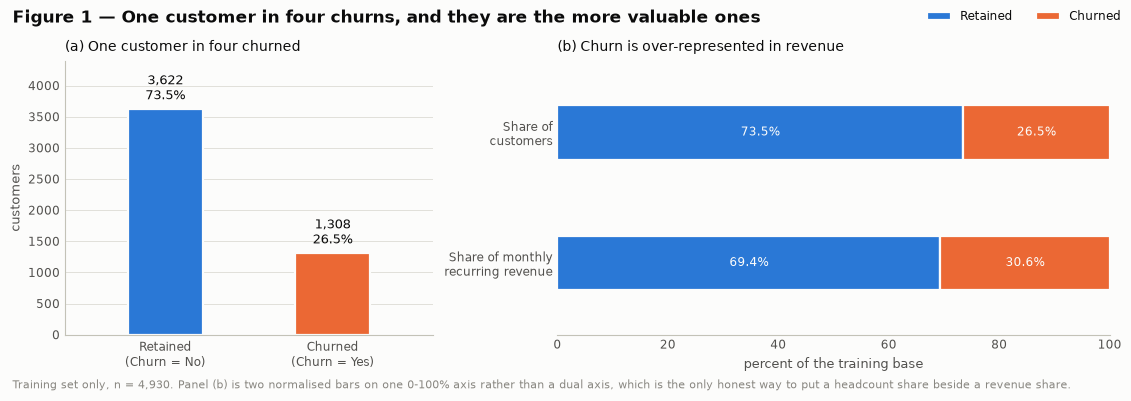

In [18]:
eda_class_counts = train_df[TARGET].value_counts().sort_index()
eda_class_share = eda_class_counts / len(train_df)
eda_revenue = train_df.groupby(TARGET, observed=True)["MonthlyCharges"].agg(
    mrr="sum", mean_bill="mean")
eda_revenue["mrr_share"] = eda_revenue["mrr"] / eda_revenue["mrr"].sum()

eda_value_gap = pd.DataFrame({
    "customers": eda_class_share,
    "monthly_revenue": eda_revenue["mrr_share"],
}).rename(index=CLASS_LABELS)
print("share of the training base, percent")
print((eda_value_gap * 100).round(2).to_string())

mrr_share_churned = eda_revenue.loc[1, "mrr_share"]
print(f"\nmean monthly bill:  churned ${eda_revenue.loc[1, 'mean_bill']:.2f}   "
      f"retained ${eda_revenue.loc[0, 'mean_bill']:.2f}")
print(f"churners are {mrr_share_churned / BASE_RATE - 1:+.1%} worse in revenue share "
      "than in headcount share")
print(f"majority-class baseline: {1 - BASE_RATE:.2%} accuracy while finding 0 of "
      f"{eda_class_counts[1]:,} churners\n")

assert_claim("1,308 churners in the training set", int(eda_class_counts[1]) == 1308)
assert_claim("churners hold more revenue share than headcount share",
             mrr_share_churned > BASE_RATE,
             f"{mrr_share_churned:.4f} of revenue vs {BASE_RATE:.4f} of customers")

fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.9), width_ratios=[1, 1.5],
                         layout="constrained")

panel_a = axes[0]
count_bars = panel_a.bar([0, 1], eda_class_counts.to_numpy(), width=0.45,
                         color=[CLASS_COLOURS[0], CLASS_COLOURS[1]],
                         edgecolor=SURFACE, linewidth=1.6)
for bar, size, share in zip(count_bars, eda_class_counts, eda_class_share):
    panel_a.text(bar.get_x() + bar.get_width() / 2, size + 90, f"{size:,}\n{share:.1%}",
                 ha="center", va="bottom", fontsize=9, color=INK)
panel_a.set_xticks([0, 1], ["Retained\n(Churn = No)", "Churned\n(Churn = Yes)"])
panel_a.set_xlim(-0.6, 1.6)
panel_a.set_ylim(0, 4400)
panel_a.set_ylabel("customers")
panel_a.set_title("(a) One customer in four churned")
value_grid(panel_a, "y")

panel_b = axes[1]
measures = ["customers", "monthly_revenue"]
positions = [1, 0]
running = np.zeros(2)
segments, segment_labels = [], []
for cls in (0, 1):
    widths = np.array([eda_value_gap.loc[CLASS_LABELS[cls], m] for m in measures]) * 100
    drawn = panel_b.barh(positions, widths, left=running, height=0.42,
                         color=CLASS_COLOURS[cls], edgecolor=SURFACE, linewidth=1.6,
                         label=CLASS_LABELS[cls])
    segments += list(drawn)
    segment_labels += [f"{value:.1f}%" for value in widths]
    running += widths
panel_b.set_yticks(positions, ["Share of\ncustomers", "Share of monthly\nrecurring revenue"])
panel_b.set_xlim(0, 100)
panel_b.set_ylim(-0.55, 1.55)
panel_b.set_xlabel("percent of the training base")
panel_b.set_title("(b) Churn is over-represented in revenue")
panel_b.spines["left"].set_visible(False)

handles, labels = panel_b.get_legend_handles_labels()
fig.legend(handles, labels, loc="outside upper right", ncols=2)
figure_title(fig, "Figure 1 — One customer in four churns, and they are the more valuable ones",
             subtitle="Training set only, n = 4,930. Panel (b) is two normalised bars on one "
                      "0-100% axis rather than a dual axis, which is the only honest way to put a "
                      "headcount share beside a revenue share.")
dropped = label_bar_segments(panel_b, segments, segment_labels)
if dropped:
    print(f"segment labels omitted as too narrow to hold text: {dropped}")
plt.show()

### Insight — Figure 1

**Churn is not merely frequent, it is concentrated in the customers worth the most.** 1,308 of 4,930
training customers churned (26.53%), but they account for **30.64% of monthly recurring revenue** — a
mean bill of $75.00 against $61.32 for those who stayed. The loss is 15.5% worse measured in money
than in headcount, so a retention programme sized on the average customer under-states the problem
it is solving.

The second consequence is the one section 5 has to live with: **accuracy in the low seventies is
free**. A model that predicts "No" for everybody scores 73.47% on this training set — the same
majority-class baseline computed as 73.46% on the full dataset at 1.7 — while finding 0 of the 1,308
churners. That is why recall on the churn class, not accuracy, is the metric this project is judged
on.

## 2.2 Who these customers are and what they buy

The brief asks separately for the distribution of *customer and service characteristics*, and it is
the requirement most easily faked by pointing at a churn chart instead. So this figure **references
the target nowhere at all**: single hue, no legend, no base-rate line, no split by class. It is a
description of the base, and the violet is a hue used nowhere else in the notebook precisely so it
cannot be mistaken for the retained class.

It is not filler. Three numbers below are load-bearing for figures that follow: the share of
customers who have internet at all (the denominator every add-on statement depends on), the add-on
take-up rate (how much of the protective product is unsold), and the price gap between tiers (the
mechanism behind the composition artefact at 2.7).

demographics (% of 4,930)
65 or older       16.1
Has a partner     48.1
Has dependents    29.8
Female            49.7

product mix (% of 4,930)
Phone service     89.9
Multiple lines    42.3
Fibre internet    44.2
DSL internet      34.2
No internet       21.7

has internet: 78.3%  ->  n = 3,862 eligible for the six add-ons
add-on take-up among those 3,862 customers, %
OnlineSecurity      36.8
TechSupport         37.6
OnlineBackup        44.5
DeviceProtection    44.6
StreamingMovies     50.0
StreamingTV         50.3

price and revenue by internet tier
                    n  median     q1      q3  mrr_share_pct  customer_share_pct
InternetService                                                                
DSL              1685   55.95  45.70   70.30          30.57               34.18
Fiber optic      2177   92.60  80.75  101.45          62.39               44.16
No               1068   20.15  19.70   20.95           7.04               21.66

  [PASS] more than 78% of customers take in

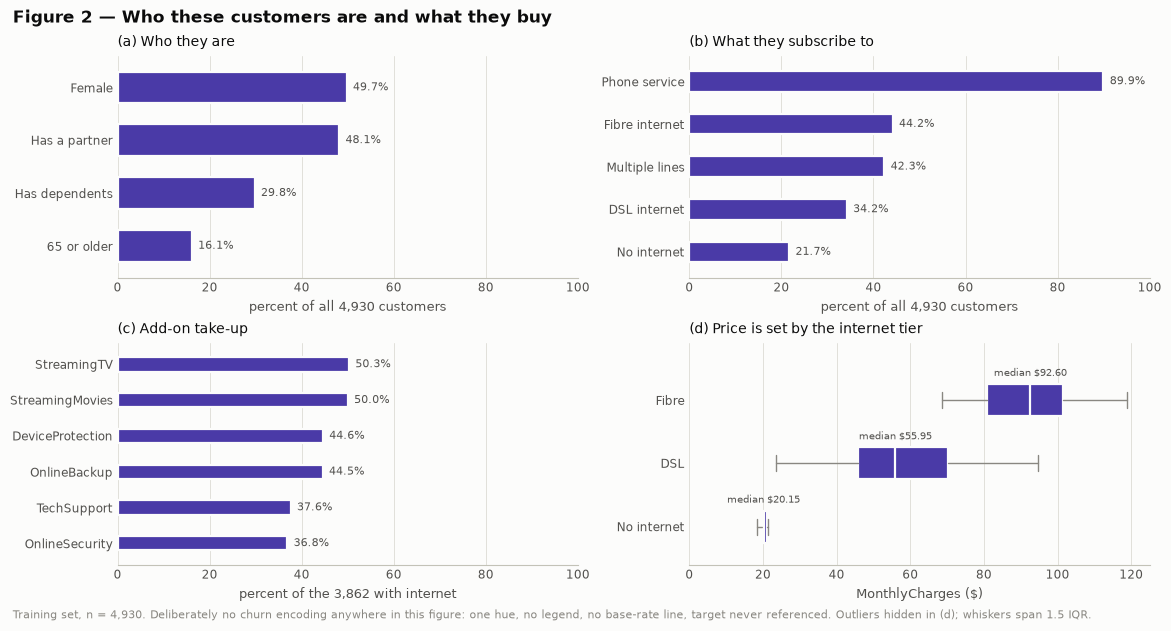

In [19]:
eda_demographics = pd.Series({
    "65 or older": (train_df["SeniorCitizen"] == 1).mean(),
    "Has a partner": (train_df["Partner"] == "Yes").mean(),
    "Has dependents": (train_df["Dependents"] == "Yes").mean(),
    "Female": (train_df["gender"] == "Female").mean(),
}) * 100
eda_product_mix = pd.Series({
    "Phone service": (train_df["PhoneService"] == "Yes").mean(),
    "Multiple lines": (train_df["MultipleLines"] == "Yes").mean(),
    "Fibre internet": (train_df["InternetService"] == "Fiber optic").mean(),
    "DSL internet": (train_df["InternetService"] == "DSL").mean(),
    "No internet": (train_df["InternetService"] == "No").mean(),
}) * 100

eda_internet = train_df[train_df["InternetService"] != "No"]
eda_addon_takeup = ((eda_internet[ADDONS] == "Yes").mean() * 100).sort_values()
eda_price_tiers = train_df.groupby("InternetService", observed=True)["MonthlyCharges"].agg(
    n="size", median="median", q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))

mrr_total = train_df["MonthlyCharges"].sum()
eda_price_tiers["mrr_share_pct"] = (
    train_df.groupby("InternetService", observed=True)["MonthlyCharges"].sum() / mrr_total * 100)
eda_price_tiers["customer_share_pct"] = eda_price_tiers["n"] / len(train_df) * 100

has_internet = (train_df["InternetService"] != "No").mean()
print(f"demographics (% of {len(train_df):,})\n{eda_demographics.round(1).to_string()}")
print(f"\nproduct mix (% of {len(train_df):,})\n{eda_product_mix.round(1).to_string()}")
print(f"\nhas internet: {has_internet:.1%}  ->  n = {len(eda_internet):,} "
      "eligible for the six add-ons")
print(f"add-on take-up among those {len(eda_internet):,} customers, %\n"
      f"{eda_addon_takeup.round(1).to_string()}")
print(f"\nprice and revenue by internet tier\n{eda_price_tiers.round(2).to_string()}\n")

fibre_row = eda_price_tiers.loc["Fiber optic"]
assert_claim("more than 78% of customers take internet", has_internet > 0.78,
             f"{has_internet:.3%}, n = {len(eda_internet):,}")
assert_claim("no add-on is held by even half of eligible customers",
             eda_addon_takeup.max() < 51.0, f"highest is {eda_addon_takeup.idxmax()} at "
             f"{eda_addon_takeup.max():.1f}%")
assert_claim("fibre takes a larger revenue share than customer share",
             fibre_row["mrr_share_pct"] > 60 > fibre_row["customer_share_pct"],
             f"{fibre_row['mrr_share_pct']:.1f}% of revenue from "
             f"{fibre_row['customer_share_pct']:.1f}% of customers")

fig, axes = plt.subplots(2, 2, figsize=(11.6, 6.2), layout="constrained")

for panel_ax, (data, panel_title, xlabel) in zip(
        axes.ravel()[:3],
        [(eda_demographics, "(a) Who they are", f"percent of all {len(train_df):,} customers"),
         (eda_product_mix, "(b) What they subscribe to",
          f"percent of all {len(train_df):,} customers"),
         (eda_addon_takeup, "(c) Add-on take-up",
          f"percent of the {len(eda_internet):,} with internet")]):
    ordered = data.sort_values()
    # Thickness scaled by row count so a 4-row panel does not draw fatter bars
    # than a 6-row panel of the same height.
    bars = panel_ax.barh(np.arange(len(ordered)), ordered.to_numpy(),
                         height=2.4 / len(ordered),
                         color=PROFILE, edgecolor=SURFACE, linewidth=1.6)
    for bar, value in zip(bars, ordered):
        panel_ax.text(value + 1.4, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%",
                      va="center", ha="left", fontsize=8, color=INK_2)
    panel_ax.set_yticks(np.arange(len(ordered)), list(ordered.index))
    panel_ax.set_xlim(0, 100)
    panel_ax.set_ylim(-0.6, len(ordered) - 0.4)
    panel_ax.set_xlabel(xlabel)
    panel_ax.set_title(panel_title)
    panel_ax.spines["left"].set_visible(False)
    value_grid(panel_ax, "x")

panel_d = axes[1, 1]
tiers = ["No", "DSL", "Fiber optic"]
TIER_LABELS = {"No": "No internet", "DSL": "DSL", "Fiber optic": "Fibre"}
box = panel_d.boxplot([train_df.loc[train_df["InternetService"] == tier, "MonthlyCharges"]
                       for tier in tiers],
                      orientation="horizontal", tick_labels=[TIER_LABELS[t] for t in tiers],
                      widths=0.5, patch_artist=True, showfliers=False,
                      medianprops=dict(color=SURFACE, lw=1.6),
                      whiskerprops=dict(color=MUTED, lw=1.0),
                      capprops=dict(color=MUTED, lw=1.0))
for patch in box["boxes"]:
    patch.set(facecolor=PROFILE, edgecolor=SURFACE, linewidth=1.6)
for tier, position in zip(tiers, range(1, len(tiers) + 1)):
    panel_d.text(eda_price_tiers.loc[tier, "median"], position + 0.34,
                 f"median ${eda_price_tiers.loc[tier, 'median']:.2f}",
                 ha="center", va="bottom", fontsize=7.5, color=INK_2)
panel_d.set_xlim(0, 125)
panel_d.set_ylim(0.4, 3.9)
panel_d.set_xlabel("MonthlyCharges ($)")
panel_d.set_title("(d) Price is set by the internet tier")
panel_d.spines["left"].set_visible(False)
value_grid(panel_d, "x")

figure_title(fig, "Figure 2 — Who these customers are and what they buy",
             subtitle="Training set, n = 4,930. Deliberately no churn encoding anywhere in this "
                      "figure: one hue, no legend, no base-rate line, target never referenced. "
                      "Outliers hidden in (d); whiskers span 1.5 IQR.")
plt.show()

### Insight — Figure 2

**This is a base built on internet service, and most of its revenue sits in the tier that churns
worst.** 78.3% of customers take internet — 44.2% fibre, 34.2% DSL — and that 78.3% is the
denominator every add-on statement in this section depends on. Fibre is 44.2% of customers but
**62.4% of monthly recurring revenue**, because at a median $92.60 it costs roughly 1.7 times DSL's
$55.95. Panel (d) also shows why: price here is almost entirely a function of the internet tier, with
the no-internet group compressed into a $19.70–$20.95 quartile range.

Among the 3,862 internet customers, add-on take-up runs from only 36.8% (OnlineSecurity) to 50.3%
(StreamingTV), so **fewer than half of eligible customers hold the services figure 8 shows to be
protective**. That is what makes them a retention lever rather than a fixed customer characteristic —
there is unsold inventory in exactly the products associated with staying. The demographic split is
unremarkable next to that: 16.1% are 65 or older, 48.1% have a partner, 29.8% have dependents, and
the gender split is 49.7% female, near-exactly even.

## 2.3 When in the lifecycle the risk happens

`tenure` is the strongest numeric predictor, but a correlation coefficient describes a straight line
and the relationship here is not one. Two views are needed: bands, which are robust and feed a
feature; and month by month, which shows the shape the bands smooth over.

**Month 0 is excluded from panel (b).** The seven training customers with `tenure == 0` are the
never-billed accounts found at 1.3, and they are all `Churn = No` by construction — a customer who
has not reached their first bill cannot have been recorded as leaving. Plotting them would put a
spurious 0% at the left edge of a curve whose whole point is that risk is *highest* there. The
exclusion is asserted in code and the axis starts at month 1 so it is visible rather than silent.

churn by tenure band
                  n  churners  rate_pct  lift
tenure_bucket                                
0-6            1030       538      52.2  1.97
7-12            507       195      38.5  1.45
13-24           707       193      27.3  1.03
25-48          1118       223      19.9  0.75
49-72          1568       159      10.1  0.38

tenure == 0: n = 7, churners = 0  ->  excluded from panel (b)

of the 1,308 churners: 41.1% left within 6 months, 56.0% within 12
median tenure: churned 10 months, retained 38 months

  [PASS] never-billed customers cannot have churned   n = 7, all Churn = No
  [PASS] tenure bands account for all 4,930 customers
  [PASS] churn rate falls monotonically across tenure bands   52.2% -> 38.5% -> 27.3% -> 19.9% -> 10.1%
  [PASS] over 40% of churners leave within 6 months   41.1%


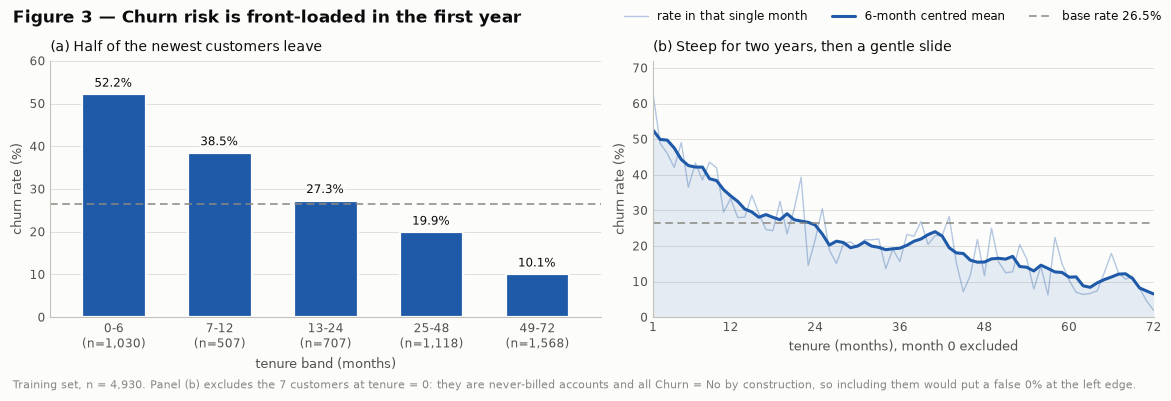

In [20]:
eda_banded = train_df.assign(tenure_bucket=tenure_bucket(train_df["tenure"]))
eda_tenure_bands = rate_table(eda_banded, "tenure_bucket")
print(f"churn by tenure band\n{eda_tenure_bands.drop(columns='rate').to_string()}")

eda_zero_tenure = train_df[train_df["tenure"] == 0]
print(f"\ntenure == 0: n = {len(eda_zero_tenure)}, churners = "
      f"{int(eda_zero_tenure[TARGET].sum())}  ->  excluded from panel (b)")

eda_tenure_months = (train_df[train_df["tenure"] > 0]
                     .groupby("tenure", observed=True)[TARGET]
                     .agg(n="size", rate="mean"))
eda_tenure_months["rate_pct"] = eda_tenure_months["rate"] * 100
eda_tenure_months["smoothed"] = (eda_tenure_months["rate_pct"]
                                 .rolling(6, center=True, min_periods=3).mean())

eda_churned = train_df[train_df[TARGET] == 1]
within_6 = (eda_churned["tenure"] <= 6).mean()
within_12 = (eda_churned["tenure"] <= 12).mean()
print(f"\nof the {len(eda_churned):,} churners: {within_6:.1%} left within 6 months, "
      f"{within_12:.1%} within 12")
print(f"median tenure: churned {eda_churned['tenure'].median():.0f} months, "
      f"retained {train_df.loc[train_df[TARGET] == 0, 'tenure'].median():.0f} months\n")

assert_claim("never-billed customers cannot have churned",
             (eda_zero_tenure[TARGET] == 0).all(),
             f"n = {len(eda_zero_tenure)}, all Churn = No")
assert_claim("tenure bands account for all 4,930 customers",
             int(eda_tenure_bands["n"].sum()) == 4930)
assert_claim("churn rate falls monotonically across tenure bands",
             eda_tenure_bands["rate"].is_monotonic_decreasing,
             " -> ".join(f"{r:.1f}%" for r in eda_tenure_bands["rate_pct"]))
assert_claim("over 40% of churners leave within 6 months", within_6 > 0.40, f"{within_6:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(11.6, 3.9), width_ratios=[1.1, 1],
                         layout="constrained")

panel_a = axes[0]
bars = panel_a.bar(np.arange(len(eda_tenure_bands)), eda_tenure_bands["rate_pct"].to_numpy(),
                   width=0.6, color=EMPHASIS, edgecolor=SURFACE, linewidth=1.6)
for bar, value in zip(bars, eda_tenure_bands["rate_pct"]):
    panel_a.text(bar.get_x() + bar.get_width() / 2, value + 1.1, f"{value:.1f}%",
                 ha="center", va="bottom", fontsize=8.5, color=INK, path_effects=HALO)
panel_a.set_xticks(np.arange(len(eda_tenure_bands)),
                   tick_labels_with_n(eda_tenure_bands.index, eda_tenure_bands["n"]))
panel_a.set_xlim(-0.6, len(eda_tenure_bands) - 0.4)
panel_a.set_ylim(0, 60)
panel_a.set_ylabel("churn rate (%)")
panel_a.set_xlabel("tenure band (months)")
panel_a.set_title("(a) Half of the newest customers leave")
add_base_rate_line(panel_a, "y")
value_grid(panel_a, "y")

panel_b = axes[1]
panel_b.plot(eda_tenure_months.index, eda_tenure_months["rate_pct"], lw=1.0, alpha=0.32,
             color=EMPHASIS, label="rate in that single month")
panel_b.plot(eda_tenure_months.index, eda_tenure_months["smoothed"], lw=2.2, color=EMPHASIS,
             label="6-month centred mean")
panel_b.fill_between(eda_tenure_months.index, eda_tenure_months["smoothed"], alpha=0.10,
                     color=EMPHASIS, lw=0)
base_handle = add_base_rate_line(panel_b, "y")
panel_b.set_xlim(1, 72)
panel_b.set_ylim(0, 72)
panel_b.set_xticks([1, 12, 24, 36, 48, 60, 72])
panel_b.set_xlabel("tenure (months), month 0 excluded")
panel_b.set_ylabel("churn rate (%)")
panel_b.set_title("(b) Steep for two years, then a gentle slide")
value_grid(panel_b, "y")
handles, labels = panel_b.get_legend_handles_labels()
fig.legend(handles + [base_handle], labels + [base_handle.get_label()],
           loc="outside upper right", ncols=3)

figure_title(fig, "Figure 3 — Churn risk is front-loaded in the first year",
             subtitle="Training set, n = 4,930. Panel (b) excludes the 7 customers at tenure = 0: "
                      "they are never-billed accounts and all Churn = No by construction, so "
                      "including them would put a false 0% at the left edge.")
plt.show()

### Insight — Figure 3

**Churn is a first-year problem, not a steady leak.** The rate falls monotonically across tenure
bands — 52.2% → 38.5% → 27.3% → 19.9% → 10.1% — and **41.1% of all churners are gone within six
months, 56.0% within twelve**. Median tenure is 10 months for churners against 38 months for those
who stay. Only the last two bands sit below the 26.5% base rate, so for the first two years the
average customer is an above-average risk.

The *shape* is the modelling point. Panel (b) falls steeply to roughly month 24 and then slides
gently, so a single linear `tenure` coefficient would average the two regimes and underfit the cliff
where the losses actually occur — that is hypothesis 1 at 2.10, which keeps raw `tenure` and adds the
fixed-cut `tenure_bucket` beside it. Commercially the same curve says a retention budget spent at
month 18 is mostly spent after the event.

## 2.4 The three numeric features: distributions and relationships

The brief asks for distributions of numerical variables *and* the relationships between them. Panels
(a)–(c) cover the first, split by class so the distribution and its usefulness are visible at once;
panel (d) and the printed correlation matrix cover the second.

**There is no correlation heatmap here.** Three numerics plus the target give six informative pairs,
and a 4×4 grid drawn to display six numbers is decoration — half of it is a mirror image and the
diagonal is all ones. The matrix is printed instead, alongside a check that matters more than any of
its cells: whether `TotalCharges` is anything other than `MonthlyCharges × tenure`.

correlation matrix
                tenure  MonthlyCharges  TotalCharges   Churn
tenure          1.0000          0.2584        0.8305 -0.3435
MonthlyCharges  0.2584          1.0000        0.6543  0.1997
TotalCharges    0.8305          0.6543        1.0000 -0.1902
Churn          -0.3435          0.1997       -0.1902  1.0000

point-biserial with the target:  tenure -0.344,   MonthlyCharges +0.200,   TotalCharges -0.190
TotalCharges vs MonthlyCharges x tenure:  r = 0.9996

medians by class
          tenure  MonthlyCharges  TotalCharges
Churn                                         
Retained    38.0           64.45       1673.60
Churned     10.0           80.00        705.08

ranges - three very different scales
     tenure  MonthlyCharges  TotalCharges
min       0           18.40           0.0
max      72          118.75        8684.8

  [PASS] tenure is the strongest numeric predictor   |r| = 0.344
  [PASS] tenure and TotalCharges are heavily collinear   r = 0.830
  [PASS] TotalCharges is

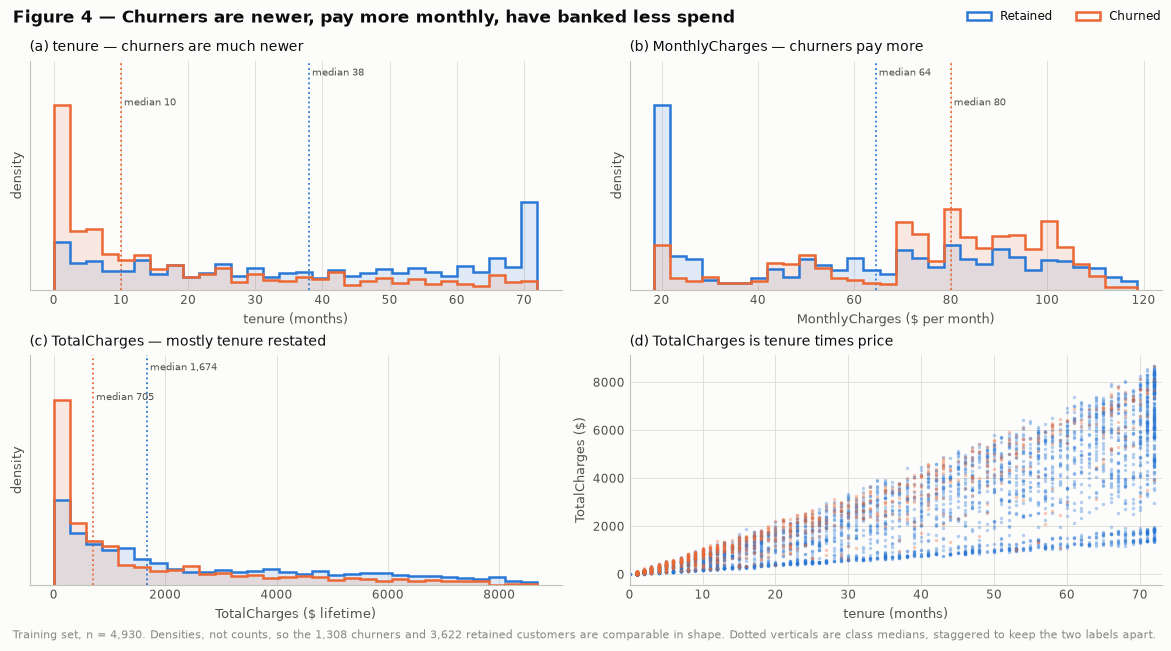

In [21]:
eda_numeric_corr = train_df[numeric_features + [TARGET]].corr()
eda_numeric_strength = point_biserial(train_df, numeric_features)
eda_reconstruction = float((train_df["MonthlyCharges"] * train_df["tenure"])
                           .corr(train_df["TotalCharges"]))

print(f"correlation matrix\n{eda_numeric_corr.round(4).to_string()}")
print("\npoint-biserial with the target:  "
      + ",   ".join(f"{name} {value:+.3f}" for name, value in eda_numeric_strength.items()))
print(f"TotalCharges vs MonthlyCharges x tenure:  r = {eda_reconstruction:.4f}")
print("\nmedians by class")
print(train_df.groupby(TARGET, observed=True)[numeric_features].median()
      .rename(index=CLASS_LABELS).round(2).to_string())
print("\nranges - three very different scales")
print(train_df[numeric_features].agg(["min", "max"]).round(2).to_string())
print()

assert_claim("tenure is the strongest numeric predictor",
             eda_numeric_strength.abs().idxmax() == "tenure",
             f"|r| = {abs(eda_numeric_strength['tenure']):.3f}")
assert_claim("tenure and TotalCharges are heavily collinear",
             eda_numeric_corr.loc["tenure", "TotalCharges"] > 0.80,
             f"r = {eda_numeric_corr.loc['tenure', 'TotalCharges']:.3f}")
assert_claim("TotalCharges is almost exactly price x tenure", eda_reconstruction > 0.999,
             f"r = {eda_reconstruction:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(11.6, 6.4), layout="constrained")
panel_titles = {
    "tenure": "(a) tenure — churners are much newer",
    "MonthlyCharges": "(b) MonthlyCharges — churners pay more",
    "TotalCharges": "(c) TotalCharges — mostly tenure restated",
}
axis_labels = {"tenure": "months", "MonthlyCharges": "$ per month", "TotalCharges": "$ lifetime"}

for panel_ax, col in zip(axes.ravel()[:3], numeric_features):
    edges = np.histogram_bin_edges(train_df[col], bins=30)
    for cls in (0, 1):
        series = train_df.loc[train_df[TARGET] == cls, col]
        # Filled at 13% under a solid outline, so two overlapping series never
        # blend into an ambiguous third colour.
        panel_ax.hist(series, bins=edges, density=True, histtype="stepfilled",
                      alpha=0.13, color=CLASS_COLOURS[cls])
        panel_ax.hist(series, bins=edges, density=True, histtype="step", lw=1.8,
                      color=CLASS_COLOURS[cls], label=CLASS_LABELS[cls])
    # Headroom first: hist() autoscales so the tallest bin touches the frame,
    # which leaves a median label nowhere to sit but on top of the panel title.
    panel_ax.set_ylim(0, panel_ax.get_ylim()[1] * 1.18)
    top = panel_ax.get_ylim()[1]
    for cls, height in ((0, 0.97), (1, 0.84)):
        middle = train_df.loc[train_df[TARGET] == cls, col].median()
        panel_ax.axvline(middle, ls=":", lw=1.3, color=CLASS_COLOURS[cls], zorder=1)
        panel_ax.text(middle, top * height, f" median {middle:,.0f}", ha="left", va="top",
                      fontsize=7.5, color=INK_2)
    panel_ax.set_yticks([])
    panel_ax.set_ylabel("density")
    panel_ax.set_xlabel(f"{col} ({axis_labels[col]})")
    panel_ax.set_title(panel_titles[col])
    value_grid(panel_ax, "x")

panel_d = axes[1, 1]
for cls in (0, 1):   # churned drawn last so it is not hidden under the majority
    subset = train_df[train_df[TARGET] == cls]
    panel_d.scatter(subset["tenure"], subset["TotalCharges"], s=6, alpha=0.35,
                    color=CLASS_COLOURS[cls], linewidths=0, label=CLASS_LABELS[cls])
panel_d.set_xlim(0, 73)
panel_d.set_xlabel("tenure (months)")
panel_d.set_ylabel("TotalCharges ($)")
panel_d.set_title("(d) TotalCharges is tenure times price")
value_grid(panel_d, "both")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside upper right", ncols=2)
figure_title(fig, "Figure 4 — Churners are newer, pay more monthly, have banked less spend",
             subtitle="Training set, n = 4,930. Densities, not counts, so the 1,308 churners and "
                      "3,622 retained customers are comparable in shape. Dotted verticals are "
                      "class medians, staggered to keep the two labels apart.")
plt.show()

### Insight — Figure 4

**Churners are newer, pay more per month and have banked less lifetime spend — but only two of those
three are independent facts.** Point-biserial correlation with the target gives tenure **−0.344**,
MonthlyCharges **+0.200** and TotalCharges **−0.190**. The third is largely the first one restated:
tenure and TotalCharges correlate at **0.830**, and `MonthlyCharges × tenure` reconstructs
TotalCharges at **r = 0.9996**.

So the most intuitive business figure of the three — total money a customer has given you — is the
*weakest* predictor, and it is weak precisely because it fuses a strong signal (how long they have
been here, negative) with a weaker one of the opposite sign (how much they pay, positive). Panel (d)
makes the redundancy visible: the scatter is a fan of straight lines through the origin, one slope per
price point, with churners packed into the short-tenure end of every slope. Hypothesis 5 at 2.10
therefore proposes replacing it with realised ARPU, `TotalCharges / max(tenure, 1)` — and settling
the question by cross-validation in section 4 rather than by assertion here.

The distributions also warn about scale. `tenure` runs 0–72, `MonthlyCharges` 18–119 and
`TotalCharges` 0–8,685, so any distance- or gradient-based model needs the `scale_numeric=True`
branch of `build_preprocessor`; a decision tree, which splits one feature at a time, does not.

## 2.5 Ranking the predictors

With 19 features, looking at each one in turn is how a reader loses the thread. One ranked chart
says which attributes are worth a panel of their own and which are not, before any of them get one.

**One effect size per data type, on two separate axes.** The 16 non-numeric features are ranked by
**Cramér's V**, computed from the contingency table with no scipy dependency; against a binary target
it reduces to the phi coefficient, which is what makes a 2-level feature comparable with a 3-level
one in the same list. The 3 numeric features are ranked by **point-biserial correlation**. These are
different statistics measured on different scales, so putting them on one shared axis would invite a
comparison that means nothing — hence two panels, and the subtitle says so.

The **0.05 noise gate** is drawn as a dashed line. It is a pragmatic threshold, not a significance
test: below it the level-to-level rate differences are small enough that a model gains nothing, and
the features concerned become *drop candidates* for section 4 to settle by cross-validation. Bars
above the gate get one ink and bars below get grey — an emphasis encoding, because 16 separate hues
would be 16 hues to decode and none of them would mean anything.

Cramer's V against Churn, all 16 non-numeric features
                  cramers_v  levels  min_rate_pct  max_rate_pct  above_gate
Contract              0.412       3         3.020        42.862        True
OnlineSecurity        0.353       3         6.929        42.025        True
TechSupport           0.348       3         6.929        41.933        True
InternetService       0.325       3         6.929        41.847        True
PaymentMethod         0.310       4        14.714        45.647        True
OnlineBackup          0.299       3         6.929        40.289        True
DeviceProtection      0.284       3         6.929        39.206        True
StreamingMovies       0.236       3         6.929        33.661        True
StreamingTV           0.236       3         6.929        33.576        True
PaperlessBilling      0.204       2        15.672        34.007        True
Dependents            0.172       2        14.860        31.476        True
Partner               0.150       

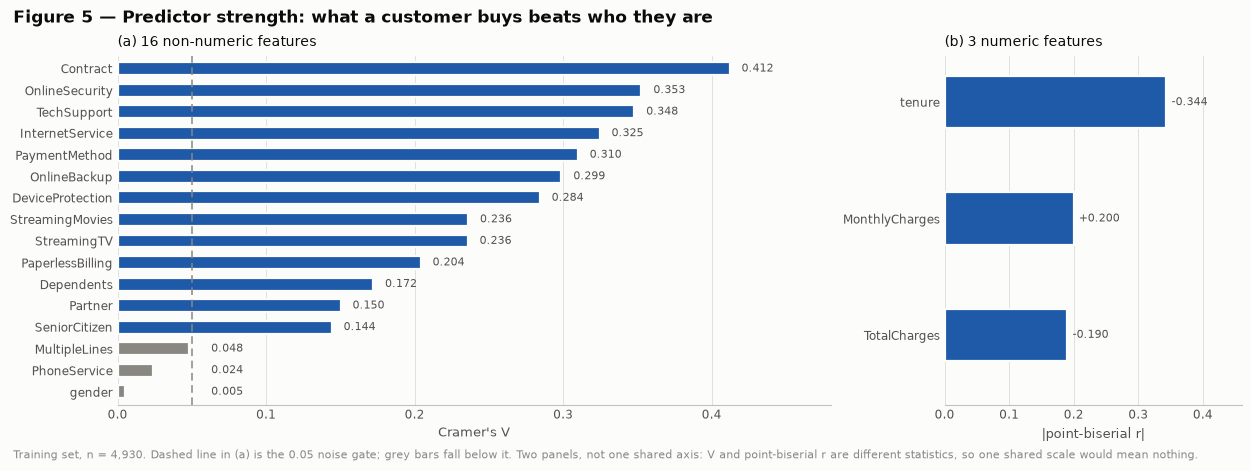

In [22]:
NON_NUMERIC = categorical_features + binary_features
eda_strength = pd.DataFrame(
    {"cramers_v": {col: cramers_v(train_df[col], train_df[TARGET]) for col in NON_NUMERIC}})
level_rates = {col: train_df.groupby(col, observed=True)[TARGET].mean() * 100
               for col in NON_NUMERIC}
eda_strength["levels"] = [train_df[col].nunique() for col in eda_strength.index]
eda_strength["min_rate_pct"] = [level_rates[col].min() for col in eda_strength.index]
eda_strength["max_rate_pct"] = [level_rates[col].max() for col in eda_strength.index]
eda_strength = eda_strength.sort_values("cramers_v", ascending=False)
eda_strength["above_gate"] = eda_strength["cramers_v"] >= NOISE_GATE

print(f"Cramer's V against {TARGET}, all {len(eda_strength)} non-numeric features")
print(eda_strength.round(3).to_string())
below_gate = sorted(eda_strength.index[~eda_strength["above_gate"]])
print(f"\nbelow the {NOISE_GATE} noise gate: {below_gate}")
print("\npoint-biserial |r| for the 3 numeric features")
print(eda_numeric_strength.round(3).to_string() + "\n")

assert_claim("Contract is the strongest non-numeric predictor",
             eda_strength.index[0] == "Contract",
             f"V = {eda_strength['cramers_v'].iloc[0]:.3f}")
assert_claim("gender carries essentially no signal",
             eda_strength.loc["gender", "cramers_v"] < 0.01,
             f"V = {eda_strength.loc['gender', 'cramers_v']:.3f}, "
             f"{eda_strength.loc['gender', 'min_rate_pct']:.1f}% vs "
             f"{eda_strength.loc['gender', 'max_rate_pct']:.1f}%")
assert_claim("exactly three features fall below the noise gate",
             below_gate == ["MultipleLines", "PhoneService", "gender"], str(below_gate))
assert_claim("SeniorCitizen does carry signal, unlike gender",
             eda_strength.loc["SeniorCitizen", "cramers_v"] > 0.10,
             f"V = {eda_strength.loc['SeniorCitizen', 'cramers_v']:.3f}, "
             f"{eda_strength.loc['SeniorCitizen', 'min_rate_pct']:.1f}% vs "
             f"{eda_strength.loc['SeniorCitizen', 'max_rate_pct']:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6), width_ratios=[2.4, 1],
                         layout="constrained")

panel_a = axes[0]
ranked = eda_strength.sort_values("cramers_v")
bars = panel_a.barh(np.arange(len(ranked)), ranked["cramers_v"].to_numpy(),
                    height=2.4 / len(ranked) * 4,
                    color=[EMPHASIS if flag else MUTED for flag in ranked["above_gate"]],
                    edgecolor=SURFACE, linewidth=1.6)
for bar, value in zip(bars, ranked["cramers_v"]):
    # Below-gate bars are shorter than the gate itself, so their labels share a
    # column just clear of the dashed line rather than sitting underneath it.
    panel_a.text(max(value + 0.008, NOISE_GATE + 0.013),
                 bar.get_y() + bar.get_height() / 2, f"{value:.3f}",
                 va="center", ha="left", fontsize=8, color=INK_2)
# The gate is named in the subtitle rather than labelled on the canvas. Every
# position on this axes is occupied by either a bar or a value label, and the
# same convention already applies to the base-rate line elsewhere.
panel_a.axvline(NOISE_GATE, ls=(0, (5, 3)), lw=1.1, color=MUTED, zorder=2)
panel_a.set_yticks(np.arange(len(ranked)), list(ranked.index))
panel_a.set_xlim(0, 0.48)
panel_a.set_ylim(-0.6, len(ranked) - 0.4)
panel_a.set_xlabel("Cramer's V")
panel_a.set_title("(a) 16 non-numeric features")
panel_a.spines["left"].set_visible(False)
value_grid(panel_a, "x")

panel_b = axes[1]
numeric_ranked = eda_numeric_strength.abs().sort_values()
bars = panel_b.barh(np.arange(len(numeric_ranked)), numeric_ranked.to_numpy(), height=0.45,
                    color=EMPHASIS, edgecolor=SURFACE, linewidth=1.6)
for bar, (name, value) in zip(bars, numeric_ranked.items()):
    panel_b.text(value + 0.008, bar.get_y() + bar.get_height() / 2,
                 f"{eda_numeric_strength[name]:+.3f}", va="center", ha="left",
                 fontsize=8, color=INK_2)
panel_b.set_yticks(np.arange(len(numeric_ranked)), list(numeric_ranked.index))
panel_b.set_xlim(0, 0.46)
panel_b.set_ylim(-0.6, 2.4)
panel_b.set_xlabel("|point-biserial r|")
panel_b.set_title("(b) 3 numeric features")
panel_b.spines["left"].set_visible(False)
value_grid(panel_b, "x")

figure_title(fig, "Figure 5 — Predictor strength: what a customer buys beats who they are",
             subtitle="Training set, n = 4,930. Dashed line in (a) is the 0.05 noise gate; grey "
                      "bars fall below it. Two panels, not one shared axis: V and point-biserial "
                      "r are different statistics, so one shared scale would mean nothing.")
plt.show()

### Insight — Figure 5

**Contract length is the strongest single predictor in the dataset, and what a customer buys matters
far more than who they are.** Cramér's V ranks Contract **0.412**, then OnlineSecurity 0.353,
TechSupport 0.348, InternetService 0.325 and PaymentMethod 0.310 — every one of them a service or
commitment attribute. Among the numerics, tenure leads at |r| = 0.344, which would place it third
overall if the two statistics were comparable.

Three features fall below the 0.05 gate: **gender at V = 0.005** (26.3% churn for women against 26.8%
for men, on n = 4,930 — the cleanest null in this dataset), PhoneService 0.024 and MultipleLines
0.048. The right conclusion from that is narrow. *Gender* does not predict churn, but demographics in
general do: SeniorCitizen carries V = 0.144 with rates of 23.7% against 41.1%, Dependents 0.172 and
Partner 0.150. So "demographics don't matter" would be the wrong lesson, and it is worth saying
because it is the lesson a single gender chart invites.

These three become drop *candidates* at 2.10, not drops. Discarding a feature because a cross-tab
called it weak is the same class of error as keeping one because it sounded important; both get
settled by cross-validation in section 4.

## 2.6 Inside the top six drivers

Figure 5 ranks features. It does not say *which level* of a feature carries the risk, and that is the
part a retention team can act on — "Contract matters" is not an intervention, "month-to-month churns
at 42.9% against 3.0% on a two-year term" is.

One panel per feature, sharing a single 0–60% axis so the panels are comparable rather than each
stretched to its own range, with the base-rate line repeated on every panel. `n` sits in the tick
label, never inside the bar: a short bar cannot hold the text, and a clipped count is worse than no
count at all.

top six by Cramer's V: ['Contract', 'OnlineSecurity', 'TechSupport', 'InternetService', 'PaymentMethod', 'OnlineBackup']

--- Contract  (V = 0.412) ---
                   n  churners  rate_pct  lift
Contract                                      
Month-to-month  2704      1159      42.9  1.62
One year        1034       113      10.9  0.41
Two year        1192        36       3.0  0.11

--- OnlineSecurity  (V = 0.353) ---
                        n  churners  rate_pct  lift
OnlineSecurity                                     
No                   2439      1025      42.0  1.58
No internet service  1068        74       6.9  0.26
Yes                  1423       209      14.7  0.55

--- TechSupport  (V = 0.348) ---
                        n  churners  rate_pct  lift
TechSupport                                        
No                   2411      1011      41.9  1.58
No internet service  1068        74       6.9  0.26
Yes                  1451       223      15.4  0.58

--- InternetService  

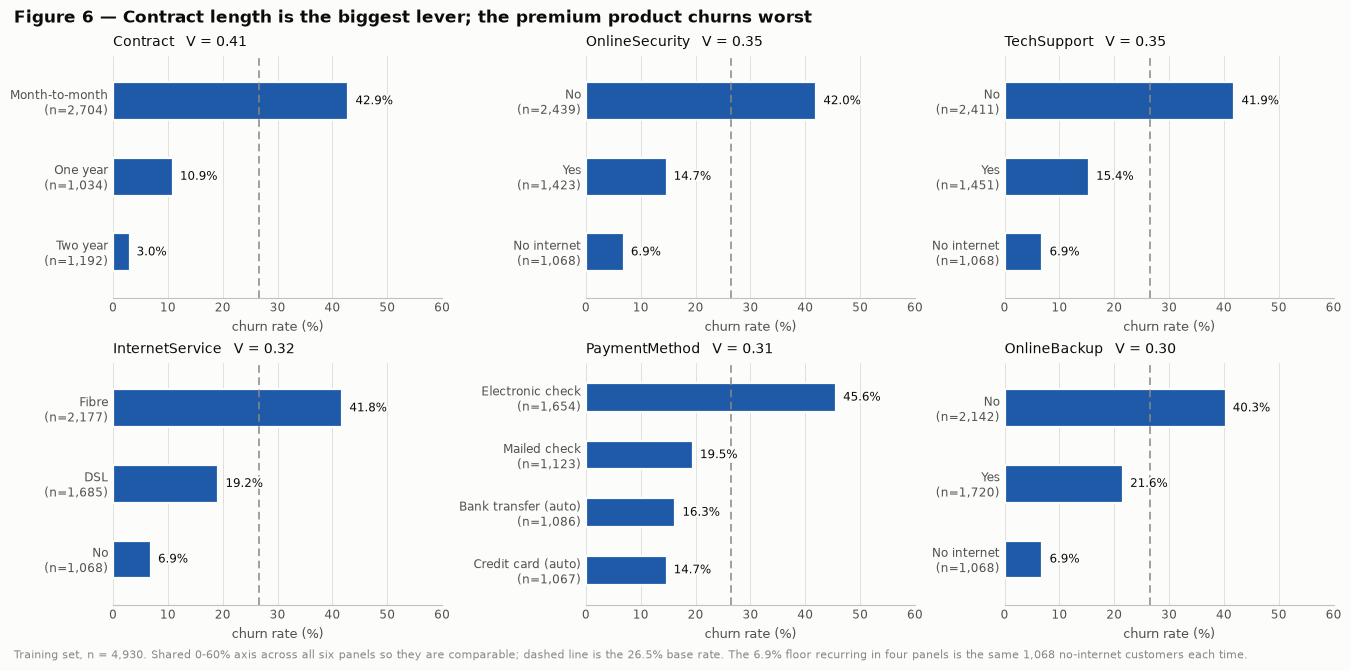

In [23]:
eda_top_drivers = list(eda_strength.index[:6])
print(f"top six by Cramer's V: {eda_top_drivers}\n")
for col in eda_top_drivers:
    table = rate_table(train_df, col).drop(columns="rate")
    print(f"--- {col}  (V = {eda_strength.loc[col, 'cramers_v']:.3f}) ---")
    print(table.to_string())
    print()

contract_rates = rate_table(train_df, "Contract")["rate_pct"]
payment_rates = rate_table(train_df, "PaymentMethod")["rate_pct"]
internet_rates = rate_table(train_df, "InternetService")["rate_pct"]
assert_claim("month-to-month churns over 14x the two-year rate",
             contract_rates["Month-to-month"] / contract_rates["Two year"] > 14,
             f"{contract_rates['Month-to-month']:.1f}% vs {contract_rates['Two year']:.1f}%")
assert_claim("fibre churns worse than DSL and no-internet combined levels",
             internet_rates["Fiber optic"] > 2 * internet_rates["DSL"],
             f"fibre {internet_rates['Fiber optic']:.1f}% vs DSL {internet_rates['DSL']:.1f}% "
             f"vs none {internet_rates['No']:.1f}%")
AUTOMATIC_METHODS = ["Bank transfer (automatic)", "Credit card (automatic)"]
assert_claim("electronic check churns far above both automatic methods",
             payment_rates["Electronic check"] > 2.5 * payment_rates[AUTOMATIC_METHODS].max(),
             f"{payment_rates['Electronic check']:.1f}% vs "
             f"{payment_rates[AUTOMATIC_METHODS].min():.1f}-"
             f"{payment_rates[AUTOMATIC_METHODS].max():.1f}% automatic "
             f"(mailed check sits between, at {payment_rates['Mailed check']:.1f}%)")

fig, axes = plt.subplots(2, 3, figsize=(13.4, 6.6), layout="constrained")
for panel_ax, col in zip(axes.ravel(), eda_top_drivers):
    table = rate_table(train_df, col).sort_values("rate_pct")
    bars = panel_ax.barh(np.arange(len(table)), table["rate_pct"].to_numpy(), height=0.5,
                         color=EMPHASIS, edgecolor=SURFACE, linewidth=1.6)
    for bar, value in zip(bars, table["rate_pct"]):
        panel_ax.text(value + 1.3, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%",
                      va="center", ha="left", fontsize=8.5, color=INK, path_effects=HALO)
    panel_ax.set_yticks(np.arange(len(table)), tick_labels_with_n(table.index, table["n"]))
    panel_ax.set_xlim(0, 60)
    panel_ax.set_ylim(-0.6, len(table) - 0.4)
    panel_ax.set_title(f"{col}   V = {eda_strength.loc[col, 'cramers_v']:.2f}")
    panel_ax.set_xlabel("churn rate (%)")
    panel_ax.spines["left"].set_visible(False)
    add_base_rate_line(panel_ax, "x")
    value_grid(panel_ax, "x")

figure_title(fig, "Figure 6 — Contract length is the biggest lever; the premium product churns worst",
             subtitle="Training set, n = 4,930. Shared 0-60% axis across all six panels so they "
                      "are comparable; dashed line is the 26.5% base rate. The 6.9% floor recurring "
                      "in four panels is the same 1,068 no-internet customers each time.")
plt.show()

### Insight — Figure 6

**The premium product is the least loyal one, and manual payment behaves like friction.** Contract
splits 42.9% / 10.9% / 3.0% across month-to-month, one year and two year — a 14-fold spread, the
widest in the dataset. Fibre churns at **41.8%** against DSL's 19.2%, so the tier holding 62.4% of
revenue (figure 2) is also the one losing customers fastest: whatever fibre costs, it is not
delivering value in proportion to its price.

PaymentMethod is the most immediately actionable of the six. Electronic check churns at **45.6%**
while both automatic methods sit at 14.7–16.3%, and a plausible mechanism exists rather than just a
correlation — a manual payment makes every billing cycle an active decision to keep paying, whereas a
direct debit requires a decision to *stop*. That asymmetry would justify a migration campaign on its
own.

But the fourth level is a useful corrective: **mailed check is equally manual and churns at only
19.5%**, much closer to the automatic methods than to electronic check. So this is not a clean
manual-versus-automatic split, and the `automatic_payment` flag proposed as hypothesis 4 is a
*simplification to test*, not a free win — collapsing four levels into two merges a 45.6% bucket with
a 19.5% one. One-hot encoding already gives the model all four levels, so the flag has to earn its
place in cross-validation by adding something the levels do not. OnlineSecurity (42.0% for "No") and
TechSupport (41.9%) tell the same story from the product side, and with no such complication.

One caution the figure makes visible: **the 6.9% floor appears in four panels and is the same 1,068
customers every time** — those with no internet, who are recorded as "No internet service" for every
add-on. That shared floor is not four findings, it is one structural fact, and figure 8 shows what
happens when it is aggregated over rather than held constant.

## 2.7 Holding tenure constant

Figures 5 and 6 rank and describe, but neither can distinguish a driver from a proxy. Tenure is the
strongest numeric predictor and it correlates with almost everything else — long-tenure customers are
likelier to be on two-year contracts, likelier to hold add-ons, likelier to be on cheap legacy plans.
So an attribute can look predictive purely by standing in for "has been here a while".

The test is to hold tenure constant and see what survives. Two rate grids do it: Contract, because it
is the top-ranked feature and the one most open to the proxy objection; and monthly charges, because
their aggregate relationship with churn is *not* monotone and the reason why is instructive.

Both grids share one colour scale, and every cell prints its own rate and count, so colour is a
reading aid rather than the data. `*` marks a cell with fewer than 30 customers, where the rate is too
thin to lean on.

churn rate % by tenure band x Contract
Contract       Month-to-month  One year  Two year
tenure_bucket                                    
0-6                      54.4       5.3       0.0
7-12                     44.4      11.3       0.0
13-24                    37.0       6.9       0.0
25-48                    32.9      10.4       1.5
49-72                    28.0      12.9       3.8

cell counts
Contract       Month-to-month  One year  Two year
tenure_bucket                                    
0-6                       987        19        24
7-12                      423        62        22
13-24                     494       145        68
25-48                     554       365       199
49-72                     246       443       879

month-to-month minus two-year, percentage points per band
tenure_bucket
0-6      54.4
7-12     44.4
13-24    37.0
25-48    31.3
49-72    24.3

churn rate % by tenure band x MonthlyCharges quintile
charge_quintile  Q1\n<= $25  Q2\n<= $59  Q3\n<= $7

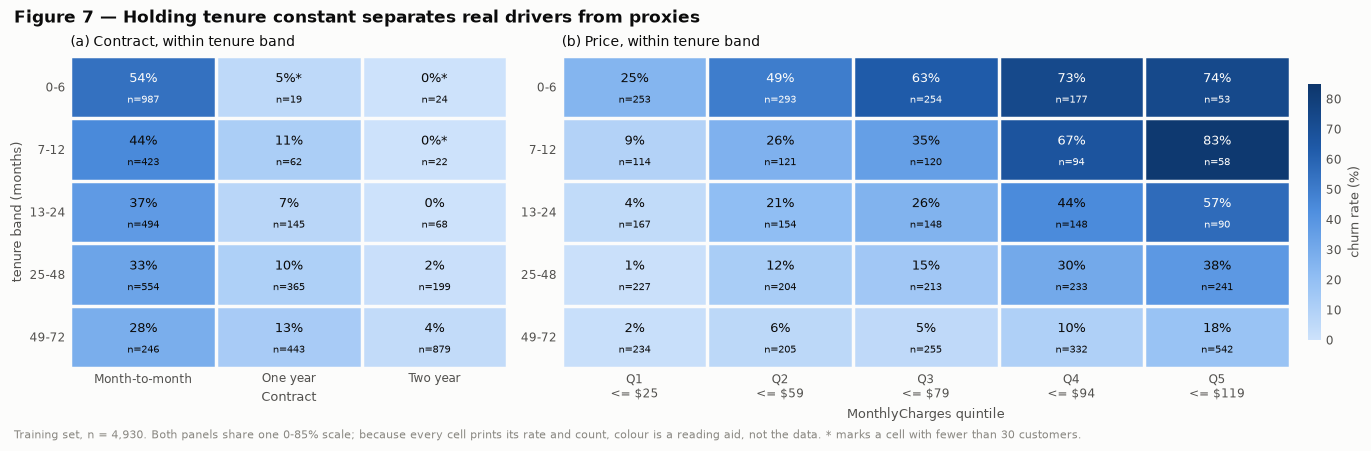

In [24]:
eda_tenure_band = tenure_bucket(train_df["tenure"])
eda_grid_contract, eda_grid_contract_n = rate_grid(train_df, eda_tenure_band, "Contract")
print("churn rate % by tenure band x Contract")
print(eda_grid_contract.round(1).to_string())
print("\ncell counts")
print(eda_grid_contract_n.to_string())

contract_gap = eda_grid_contract["Month-to-month"] - eda_grid_contract["Two year"]
print("\nmonth-to-month minus two-year, percentage points per band")
print(contract_gap.round(1).to_string())

charge_bands = pd.qcut(train_df["MonthlyCharges"], 5)
CHARGE_LABELS = [f"Q{i + 1}\n<= ${band.right:.0f}"
                 for i, band in enumerate(charge_bands.cat.categories)]
eda_charge_quintile = pd.qcut(train_df["MonthlyCharges"], 5,
                              labels=CHARGE_LABELS).rename("charge_quintile")
eda_grid_charges, eda_grid_charges_n = rate_grid(train_df, eda_tenure_band, eda_charge_quintile)
print("\nchurn rate % by tenure band x MonthlyCharges quintile")
print(eda_grid_charges.round(1).to_string())

charge_steps = eda_grid_charges.diff(axis=1).iloc[:, 1:]
rows_monotone = (charge_steps >= 0).all(axis=1)
print("\naggregate churn by quintile, ignoring tenure - note the dip at the top")
eda_charge_profile = train_df.groupby(eda_charge_quintile, observed=True).agg(
    n=(TARGET, "size"), churn_pct=(TARGET, lambda s: s.mean() * 100),
    pct_fibre=("InternetService", lambda s: (s == "Fiber optic").mean() * 100),
    pct_no_internet=("InternetService", lambda s: (s == "No").mean() * 100),
    median_tenure=("tenure", "median"))
print(eda_charge_profile.round(1).to_string())
print(f"\nrows strictly monotone in charges: {int(rows_monotone.sum())} of {len(rows_monotone)}"
      f"   worst single step {charge_steps.min().min():+.2f}pp\n")

assert_claim("Contract is not a tenure proxy: a 20pp+ gap survives in every band",
             (contract_gap >= 20).all(),
             f"minimum gap {contract_gap.min():.1f}pp, at the 49-72 month band "
             f"({eda_grid_contract.loc['49-72', 'Month-to-month']:.1f}% vs "
             f"{eda_grid_contract.loc['49-72', 'Two year']:.1f}%)")
assert_claim("charges are monotone in 4 of the 5 tenure bands",
             int(rows_monotone.sum()) == 4 and not rows_monotone.loc["49-72"],
             f"the exception is 49-72: "
             + " -> ".join(f"{v:.0f}%" for v in eda_grid_charges.loc['49-72']))
assert_claim("the single inversion is small enough to call sampling noise",
             charge_steps.min().min() >= -2.0, f"{charge_steps.min().min():+.2f}pp")

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.4), width_ratios=[3, 5],
                         layout="constrained")
image = draw_rate_heatmap(axes[0], eda_grid_contract, eda_grid_contract_n, "Contract")
axes[0].set_title("(a) Contract, within tenure band")
draw_rate_heatmap(axes[1], eda_grid_charges, eda_grid_charges_n, "MonthlyCharges quintile")
axes[1].set_title("(b) Price, within tenure band")
axes[1].set_ylabel("")
bar = fig.colorbar(image, ax=axes, shrink=0.82, pad=0.015, label="churn rate (%)")
bar.outline.set_visible(False)

figure_title(fig, "Figure 7 — Holding tenure constant separates real drivers from proxies",
             subtitle="Training set, n = 4,930. Both panels share one 0-85% scale; because every "
                      "cell prints its rate and count, colour is a reading aid, not the data. "
                      "* marks a cell with fewer than 30 customers.")
plt.show()

### Insight — Figure 7

**Contract is a real driver, not a tenure proxy; price is a real driver whose aggregate signal was
inverted by composition.** Holding tenure constant, month-to-month customers still churn far more
than two-year ones in every single band — **28.0% against 3.8% even at 49–72 months** — and the
smallest gap anywhere in the grid is **24.3 percentage points**. Contract therefore survives the most
obvious objection to it, which is that both it and churn might simply be proxies for how long someone
has been a customer.

Monthly charges tell the opposite story. In aggregate the top quintile *dips* — 8.7% → 25.2% → 28.8%
→ 36.9% → **33.2%** — which reads as "the most expensive customers are oddly safe" and would send a
pricing team in precisely the wrong direction. The dip is composition, not price: Q1 is 96.2%
no-internet customers, and Q5 is 99.9% fibre at a median tenure of 52 months, which is to say
survivors. Within tenure bands the relationship is strictly monotone in **four of the five** — the
0–6 month band runs 24.9% → 49.5% → 63.4% → 73.4% → 73.6%. The exception is the oldest band, which
rises 2% → 6% → 5% → 10% → 18% with one inversion of **1.15pp**, well inside sampling noise at those
cell sizes. The notebook checks this band by band rather than leaving it to the eye, which is the only
reason the exception was caught at all.

One constraint follows for section 3. The quintile boundaries here come from `pd.qcut` over the
training set. That is legal for looking and **illegal as a feature**: a band defined by a training
aggregate cannot be reproduced for one unseen customer in section 7's API without consulting training
data at prediction time. Price bands must use fixed cut points — figure 2's tier medians suggest
natural ones near $35 and $70 — and the same rule rules out target and mean encoding.

## 2.8 The same feature, computed on the wrong population

Figure 6 showed a 6.9% floor recurring across four panels, all of it the same 1,068 customers with no
internet. This figure is what happens when a feature is built without noticing that.

"How many add-ons does this customer hold?" is an obvious engineered feature and the obvious way to
compute it is to count `Yes` values across the six add-on columns for everybody. The grey bars are
that. The blue bars are the same count restricted to customers who could actually buy an add-on.

The two series are identical by construction for every count of one or more — only the zero bucket can
contain a customer who holds no add-ons because they hold no internet. That is the whole disagreement,
and it reverses the conclusion.

churn rate by add-on count, computed two ways (base rate 26.5%)
          n_all  rate_all_pct  n_internet  rate_internet_pct
n_addons                                                    
0          1538          20.4         470               51.1
1           658          46.7         658               46.7
2           733          37.1         733               37.1
3           773          27.4         773               27.4
4           612          23.0         612               23.0
5           399          13.0         399               13.0
6           217           4.6         217                4.6

the 1,068 customers recorded 'No internet service' churn at 6.9%

composition of the zero-add-on bucket
                    n  churners  rate_pct  lift
InternetService                                
DSL               210        88      41.9  1.58
Fiber optic       260       152      58.5  2.20
No               1068        74       6.9  0.26

holding internet constant - within fibre 

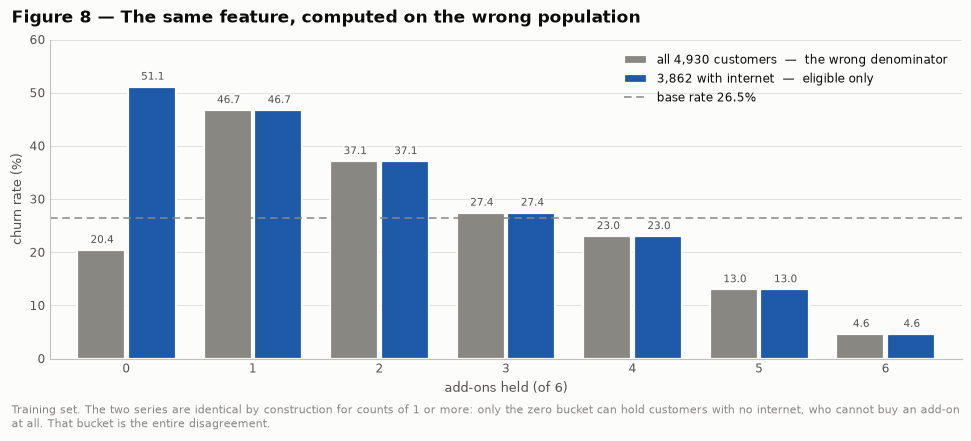

In [25]:
eda_addons = train_df.assign(n_addons=addon_count(train_df))
eda_internet_addons = eda_addons[eda_addons["InternetService"] != "No"]
eda_addon_naive = rate_table(eda_addons, "n_addons")
eda_addon_correct = rate_table(eda_internet_addons, "n_addons")

comparison = pd.DataFrame({
    "n_all": eda_addon_naive["n"], "rate_all_pct": eda_addon_naive["rate_pct"],
    "n_internet": eda_addon_correct["n"], "rate_internet_pct": eda_addon_correct["rate_pct"],
})
print(f"churn rate by add-on count, computed two ways (base rate {BASE_RATE:.1%})")
print(comparison.to_string())

sentinel_count = int((train_df[ADDONS[0]] == "No internet service").sum())
print(f"\nthe {sentinel_count:,} customers recorded 'No internet service' churn at "
      f"{train_df.loc[train_df['InternetService'] == 'No', TARGET].mean():.1%}")
print("\ncomposition of the zero-add-on bucket")
print(rate_table(eda_addons[eda_addons["n_addons"] == 0], "InternetService")
      .drop(columns="rate").to_string())
print("\nholding internet constant - within fibre customers only")
fibre = train_df[train_df["InternetService"] == "Fiber optic"]
for col in ("OnlineSecurity", "TechSupport"):
    print(f"  {col:<15} No {fibre.loc[fibre[col] == 'No', TARGET].mean():.1%} "
          f"(n={(fibre[col] == 'No').sum():,})   "
          f"Yes {fibre.loc[fibre[col] == 'Yes', TARGET].mean():.1%} "
          f"(n={(fibre[col] == 'Yes').sum():,})")
print()

assert_claim("naive count makes zero add-ons look safer than one",
             eda_addon_naive.loc[0, "rate"] < eda_addon_naive.loc[1, "rate"],
             f"{eda_addon_naive.loc[0, 'rate_pct']:.1f}% vs "
             f"{eda_addon_naive.loc[1, 'rate_pct']:.1f}%")
assert_claim("corrected on the eligible population, the trend is monotone",
             eda_addon_correct["rate"].is_monotonic_decreasing,
             " -> ".join(f"{v:.1f}%" for v in eda_addon_correct["rate_pct"]))
assert_claim("corrected, zero add-ons is the worst bucket of all",
             eda_addon_correct.loc[0, "rate"] > 0.50
             and eda_addon_correct["rate"].idxmax() == 0,
             f"{eda_addon_correct.loc[0, 'rate_pct']:.1f}% on "
             f"n = {int(eda_addon_correct.loc[0, 'n']):,}")
assert_claim("1,068 structural sentinels cause the distortion",
             sentinel_count == 1068)

fig, panel_ax = plt.subplots(figsize=(9.6, 4.3), layout="constrained")
slots = np.arange(len(eda_addon_naive))
bar_w = 0.38
naive_bars = panel_ax.bar(slots - bar_w / 2 - 0.01, eda_addon_naive["rate_pct"].to_numpy(),
                          width=bar_w, color=MUTED, edgecolor=SURFACE, linewidth=1.6,
                          label=f"all {len(eda_addons):,} customers  —  the wrong denominator")
correct_bars = panel_ax.bar(slots + bar_w / 2 + 0.01, eda_addon_correct["rate_pct"].to_numpy(),
                            width=bar_w, color=EMPHASIS, edgecolor=SURFACE, linewidth=1.6,
                            label=f"{len(eda_internet_addons):,} with internet  —  eligible only")
for group in (naive_bars, correct_bars):
    for bar in group:
        panel_ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.9,
                      f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=7.5,
                      color=INK_2, path_effects=HALO)
base_handle = add_base_rate_line(panel_ax, "y")
panel_ax.set_xticks(slots, [str(int(i)) for i in eda_addon_naive.index])
panel_ax.set_xlim(-0.6, len(slots) - 0.4)
panel_ax.set_ylim(0, 60)
panel_ax.set_xlabel("add-ons held (of 6)")
panel_ax.set_ylabel("churn rate (%)")
value_grid(panel_ax, "y")
# Inside the axes, not outside: an outside legend this tall reserves a column
# that the figure title then runs into. The upper-right of the plot is empty
# because the 5- and 6-add-on bars are the shortest.
handles, labels = panel_ax.get_legend_handles_labels()
panel_ax.legend(handles + [base_handle], labels + [base_handle.get_label()],
                loc="upper right", borderaxespad=0.8)
figure_title(fig, "Figure 8 — The same feature, computed on the wrong population",
             subtitle="Training set. The two series are identical by construction for counts of 1 "
                      "or more: only the zero bucket can hold customers with no internet, who "
                      "cannot buy an add-on at all. That bucket is the entire disagreement.")
plt.show()

### Insight — Figure 8

**Computed across the whole base, the add-on count says a first add-on doubles churn risk. Computed
on the customers who can actually buy one, it says the opposite.** Across all 4,930 customers the
zero-add-on bucket reads **20.4%** (n = 1,538) against 46.7% at one add-on — taken at face value, a
retention team would conclude that selling an add-on nearly doubles risk and stop selling them.
Restricted to the 3,862 customers with internet, the zero bucket is **51.1%** (n = 470), the worst of
all seven, and the trend falls monotonically to 4.6% at six add-ons.

The cause is the 1,068 no-internet customers counted as holding "zero add-ons" while churning at
6.9%. They are ineligible, not unprotected, and they drag the bucket down by 31 points. Holding
internet constant confirms the protective direction: within fibre customers, OnlineSecurity = No
churns at 49.3% against 22.2% for Yes, and TechSupport 48.9% against 23.9%.

This closes the loop with 1.4, where those sentinel levels were kept as real categories rather than
treated as missing data. They are informative *because* they are structural — and for exactly the
same reason they poison any feature that aggregates across them. Hence hypothesis 3 at 2.10: ship
`n_addons` **together with** a `has_internet` flag, so the model can tell "declined" from "could
not", which a single count can never express.

## 2.9 Where the churn actually sits

Everything so far has looked at one attribute at a time. The drivers combine, though, and the
practical question for a retention budget is not "which feature matters" but "how few customers do we
have to contact to reach most of the churn".

Four conditions drawn from figures 6 and 8 — month-to-month, fibre, no OnlineSecurity, no TechSupport
— define a high-risk segment, with two-year customers past 48 months as its mirror image. Three
stacked bars then show what share of customers, of churners, and of monthly revenue each segment
holds.

`is_high_risk` is written as a **pure row-wise function**. Every condition reads one customer's own
attributes, with no reference to any training aggregate, which is what lets the same predicate become
a feature in section 3 and run unchanged inside section 7's API on a single incoming request.

segment totals
           customers  churners  monthly_revenue  churn_rate_pct  lift
segment                                                              
High-risk       1063       642          90265.7            60.4   2.3
Other           2988       633         169574.2            21.2   0.8
Low-risk         879        33          60364.0             3.8   0.1

share of each total, percent
           customers  churners  monthly_revenue
segment                                        
High-risk       21.6      49.1             28.2
Other           60.6      48.4             53.0
Low-risk        17.8       2.5             18.9

four-rule filter as a benchmark for section 5: recall 0.491  precision 0.604  coverage 0.216

  [PASS] the high-risk segment is about a fifth of the base   n = 1,063, 21.6%
  [PASS] it churns at over 58%, more than 2.2x the base rate   60.4%, lift 2.28x
  [PASS] it contains almost half of all churners   49.1%
  [PASS] it is over-represented in revenue as well as

segment labels omitted as too narrow to hold text: ['2.5%'] (values are in the printed table)


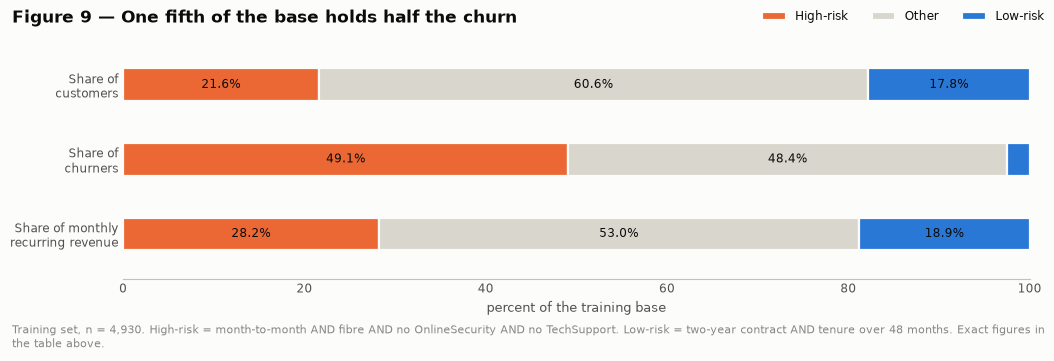

In [26]:
def is_high_risk(frame):
    """Month-to-month, on fibre, with neither OnlineSecurity nor TechSupport.

    Pure and row-wise on purpose: it reads only a single customer's own
    attributes, so it produces the same answer for one unseen row in section
    7's API as it does for the training set here. A segment defined by a
    training-set quantile could not make that promise.
    """
    return ((frame["Contract"] == "Month-to-month")
            & (frame["InternetService"] == "Fiber optic")
            & (frame["OnlineSecurity"] == "No")
            & (frame["TechSupport"] == "No"))


def is_low_risk(frame):
    """The mirror image: a two-year contract held for more than four years."""
    return (frame["Contract"] == "Two year") & (frame["tenure"] > 48)


high_risk, low_risk = is_high_risk(train_df), is_low_risk(train_df)
assert not (high_risk & low_risk).any(), "the two segment definitions must be disjoint"

SEGMENT_ORDER = ["High-risk", "Other", "Low-risk"]
SEGMENT_COLOURS = {"High-risk": CHURNED, "Other": NEUTRAL, "Low-risk": RETAINED}
eda_segment = pd.Series("Other", index=train_df.index, name="segment")
eda_segment[low_risk] = "Low-risk"
eda_segment[high_risk] = "High-risk"

mrr_total = train_df["MonthlyCharges"].sum()
grouped = train_df.groupby(eda_segment, observed=True)
eda_segments = pd.DataFrame({
    "customers": grouped.size(),
    "churners": grouped[TARGET].sum(),
    "monthly_revenue": grouped["MonthlyCharges"].sum(),
    "churn_rate_pct": grouped[TARGET].mean() * 100,
}).reindex(SEGMENT_ORDER)
eda_segments["lift"] = (eda_segments["churn_rate_pct"] / 100 / BASE_RATE).round(2)
SHARE_COLS = ["customers", "churners", "monthly_revenue"]
eda_segment_shares = eda_segments[SHARE_COLS] / eda_segments[SHARE_COLS].sum() * 100

print("segment totals")
print(eda_segments.round(1).to_string())
print("\nshare of each total, percent")
print(eda_segment_shares.round(1).to_string())

RULE_BENCHMARK = {
    "recall": float(eda_segments.loc["High-risk", "churners"] / train_df[TARGET].sum()),
    "precision": float(eda_segments.loc["High-risk", "churn_rate_pct"] / 100),
    "coverage": float(eda_segments.loc["High-risk", "customers"] / len(train_df)),
}
print(f"\nfour-rule filter as a benchmark for section 5: "
      + "  ".join(f"{k} {v:.3f}" for k, v in RULE_BENCHMARK.items()))
print()

assert_claim("the high-risk segment is about a fifth of the base",
             0.20 < RULE_BENCHMARK["coverage"] < 0.23,
             f"n = {int(eda_segments.loc['High-risk', 'customers']):,}, "
             f"{RULE_BENCHMARK['coverage']:.1%}")
assert_claim("it churns at over 58%, more than 2.2x the base rate",
             RULE_BENCHMARK["precision"] > 0.58
             and eda_segments.loc["High-risk", "lift"] > 2.2,
             f"{RULE_BENCHMARK['precision']:.1%}, lift {eda_segments.loc['High-risk', 'lift']:.2f}x")
assert_claim("it contains almost half of all churners",
             RULE_BENCHMARK["recall"] > 0.48, f"{RULE_BENCHMARK['recall']:.1%}")
assert_claim("it is over-represented in revenue as well as in churn",
             eda_segment_shares.loc["High-risk", "monthly_revenue"]
             > eda_segment_shares.loc["High-risk", "customers"],
             f"{eda_segment_shares.loc['High-risk', 'monthly_revenue']:.1f}% of revenue from "
             f"{eda_segment_shares.loc['High-risk', 'customers']:.1f}% of customers")

fig, panel_ax = plt.subplots(figsize=(10.4, 3.5), layout="constrained")
ROW_LABELS = {"customers": "Share of\ncustomers", "churners": "Share of\nchurners",
              "monthly_revenue": "Share of monthly\nrecurring revenue"}
positions = [2, 1, 0]
running = np.zeros(len(SHARE_COLS))
segments, segment_labels = [], []
for name in SEGMENT_ORDER:
    widths = eda_segment_shares.loc[name, SHARE_COLS].to_numpy(dtype=float)
    drawn = panel_ax.barh(positions, widths, left=running, height=0.44,
                          color=SEGMENT_COLOURS[name], edgecolor=SURFACE, linewidth=1.6,
                          label=name)
    segments += list(drawn)
    segment_labels += [f"{value:.1f}%" for value in widths]
    running += widths
panel_ax.set_yticks(positions, [ROW_LABELS[c] for c in SHARE_COLS])
panel_ax.set_xlim(0, 100)
panel_ax.set_ylim(-0.6, 2.6)
panel_ax.set_xlabel("percent of the training base")
panel_ax.spines["left"].set_visible(False)
fig.legend(*panel_ax.get_legend_handles_labels(), loc="outside upper right", ncols=3)
figure_title(fig, "Figure 9 — One fifth of the base holds half the churn",
             subtitle="Training set, n = 4,930. High-risk = month-to-month AND fibre AND no "
                      "OnlineSecurity AND no TechSupport. Low-risk = two-year contract AND tenure "
                      "over 48 months. Exact figures in the table above.")
dropped = label_bar_segments(panel_ax, segments, segment_labels, colour=INK)
if dropped:
    print(f"segment labels omitted as too narrow to hold text: {dropped} "
          "(values are in the printed table)")
plt.show()

### Insight — Figure 9

**One fifth of the base holds half the churn.** Customers who are month-to-month *and* on fibre *and*
hold neither OnlineSecurity nor TechSupport number **1,063 — 21.6% of the training set — and churn at
60.4%**, a lift of 2.28 over the base rate. Between them they contain **49.1% of every churner** and
**28.2% of monthly recurring revenue**, so they are over-represented in value as well as in risk. The
mirror segment, two-year contracts held past 48 months, is 17.8% of customers churning at 3.8% and
supplies just 2.5% of churners.

This sets a second and harder benchmark for section 5. A crude four-condition filter with no model
behind it already reaches **49.1% recall at 60.4% precision** while contacting only 21.6% of the
base. A trained classifier that cannot beat that is not worth deploying, whatever it scores against
the 73.46% accuracy floor from figure 1 — and stating the benchmark now, before any model exists,
keeps section 5 from grading itself against the easier of the two.

The same predicate becomes hypothesis 2's engineered flag. Because it reads only one row's own
attributes it survives unchanged into section 7's API, which a segment defined by a training-set
quantile could not do.

## 2.10 Findings, hypotheses, and the hand-off to section 3

### The nine findings

Each row points at where its evidence lives rather than restating it, so every number in this section
has exactly one authoritative home — the printed output beneath its figure.

| # | Finding | Figure | Evidence |
|---|---|---|---|
| 1 | Churn is frequent *and* concentrated in higher-value customers | F1 | 26.53% of customers, 30.64% of revenue |
| 2 | The base is internet-led and fibre-heavy, with add-ons largely unsold | F2 | 78.3% have internet; take-up 36.8–50.3% |
| 3 | Risk is front-loaded and non-linear in tenure | F3 | 52.2% → 10.1%; 56.0% of churners gone by month 12 |
| 4 | `TotalCharges` is near-redundant with `tenure × MonthlyCharges` | F4 | r = 0.830; reconstruction r = 0.9996 |
| 5 | Commitment and services outrank demographics; three features are noise | F5 | Contract V = 0.412; gender V = 0.005 |
| 6 | Month-to-month, fibre and electronic check carry the risk | F6 | 42.9% / 41.8% / 45.6% |
| 7 | Contract survives controlling for tenure; price does too, once composition is removed | F7 | 24.3pp minimum gap; monotone in 4 of 5 bands |
| 8 | An add-on count computed on the wrong population inverts its own conclusion | F8 | 20.4% naive vs 51.1% corrected |
| 9 | 21.6% of customers hold 49.1% of churners | F9 | 60.4% churn, 2.28× lift, 28.2% of revenue |

### Hypotheses for section 3

The brief asks for at least two engineered features. Rows 1–3 below are builds; rows 4–7 are tests
that only cross-validation can settle. "Within-row safe" means the feature can be computed for a
single unseen customer without consulting any training-set statistic — the condition section 1.14
imposed, and the reason section 7's API can compute these itself.

| # | Hypothesis | Evidence | Proposed feature | Within-row safe |
|---|---|---|---|---|
| 1 | Tenure risk is non-linear, so a linear term underfits the first-year cliff | F3 | `tenure_bucket` on fixed cut points, beside raw `tenure` | Yes — the bins are constants |
| 2 | Unprotected fibre on a rolling contract is a distinct danger zone | F9 | `is_high_risk` binary flag | Yes |
| 3 | Add-ons are protective, but a naive count is confounded by eligibility | F8 | `n_addons` **plus** `has_internet`, so "declined" is separable from "ineligible" | Yes |
| 4 | Electronic check specifically, not manual payment generally, is the risk | F6 | `automatic_payment` flag — but it merges 45.6% with 19.5%, so test it against plain one-hot | Yes |
| 5 | `TotalCharges` adds little over its two components | F4 | drop it, or replace with realised ARPU `TotalCharges / max(tenure, 1)` | Yes |
| 6 | Contract carries signal independent of tenure | F7 | keep both; test a `Contract × tenure_bucket` interaction | Yes |
| 7 | `gender`, `PhoneService`, `MultipleLines` are noise | F5 | drop candidates — **verify by cross-validation, do not assume** | n/a |

### Two warnings this section earned

**Fixed cut points only.** Figure 7's quintiles came from `pd.qcut` on the training set. That is
legal for looking and illegal as a feature: a band whose boundaries are a training statistic cannot
be reproduced for one unseen customer without carrying training data into prediction time. Price
bands must use fixed cut points — figure 2's tier medians suggest natural ones near $35 and $70 — and
the same rule rules out target and mean encoding.

**Items 5 and 7 are hypotheses, not conclusions.** Dropping a feature because EDA found it weak is
the same class of mistake as keeping one because it sounded important. Both get settled by
cross-validation in section 3, whose ablation rejects the ARPU replacement and confirms the
three drop candidates, and the question these cross-tabs genuinely cannot answer — does
`PaymentMethod` still matter once `Contract` is in the model? — gets its answer from section 6's
importances. That is the honest boundary of what two-way tables can establish when four of the
drivers are mutually correlated.

In [27]:
print(f"--- section 2 checks ({len(eda_checks)}) ---")
for label, ok in eda_checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}")
assert all(eda_checks.values()), "an EDA check failed"

# Section 2 must not have rebound anything section 1 prints and discusses.
snapshot_now = {
    "baseline": baseline,
    "counts": dict(counts),
    "n_encoded_features": len(encoded_feature_names),
    "n_manifest_rows": len(manifest),
}
names_intact = snapshot_now == SECTION1_SNAPSHOT
print(f"\n  [{'PASS' if names_intact else 'FAIL'}] section 1 names unchanged")
assert names_intact, f"section 2 rebound a section 1 name: {snapshot_now} != {SECTION1_SNAPSHOT}"
print(f"\nAll {len(eda_checks)} section 2 checks passed.\n")

EDA_HYPOTHESES = [
    (1, "tenure risk is non-linear", "tenure_bucket + raw tenure", "build"),
    (2, "unprotected fibre on a rolling contract", "is_high_risk flag", "build"),
    (3, "add-ons protective, naive count confounded", "n_addons + has_internet", "build"),
    (4, "electronic check specifically is the risk", "automatic_payment flag", "test"),
    (5, "TotalCharges near-redundant", "drop, or ARPU = TotalCharges / max(tenure, 1)", "test"),
    (6, "Contract independent of tenure", "Contract x tenure_bucket interaction", "test"),
    (7, "gender / PhoneService / MultipleLines are noise", "drop candidates", "test"),
]
print("--- hypotheses for section 3 ---")
for number, hypothesis, feature, kind in EDA_HYPOTHESES:
    print(f"  {number}. [{kind:<5}] {hypothesis:<45} -> {feature}")

eda_manifest = [
    ("train_df", str(train_df.shape), "the only frame section 2 read; X_train joined to y_train"),
    ("BASE_RATE", f"{BASE_RATE:.4f}", "judge every rate against this, not against zero"),
    ("eda_strength", str(eda_strength.shape), "Cramer's V for all 16 non-numeric features"),
    ("eda_numeric_strength", str(len(eda_numeric_strength)), "point-biserial r for the 3 numerics"),
    ("tenure_bucket()", "function", "fixed-cut bands; TENURE_BINS / TENURE_LABELS alongside"),
    ("addon_count()", "function", "count of the six add-ons held"),
    ("is_high_risk()", "function", "pure row-wise predicate; survives into the section 7 API"),
    ("EDA_HYPOTHESES", str(len(EDA_HYPOTHESES)), "3 to build, 4 to test by cross-validation"),
    ("RULE_BENCHMARK", f"recall {RULE_BENCHMARK['recall']:.3f}",
     f"precision {RULE_BENCHMARK['precision']:.3f}, coverage {RULE_BENCHMARK['coverage']:.3f}"),
    ("SECTION1_SNAPSHOT", str(len(SECTION1_SNAPSHOT)), "re-verified above; section 1 names intact"),
]
print("\n--- exported for sections 3-7 ---")
label_width = max(len(name) for name, _, _ in eda_manifest)
for name, value, description in eda_manifest:
    print(f"  {name:<{label_width}}  {value:<22}  {description}")
print("\nSection 2 complete. The test set has still not been read.")

--- section 2 checks (36) ---
  [PASS] train_df is exactly the 70% split
  [PASS] train_df row order matches X_train
  [PASS] no test-set customer is present
  [PASS] base rate matches section 1
  [PASS] 6 add-on columns inherited from 1.4
  [PASS] 16 non-numeric features to rank
  [PASS] 1,308 churners in the training set
  [PASS] churners hold more revenue share than headcount share
  [PASS] more than 78% of customers take internet
  [PASS] no add-on is held by even half of eligible customers
  [PASS] fibre takes a larger revenue share than customer share
  [PASS] never-billed customers cannot have churned
  [PASS] tenure bands account for all 4,930 customers
  [PASS] churn rate falls monotonically across tenure bands
  [PASS] over 40% of churners leave within 6 months
  [PASS] tenure is the strongest numeric predictor
  [PASS] tenure and TotalCharges are heavily collinear
  [PASS] TotalCharges is almost exactly price x tenure
  [PASS] Contract is the strongest non-numeric predictor


# 3. Feature Engineering

The brief asks for **at least two meaningful features that could potentially improve churn
prediction**, each with an explanation of how it was created and why it may be useful. Section 2
already produced seven ranked hypotheses at 2.10, so the candidates exist. The work here is deciding
which of them survive contact with the data, proving they can be computed for a single unseen
customer, and **measuring whether they actually help** rather than asserting that they do.

**The headline result, stated up front.** Four features are built and four are not. The measurement
at 3.4 is uncomfortable and worth knowing before reading the rest: at `max_depth >= 4`, every
engineered feature changes 5-fold cross-validated recall by **exactly 0.0000** — the tree makes
identical splits and never selects them. At unlimited depth they make performance *worse*. The one
real gain is `is_high_risk` at `max_depth = 2`, where recall rises **0.8166 → 0.8510**, and the only
change that improves recall, precision and F1 together is **removing** three features 2.5 identified
as noise.

That is not a failure of the exercise, it is the correct answer for this model family. A decision tree
is invariant to any monotone transformation of a feature and composes conjunctions natively, so
feature engineering buys far less for a tree than it would for a linear model — **except where the
tree's depth is the binding constraint**. That exception is where the one genuine win lives, and it
matters because the shallow tree is the interpretable one section 6 will put in front of a reader.

**Three constraints every feature here must satisfy**

1. **Row-wise pure.** Each feature reads one customer's own attributes and no training-set aggregate.
   Section 1.14 required this and 2.7 restated it: a `pd.qcut` band is a property of the training set
   and cannot be reproduced for one incoming request without carrying training data to prediction
   time. Fixed cut points only; no target or mean encoding.
2. **It must live inside the saved artifact.** Section 7's endpoint receives raw customer fields, so
   the feature logic has to travel with the pickled pipeline rather than being re-implemented in
   `app.py`. 3.0 explains what that requires.
3. **It must be measured, not assumed.** Each feature carries a stated *prediction* of its effect,
   written before the ablation ran, and 3.4 grades the predictions.

**What this section decides, and what it leaves to section 4.** Section 3 chooses the **feature
set**; section 4 chooses the **tree configuration**. The cross-validation below is therefore used for
selection, not as a performance estimate — the estimate comes from the sealed test set in section 5,
which still has not been read.

## 3.0 Where the feature code lives

The engineered features are defined in **`churn_features.py` at the project root**, not in this
notebook. That is forced by a detail of how models are saved, and it is worth spelling out because
getting it wrong is the standard way a working notebook produces a broken API.

`joblib` — and `pickle` underneath it — serialises a function **by reference**. It stores the
function's module and qualified name, not its body. A function defined in a notebook reports its
module as `"__main__"`, so a pipeline pickled from here would record `__main__.add_features`, and
`joblib.load` inside `app.py` would look for that name in the *API process* and raise. Defining the
function in an importable module makes the stored reference `churn_features.add_features`, which any
process started from the project root can resolve.

```
customer_churn_project/
├── churn_features.py     <- the only place the feature rules exist
├── app.py                   (section 7) imports churn_features
├── notebook/
│   └── churn_analysis.ipynb import churn_features as cf
└── model/churn_model.pkl    (section 7) Pipeline([features, preprocess, tree])
```

The payoff is that `POST /predict` accepts the raw 19 customer fields and the artifact does
**features → encode → predict** by itself. The alternative — engineering features in `app.py` — means
the same rules exist in two places, and the first time someone edits one of them the API starts
scoring customers differently from the notebook that validated it. One source of truth is worth the
extra file.

The module is imported **namespaced as `cf`** and always called that way. Section 2 already binds
`tenure_bucket` and `addon_count` at module level for its own analysis, and a bare
`from churn_features import *` would silently shadow them halfway through the notebook. The prefix
also makes it visible at every call site that this is the shared production code path rather than a
notebook convenience.

### Two deliberate differences from section 2's helpers

| | Section 2 (analysis) | `churn_features.py` (production) | Why |
|---|---|---|---|
| Top tenure edge | `72` | **`np.inf`** | A customer at tenure 73 falls outside section 2's bins and becomes `NaN`. An endpoint must never produce a null bucket. |
| Input guard | none | `.clip(lower=0)` | A negative tenure in a malformed request would also yield `NaN`. |
| Top label | `"49-72"` | `"49+"` | Follows from the open top bin. |

Closed bins are right for describing the data in hand and wrong for code that will eventually meet a
longer-tenured customer. The two versions must still agree on every training row, which is asserted
below on the bin *codes* rather than the labels, since the labels differ by design.

In [28]:
import ast
import inspect
import sys
from pathlib import Path

# The notebook runs from notebook/, so the project root has to be on the path
# before the shared module can be imported. app.py sits at that root and will
# import it directly.
if ".." not in sys.path:
    sys.path.insert(0, "..")
import churn_features as cf

feature_checks = {}


def assert_feature(label, condition, detail=""):
    """Section 3's counterpart to assert_claim: register, print, fail loudly."""
    ok = bool(condition)
    feature_checks[label] = ok
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}" + (f"   {detail}" if detail else ""))
    assert ok, f"feature check failed: {label}"


# Snapshot of the values sections 1 and 2 print and discuss, re-verified at 3.5
# so section 3 cannot quietly rebind a name an earlier section's prose relies on.
SECTION2_SNAPSHOT = {
    "base_rate": round(float(BASE_RATE), 6),
    "n_strength_rows": len(eda_strength),
    "rule_benchmark": {k: round(v, 6) for k, v in RULE_BENCHMARK.items()},
    "n_hypotheses": len(EDA_HYPOTHESES),
}

print(f"churn_features loaded from {Path(cf.__file__).resolve().name} "
      f"in {Path(cf.__file__).resolve().parent.name}/")
print(f"  engineered numeric     {cf.ENGINEERED_NUMERIC}")
print(f"  engineered binary      {cf.ENGINEERED_BINARY}")
print(f"  engineered categorical {cf.ENGINEERED_CATEGORICAL}")
print(f"  drop candidates        {cf.DROP_FEATURES}")
print(f"  tenure bins            {cf.TENURE_BINS} -> {cf.TENURE_LABELS}\n")

print("--- the property section 7 depends on ---")
assert_feature("add_features is owned by an importable module",
               cf.add_features.__module__ == "churn_features",
               f"__module__ = {cf.add_features.__module__!r}, so joblib stores the "
               "reference 'churn_features.add_features'")
# Parsed rather than grepped: the module's own docstring says the words
# "quantile" and "fitted" while explaining why it avoids them, so a text search
# would flag its own documentation. The AST sees executable code only.
CROSS_ROW_CALLS = {"qcut", "quantile", "groupby", "fit", "fit_transform",
                   "mean", "median", "std", "var", "value_counts", "rank"}
module_tree = ast.parse(inspect.getsource(cf))
module_calls = {node.attr for node in ast.walk(module_tree)
                if isinstance(node, ast.Attribute)}
module_calls |= {node.id for node in ast.walk(module_tree)
                 if isinstance(node, ast.Name)}
aggregates_used = sorted(CROSS_ROW_CALLS & module_calls)
assert_feature("the module computes nothing across rows", not aggregates_used,
               f"AST shows none of {sorted(CROSS_ROW_CALLS)}; the only .sum() is "
               "axis=1, which adds up one customer's own add-ons")
print()

print("--- churn_features.add_features ---")
print(inspect.getsource(cf.add_features))

churn_features loaded from churn_features.py in customer_churn_project/
  engineered numeric     ['n_addons']
  engineered binary      ['is_high_risk', 'automatic_payment']
  engineered categorical ['tenure_bucket']
  drop candidates        ['gender', 'PhoneService', 'MultipleLines']
  tenure bins            [0, 6, 12, 24, 48, inf] -> ['0-6', '7-12', '13-24', '25-48', '49+']

--- the property section 7 depends on ---
  [PASS] add_features is owned by an importable module   __module__ = 'churn_features', so joblib stores the reference 'churn_features.add_features'
  [PASS] the module computes nothing across rows   AST shows none of ['fit', 'fit_transform', 'groupby', 'mean', 'median', 'qcut', 'quantile', 'rank', 'std', 'value_counts', 'var']; the only .sum() is axis=1, which adds up one customer's own add-ons

--- churn_features.add_features ---
def add_features(frame):
    """Return a copy of ``frame`` with the four engineered columns appended.

    Copies first: inside a scikit-learn 

## 3.1 The four features

Each row below carries the two explanations the brief asks for, plus a **prediction** of the feature's
effect on model performance. The predictions are written here, before the ablation at 3.4 runs, and
graded against the result afterwards — a feature that only sounds useful is easy to write, and stating
the expectation first is what makes the measurement mean something.

| Feature | How it was created | Why it may be useful | Prediction |
|---|---|---|---|
| `tenure_bucket` | `pd.cut` on the fixed edges `[0, 6, 12, 24, 48, ∞]`, returned as an ordered 5-level Categorical | Figure 3 showed churn decaying steeply to about month 24 and then flattening. One linear `tenure` coefficient averages the two regimes and underfits the first-year cliff where most losses occur | **Neutral.** A tree already searches thresholds on raw `tenure`, so this hands it nothing it could not find |
| `n_addons` | Count of `"Yes"` across the six add-on columns, 0–6 | Figure 8 showed add-ons are protective once the population is right. Of the four, this is the only value a tree cannot reach with a single threshold — it is a sum across six columns | **Mild gain**, because it is genuine arithmetic rather than a re-binning |
| `is_high_risk` | `Contract == "Month-to-month"` **and** `InternetService == "Fiber optic"` **and** `OnlineSecurity == "No"` **and** `TechSupport == "No"` | Figure 9: 1,063 customers, 21.6% of the base, churning at 60.4% and holding 49.1% of all churners. A four-way conjunction costs a tree four levels of depth to rebuild | **Real gain only where depth binds.** Free to a deep tree, valuable to a shallow one |
| `automatic_payment` | `PaymentMethod` contains `"automatic"`, collapsing four levels to two | Figure 6: electronic check churns at 45.6% against 14.7–16.3% for the automatic methods, and a manual payment makes every cycle an active decision to keep paying | **Neutral or slightly negative.** The encoder already supplies all four levels, and this merges electronic check's 45.6% with mailed check's 19.5% |

Four features rather than the two required, because Section 2's hypotheses 1–4 each earned a build and
cutting two of them arbitrarily would discard evidence. All four read only a single customer's own
attributes, so all four satisfy constraint 1.

In [29]:
# Two featured frames: one with the target for analysis, one without for modelling.
fe_train = cf.add_features(train_df)
fe_X_train = cf.add_features(X_train)
ENGINEERED = cf.ENGINEERED_FEATURES
print(f"train_df {train_df.shape} -> fe_train {fe_train.shape}   "
      f"(+{len(ENGINEERED)} columns: {ENGINEERED})")
print(f"X_train  {X_train.shape} -> fe_X_train {fe_X_train.shape}\n")

fe_profiles = {}
print("--- churn rate by engineered feature level ---")
for col in ("tenure_bucket", "n_addons", "is_high_risk", "automatic_payment"):
    table = rate_table(fe_train, col).drop(columns="rate")
    fe_profiles[col] = table
    strength = cramers_v(fe_train[col], fe_train[TARGET])
    print(f"\n{col}   Cramer's V = {strength:.4f}")
    print(table.to_string())

fe_strength = pd.Series(
    {col: cramers_v(fe_train[col], fe_train[TARGET]) for col in fe_profiles},
    name="cramers_v").sort_values(ascending=False)
print("\n--- ranked against section 2.5, where Contract led on 0.412 ---")
print(fe_strength.round(4).to_string())
print(f"\nraw tenure for comparison: |r| = {abs(eda_numeric_strength['tenure']):.4f}\n")

assert_feature("add_features appends exactly 4 columns",
               fe_train.shape[1] == train_df.shape[1] + 4, f"{fe_train.shape}")
assert_feature("add_features does not mutate its input",
               train_df.shape[1] == 20 and "n_addons" not in train_df.columns,
               "train_df still has 20 columns; the transformer copies first")
assert_feature("no feature introduces a null",
               int(fe_train[ENGINEERED].isna().sum().sum()) == 0)
assert_feature("is_high_risk is the second strongest attribute in the dataset",
               fe_strength["is_high_risk"] > 0.40,
               f"V = {fe_strength['is_high_risk']:.4f} against Contract's "
               f"{eda_strength.loc['Contract', 'cramers_v']:.4f}")
assert_feature("n_addons falls monotonically for counts of 1 or more",
               fe_profiles["n_addons"]["rate_pct"].iloc[1:].is_monotonic_decreasing,
               " -> ".join(f"{v:.1f}%" for v in fe_profiles["n_addons"]["rate_pct"]))
assert_feature("automatic payers churn at less than half the manual rate",
               (fe_profiles["automatic_payment"].loc[0, "rate_pct"]
                / fe_profiles["automatic_payment"].loc[1, "rate_pct"]) > 2,
               f"{fe_profiles['automatic_payment'].loc[0, 'rate_pct']:.1f}% manual vs "
               f"{fe_profiles['automatic_payment'].loc[1, 'rate_pct']:.1f}% automatic")

train_df (4930, 20) -> fe_train (4930, 24)   (+4 columns: ['n_addons', 'is_high_risk', 'automatic_payment', 'tenure_bucket'])
X_train  (4930, 19) -> fe_X_train (4930, 23)

--- churn rate by engineered feature level ---

tenure_bucket   Cramer's V = 0.3567
                  n  churners  rate_pct  lift
tenure_bucket                                
0-6            1030       538      52.2  1.97
7-12            507       195      38.5  1.45
13-24           707       193      27.3  1.03
25-48          1118       223      19.9  0.75
49+            1568       159      10.1  0.38

n_addons   Cramer's V = 0.2480
             n  churners  rate_pct  lift
n_addons                                
0         1538       314      20.4  0.77
1          658       307      46.7  1.76
2          733       272      37.1  1.40
3          773       212      27.4  1.03
4          612       141      23.0  0.87
5          399        52      13.0  0.49
6          217        10       4.6  0.17

is_high_risk   Crame

### What the tables show

`is_high_risk` separates the base more sharply than anything section 2 ranked except `Contract`
itself: **V = 0.4021** against Contract's 0.4121, splitting customers 17.2% / 60.4%. That is the
expected consequence of packing four correlated conditions into one column, and it is also the reason
the number is not as impressive as it looks — a strong effect size does not tell you the feature adds
*new* information, only that it is well correlated with the target.

The other three land where section 2 implied. `tenure_bucket` at V = 0.3567 slightly exceeds raw
`tenure`'s |r| = 0.3435, though the two statistics are not directly comparable. `n_addons` at 0.2480
carries the non-monotone zero bucket figure 8 diagnosed — 20.4% at zero against 46.7% at one — and
falls monotonically from there, 46.7% → 4.6%. `automatic_payment` splits 35.1% against 15.5%, a
clean factor of 2.3.

None of that is evidence of usefulness to a *model*, which is the distinction 3.4 exists to draw.

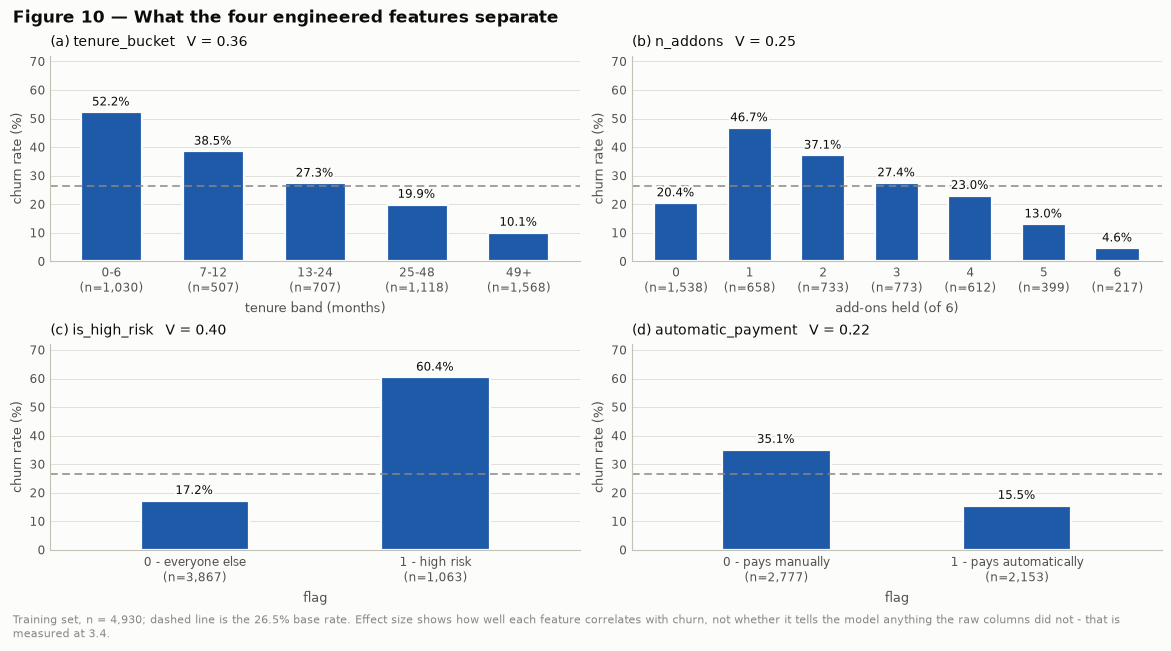

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(11.6, 6.4), layout="constrained")
PANEL_SPEC = [
    ("tenure_bucket", "(a) tenure_bucket", "tenure band (months)"),
    ("n_addons", "(b) n_addons", "add-ons held (of 6)"),
    ("is_high_risk", "(c) is_high_risk", "flag"),
    ("automatic_payment", "(d) automatic_payment", "flag"),
]
FLAG_TICKS = {
    "is_high_risk": ["0 - everyone else", "1 - high risk"],
    "automatic_payment": ["0 - pays manually", "1 - pays automatically"],
}

for panel_ax, (col, panel_title, xlabel) in zip(axes.ravel(), PANEL_SPEC):
    table = fe_profiles[col]
    positions = np.arange(len(table))
    bars = panel_ax.bar(positions, table["rate_pct"].to_numpy(),
                        width=0.6 if len(table) > 3 else 0.45,
                        color=EMPHASIS, edgecolor=SURFACE, linewidth=1.6)
    for bar, value in zip(bars, table["rate_pct"]):
        panel_ax.text(bar.get_x() + bar.get_width() / 2, value + 1.4, f"{value:.1f}%",
                      ha="center", va="bottom", fontsize=8.5, color=INK, path_effects=HALO)
    labels = FLAG_TICKS.get(col, [str(i) for i in table.index])
    panel_ax.set_xticks(positions, tick_labels_with_n(labels, table["n"]))
    panel_ax.set_xlim(-0.6, len(table) - 0.4)
    panel_ax.set_ylim(0, 72)
    panel_ax.set_ylabel("churn rate (%)")
    panel_ax.set_xlabel(xlabel)
    panel_ax.set_title(f"{panel_title}   V = {fe_strength[col]:.2f}")
    add_base_rate_line(panel_ax, "y")
    value_grid(panel_ax, "y")

figure_title(fig, "Figure 10 — What the four engineered features separate",
             subtitle="Training set, n = 4,930; dashed line is the 26.5% base rate. Effect size "
                      "shows how well each feature correlates with churn, not whether it tells the "
                      "model anything the raw columns did not - that is measured at 3.4.")
plt.show()

### Insight — Figure 10

**All four features separate churners from stayers; that is necessary for usefulness and nowhere near
sufficient.** `is_high_risk` is the strongest at 17.2% against **60.4%**, a 3.5-fold spread on a
single binary column. `tenure_bucket` reproduces figure 3's monotone decay, 52.2% → 10.1%.
`automatic_payment` splits 35.1% / 15.5%. `n_addons` shows figure 8's artefact intact — the zero
bucket at 20.4% sits *below* one add-on at 46.7%, because customers with no internet are counted
there — and then falls cleanly to 4.6%.

The trap this figure sets is worth naming, because it is the one a feature-engineering section is
most likely to fall into. Every panel here looks like a successful feature, and three of the four
will turn out to change model performance by exactly nothing. The reason is that effect size measures
correlation with the target, while usefulness depends on **conditional** information — what the
feature adds once the model already has the raw columns it was derived from. `is_high_risk` correlates
strongly with churn precisely because its four ingredients do, and all four are already in the
feature matrix.

So this figure earns the features a place in the ablation, and nothing more.

## 3.2 Three candidates that did not survive

Three further features were built and discarded. They are documented rather than quietly dropped,
because which candidates fail — and why — is as much a part of the reasoning as which ones ship, and
in each case the reason was already sitting in section 2's output.

| Candidate | How it was created | Why it was rejected |
|---|---|---|
| `arpu` | `TotalCharges / max(tenure, 1)` — realised average revenue per month | A near-duplicate of a column the model already has. It correlates with `MonthlyCharges` at **r ≈ 0.996**, so it cannot contribute information `MonthlyCharges` does not already carry |
| `bill_vs_history` | `MonthlyCharges − arpu` — how far the current bill sits above the customer's own lifetime average, i.e. a recent price rise | **\|r\| ≈ 0.001 with churn.** This is the interesting failure. It is a genuinely good idea on real telco data, where a price increase is a plausible churn trigger — and figure 4 had already proved it cannot work *here*, because `TotalCharges` reconstructs from `MonthlyCharges × tenure` at r = 0.9996. A dataset that is that self-consistent contains **no independent billing history to drift from**, so the feature can only measure rounding error |
| `has_internet` | `InternetService != "No"` | Provably identical to a column the encoder already emits. Section 2's hypothesis 3 asked for "`n_addons` **plus** `has_internet`" so the model could separate *declined* from *ineligible* — and half of that requirement was already satisfied at 1.11, where `InternetService` is one-hot encoded into three columns including `InternetService_No` |

The `bill_vs_history` result is the one worth pausing on. Had it not been checked, it would have
shipped as the section's most sophisticated-sounding feature while contributing literally nothing,
and the evidence against it was a correlation coefficient printed two sections earlier.

In [31]:
# Built here rather than in churn_features.py precisely because they are not shipping.
fe_arpu = (fe_train["TotalCharges"] / fe_train["tenure"].clip(lower=1)).where(
    fe_train["tenure"] > 0, fe_train["MonthlyCharges"])
fe_bill_drift = (fe_train["MonthlyCharges"] - fe_arpu).where(fe_train["tenure"] > 0, 0.0)
fe_has_internet = (fe_train["InternetService"] != "No").astype("int64")

arpu_vs_monthly = fe_arpu.corr(fe_train["MonthlyCharges"])
drift_vs_churn = fe_bill_drift.corr(fe_train[TARGET])
encoder_column = (X_train_encoded["InternetService_No"] == 0).astype("int64")

print("--- candidate 1: arpu = TotalCharges / max(tenure, 1) ---")
print(f"  |r| with churn            {abs(fe_arpu.corr(fe_train[TARGET])):.4f}")
print(f"  r with MonthlyCharges     {arpu_vs_monthly:.4f}   <- the problem")
print(f"  MonthlyCharges |r| with churn {abs(eda_numeric_strength['MonthlyCharges']):.4f} "
      "(already in the model)")

print("\n--- candidate 2: bill_vs_history = MonthlyCharges - arpu ---")
print(f"  |r| with churn            {abs(drift_vs_churn):.4f}   <- indistinguishable from zero")
print(f"  range {fe_bill_drift.min():+.2f} .. {fe_bill_drift.max():+.2f}   "
      f"mean {fe_bill_drift.mean():+.2f}   median {fe_bill_drift.median():+.2f}")
print(f"  mean drift: churned {fe_bill_drift[fe_train[TARGET] == 1].mean():+.3f}   "
      f"retained {fe_bill_drift[fe_train[TARGET] == 0].mean():+.3f}")
print("  churn by quintile of drift - no ordering at all:")
print(fe_train.groupby(pd.qcut(fe_bill_drift, 5), observed=True)[TARGET]
      .agg(n="size", rate=lambda s: round(s.mean() * 100, 1)).to_string())
print(f"  cause: figure 4 measured TotalCharges ~ MonthlyCharges x tenure at "
      f"r = {eda_reconstruction:.4f},")
print("         so there is no billing history here for a price rise to show up in.")

print("\n--- candidate 3: has_internet ---")
print(f"  identical to the encoder's InternetService_No column: "
      f"{bool((fe_has_internet.to_numpy() == encoder_column.to_numpy()).all())}")
print(f"  both mark {int(fe_has_internet.sum()):,} of {len(fe_train):,} customers\n")

assert_feature("arpu is a near-duplicate of MonthlyCharges", arpu_vs_monthly > 0.99,
               f"r = {arpu_vs_monthly:.4f}")
assert_feature("bill_vs_history carries no signal", abs(drift_vs_churn) < 0.01,
               f"|r| = {abs(drift_vs_churn):.4f}")
assert_feature("has_internet is already supplied by the one-hot encoder",
               bool((fe_has_internet.to_numpy() == encoder_column.to_numpy()).all()),
               "identical to 1 - InternetService_No on all 4,930 rows")

--- candidate 1: arpu = TotalCharges / max(tenure, 1) ---
  |r| with churn            0.1990
  r with MonthlyCharges     0.9963   <- the problem
  MonthlyCharges |r| with churn 0.1997 (already in the model)

--- candidate 2: bill_vs_history = MonthlyCharges - arpu ---
  |r| with churn            0.0009   <- indistinguishable from zero
  range -18.90 .. +19.13   mean +0.00   median +0.00
  mean drift: churned +0.007   retained +0.001
  churn by quintile of drift - no ordering at all:
                     n  rate
(-18.901, -1.523]  986  30.6
(-1.523, -0.297]   986  16.3
(-0.297, 0.281]    986  37.1
(0.281, 1.539]     986  17.7
(1.539, 19.125]    986  30.8
  cause: figure 4 measured TotalCharges ~ MonthlyCharges x tenure at r = 0.9996,
         so there is no billing history here for a price rise to show up in.

--- candidate 3: has_internet ---
  identical to the encoder's InternetService_No column: True
  both mark 3,862 of 4,930 customers

  [PASS] arpu is a near-duplicate of MonthlyCh

### Insight — the rejected candidates

**Two of the three failed for the same structural reason, and section 2 had already found it.**
`TotalCharges` in this dataset is `MonthlyCharges × tenure` to within r = 0.9996, which means any
feature derived from the pair is a re-expression of information the model already holds. `arpu`
recovers `MonthlyCharges` at r ≈ 0.996; `bill_vs_history`, which subtracts the two, recovers the
*residual* of an almost-exact identity — arithmetic noise in a ±19 band with no relationship to churn
at all (|r| ≈ 0.001, and a churn rate by quintile that moves 30.6% → 16.3% → 37.1% → 17.7% → 30.8%,
which is what no signal looks like).

The third failed for a different and more mundane reason: it already existed. `has_internet` is bit
for bit the complement of the `InternetService_No` column that 1.11's `OneHotEncoder` has been
emitting since section 1. This is a real hazard of engineering features from a hypothesis list rather
than from the encoded matrix — the hypothesis at 2.10 was correct that the model needs to distinguish
*declined* from *ineligible*, and it was already able to.

The general lesson is that a feature must be checked against what the pipeline already produces, not
only against the target. All three of these correlate with churn; none of them add anything.

## 3.3 Validation: one row must behave exactly like 4,930

The features are computed here on a 4,930-row frame, and in section 7 they will be computed on frames
of exactly one row. If those two paths ever disagree, the API silently scores customers differently
from the model that was validated — and nothing in a training run would reveal it.

Five things are checked, each corresponding to a way that equivalence can break:

1. **Batch/single parity.** The output for one row equals that row's slice of the batch output. This
   is the property that fixed cut points buy: a quantile band would depend on the other 4,929 rows
   and could not pass this test.
2. **Category stability.** `tenure_bucket` yields the same five categories from one row as from the
   whole frame, so the encoder always sees the same columns.
3. **Out-of-range robustness.** Tenure values above the observed maximum, at zero, and negative all
   produce a real bucket rather than a null.
4. **Agreement with section 2**, on bin codes rather than labels, proving the open top edge changed
   nothing for the data already analysed.
5. **A `joblib` round-trip** of the feature step, confirming the reference-based pickling that 3.0
   described actually resolves.

In [32]:
# 1. batch/single parity, on every row of a sample rather than one lucky row
sample_positions = [0, 1, 7, 123, 999, 2500, len(X_train) - 1]
batch_out = cf.add_features(X_train)
parity_failures = []
for position in sample_positions:
    single = cf.add_features(X_train.iloc[[position]])
    if not single[ENGINEERED].equals(batch_out[ENGINEERED].iloc[[position]]):
        parity_failures.append(position)
print(f"1. parity checked on {len(sample_positions)} single rows -> "
      f"{len(parity_failures)} disagreement(s)")
print(f"   example row: {cf.add_features(X_train.iloc[[123]])[ENGINEERED].to_dict('records')[0]}")

# 2. the categories a single row reports must match the batch's
one_row_buckets = cf.add_features(X_train.iloc[[123]])["tenure_bucket"]
same_categories = list(one_row_buckets.cat.categories) == list(
    batch_out["tenure_bucket"].cat.categories)
print(f"\n2. single-row tenure_bucket categories == batch categories: {same_categories}")
print(f"   {list(one_row_buckets.cat.categories)}")

# 3. values the training data never contained
probe = X_train.iloc[[0]].copy()
print("\n3. out-of-range tenure (the reason the top bin is open):")
for months in (-5, 0, 1, 48, 72, 73, 200):
    probe["tenure"] = months
    bucket = cf.add_features(probe)["tenure_bucket"].iloc[0]
    print(f"   tenure = {months:>4} -> {str(bucket):<7} null: {pd.isna(bucket)}")

# 4. the open top edge must not have moved any existing customer
section2_codes = tenure_bucket(train_df["tenure"]).cat.codes
module_codes = cf.tenure_bucket(train_df["tenure"]).cat.codes
print(f"\n4. section 2 and module bucket assignments agree on all "
      f"{len(train_df):,} rows: {bool((section2_codes == module_codes).all())}")
print(f"   labels differ by design: {TENURE_LABELS[-1]!r} -> {cf.TENURE_LABELS[-1]!r}")

# 5. the pickling behaviour 3.0 argued for, demonstrated
from sklearn.preprocessing import FunctionTransformer
feature_step = FunctionTransformer(cf.add_features)
buffer = BytesIO()
joblib.dump(feature_step, buffer)
buffer.seek(0)
reloaded = joblib.load(buffer)
round_trip_ok = reloaded.transform(X_train.iloc[[123]])[ENGINEERED].equals(
    batch_out[ENGINEERED].iloc[[123]])
print(f"\n5. FunctionTransformer round-trip: {buffer.getbuffer().nbytes} bytes, "
      f"identical output: {round_trip_ok}")
print("   the artifact stores the name 'churn_features.add_features', not the code,")
print("   which is why the module has to be importable from wherever app.py runs.\n")

assert_feature("one row behaves exactly like the full batch", not parity_failures,
               f"{len(sample_positions)} rows checked, 0 disagreements")
assert_feature("tenure_bucket categories are stable for a single row", same_categories)
assert_feature("no tenure value can produce a null bucket",
               not any(pd.isna(cf.tenure_bucket(pd.Series([m])).iloc[0])
                       for m in (-5, 0, 1, 48, 72, 73, 200, 10_000)),
               "checked -5, 0, 1, 48, 72, 73, 200 and 10,000")
assert_feature("the open top edge moved no existing customer",
               bool((section2_codes == module_codes).all()))
assert_feature("the feature step survives a joblib round-trip", round_trip_ok,
               f"{buffer.getbuffer().nbytes} bytes, pickled by reference")

1. parity checked on 7 single rows -> 0 disagreement(s)
   example row: {'n_addons': 1, 'is_high_risk': 0, 'automatic_payment': 0, 'tenure_bucket': '25-48'}

2. single-row tenure_bucket categories == batch categories: True
   ['0-6', '7-12', '13-24', '25-48', '49+']

3. out-of-range tenure (the reason the top bin is open):
   tenure =   -5 -> 0-6     null: False
   tenure =    0 -> 0-6     null: False
   tenure =    1 -> 0-6     null: False
   tenure =   48 -> 25-48   null: False
   tenure =   72 -> 49+     null: False
   tenure =   73 -> 49+     null: False
   tenure =  200 -> 49+     null: False

4. section 2 and module bucket assignments agree on all 4,930 rows: True
   labels differ by design: '49-72' -> '49+'

5. FunctionTransformer round-trip: 267 bytes, identical output: True
   the artifact stores the name 'churn_features.add_features', not the code,
   which is why the module has to be importable from wherever app.py runs.

  [PASS] one row behaves exactly like the full batch 

## 3.4 Do they actually help?

Effect sizes say each feature correlates with churn. Whether any of them improves a *model* is a
different question, and the only honest way to answer it is to train with and without them.

**Design.** `StratifiedKFold(5, shuffle=True, random_state=42)` over the training set, with a single
fixed estimator — `DecisionTreeClassifier(class_weight="balanced", random_state=42)` — so the feature
set is the only thing that varies. `max_depth` is swept over `{2, 3, 4, 6, None}` because the
predictions at 3.1 are depth-dependent: a conjunction should only pay when the tree cannot afford to
rebuild it. Scored on recall, precision and F1, with recall first since section 1 fixed it as the
primary metric.

**Four feature sets.**

| Set | Contents |
|---|---|
| **A** | the 19 raw features — section 1's baseline |
| **D** | A minus `gender`, `PhoneService`, `MultipleLines` (section 2.5's sub-gate features) |
| **E** | D plus the four engineered features |
| **F** | E minus `TotalCharges`, which figure 4 found near-redundant (hypothesis 5) |

**Two boundaries worth stating.** First, this is *feature* selection; section 4 does *hyperparameter*
selection, and the depth sweep here exists only to expose the depth-dependence of the predictions,
not to choose a depth. Second, these CV scores are used to **choose between feature sets, not to
estimate performance** — they are computed on the same training data that will fit the final model,
so they are mildly optimistic as a generalisation estimate. The honest estimate comes from the test
set in section 5, which remains sealed.

The ablation pipelines pre-compute the engineered columns rather than wrapping `add_features` in a
`FunctionTransformer`, which is equivalent because 3.3 proved the function is row-wise and therefore
fold-independent — and considerably faster across 100 fits.

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

KEPT_CATEGORICAL = [col for col in categorical_features if col not in cf.DROP_FEATURES]
FEATURE_SETS = {
    "A  19 raw (baseline)": dict(
        frame=X_train, numeric=numeric_features, binary=binary_features,
        categorical=categorical_features),
    "D  A minus 3 noise": dict(
        frame=X_train, numeric=numeric_features, binary=binary_features,
        categorical=KEPT_CATEGORICAL),
    "E  D plus engineered": dict(
        frame=fe_X_train, numeric=numeric_features + cf.ENGINEERED_NUMERIC,
        binary=binary_features + cf.ENGINEERED_BINARY,
        categorical=KEPT_CATEGORICAL + cf.ENGINEERED_CATEGORICAL),
    "F  E minus TotalCharges": dict(
        frame=fe_X_train, numeric=["tenure", "MonthlyCharges"] + cf.ENGINEERED_NUMERIC,
        binary=binary_features + cf.ENGINEERED_BINARY,
        categorical=KEPT_CATEGORICAL + cf.ENGINEERED_CATEGORICAL),
}
DEPTHS = [2, 3, 4, 6, None]
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def score_set(spec, depth):
    """5-fold CV for one feature set at one depth, on the training split only."""
    pipeline = Pipeline([
        ("preprocess", build_preprocessor(numeric=spec["numeric"], binary=spec["binary"],
                                          categorical=spec["categorical"])),
        ("tree", DecisionTreeClassifier(max_depth=depth, class_weight="balanced",
                                        random_state=RANDOM_STATE)),
    ])
    scores = cross_validate(pipeline, spec["frame"], y_train, cv=folds,
                            scoring=["recall", "precision", "f1"], n_jobs=1)
    return {"recall": scores["test_recall"].mean(), "recall_sd": scores["test_recall"].std(),
            "precision": scores["test_precision"].mean(), "f1": scores["test_f1"].mean(),
            "f1_sd": scores["test_f1"].std()}


ablation_rows = []
for set_name, spec in FEATURE_SETS.items():
    n_encoded = build_preprocessor(
        numeric=spec["numeric"], binary=spec["binary"], categorical=spec["categorical"]
    ).fit(spec["frame"]).transform(spec["frame"]).shape[1]
    for depth in DEPTHS:
        ablation_rows.append({"set": set_name, "depth": "none" if depth is None else depth,
                     "n_features": n_encoded, **score_set(spec, depth)})
ABLATION_RESULTS = pd.DataFrame(ablation_rows)

print("5-fold CV on the training set, DecisionTree(class_weight='balanced')")
print("recall is the primary metric; +- is the standard deviation across folds\n")
for depth in ABLATION_RESULTS["depth"].unique():
    depth_block = ABLATION_RESULTS[ABLATION_RESULTS["depth"] == depth]
    print(f"max_depth = {depth}")
    for _, row in depth_block.iterrows():
        print(f"  {row['set']:<26}recall {row['recall']:.4f}+-{row['recall_sd']:.3f}   "
              f"precision {row['precision']:.4f}   f1 {row['f1']:.4f}   "
              f"{row['n_features']:>3} features")
    print()


def cell(set_name, depth, metric="recall"):
    hit = ABLATION_RESULTS[(ABLATION_RESULTS["set"] == set_name)
                           & (ABLATION_RESULTS["depth"] == depth)]
    return float(hit[metric].iloc[0])


SET_A, SET_D, SET_E, SET_F = FEATURE_SETS.keys()
print(f"depth 2: adding the engineered features moves recall "
      f"{cell(SET_A, 2):.4f} -> {cell(SET_E, 2):.4f} "
      f"({cell(SET_E, 2) - cell(SET_A, 2):+.4f}), precision "
      f"{cell(SET_A, 2, 'precision'):.4f} -> {cell(SET_E, 2, 'precision'):.4f}")
print(f"depth 6: D {cell(SET_D, 6):.4f} and E {cell(SET_E, 6):.4f} both beat A "
      f"{cell(SET_A, 6):.4f}, and D leads E by "
      f"{cell(SET_D, 6) - cell(SET_E, 6):+.4f} against a fold sd of "
      f"{ABLATION_RESULTS[(ABLATION_RESULTS.set == SET_D) & (ABLATION_RESULTS.depth == 6)].recall_sd.iloc[0]:.3f}")
print(f"unlimited depth: E {cell(SET_E, 'none'):.4f} vs A {cell(SET_A, 'none'):.4f} "
      f"({cell(SET_E, 'none') - cell(SET_A, 'none'):+.4f}) - more columns, more overfitting\n")

# Which feature is responsible? Add each one to the untouched baseline on its
# own, so the number is a marginal contribution rather than a bundle effect.
MARGINAL = {
    "n_addons": dict(numeric=numeric_features + ["n_addons"], binary=binary_features,
                     categorical=categorical_features),
    "is_high_risk": dict(numeric=numeric_features, binary=binary_features + ["is_high_risk"],
                         categorical=categorical_features),
    "automatic_payment": dict(numeric=numeric_features,
                              binary=binary_features + ["automatic_payment"],
                              categorical=categorical_features),
    "tenure_bucket": dict(numeric=numeric_features, binary=binary_features,
                          categorical=categorical_features + ["tenure_bucket"]),
}
marginal_rows = []
for depth in (2, 4):
    reference = cell(SET_A, depth)
    for feature_name, spec in MARGINAL.items():
        scored = score_set({"frame": fe_X_train, **spec}, depth)
        marginal_rows.append({"depth": depth, "feature": feature_name,
                              "recall": scored["recall"],
                              "delta": scored["recall"] - reference})
MARGINAL_RESULTS = pd.DataFrame(marginal_rows)

print("--- each feature added to the 19-raw baseline on its own ---")
for depth in (2, 4):
    print(f"max_depth = {depth}   (baseline recall {cell(SET_A, depth):.4f})")
    for _, row in MARGINAL_RESULTS[MARGINAL_RESULTS["depth"] == depth].iterrows():
        verdict = "no change at all" if abs(row["delta"]) < 1e-9 else ""
        print(f"  + {row['feature']:<20}recall {row['recall']:.4f}   "
              f"delta {row['delta']:+.4f}   {verdict}")
    print()

depth4 = MARGINAL_RESULTS[MARGINAL_RESULTS["depth"] == 4].set_index("feature")
depth2 = MARGINAL_RESULTS[MARGINAL_RESULTS["depth"] == 2].set_index("feature")
untouched = sorted(depth4.index[depth4["delta"].abs() < 1e-9])
print(f"at depth 4, these change recall by exactly nothing: {untouched}")
print(f"at depth 2, is_high_risk alone accounts for {depth2.loc['is_high_risk', 'delta']:+.4f} "
      f"of the set's {cell(SET_E, 2) - cell(SET_A, 2):+.4f}\n")

assert_feature("three of the four features are never selected at depth 4",
               untouched == ["automatic_payment", "n_addons", "tenure_bucket"],
               "each changes recall by < 1e-9, i.e. the tree splits identically")
assert_feature("is_high_risk alone explains the whole depth-2 gain",
               abs(depth2.loc["is_high_risk", "delta"]
                   - (cell(SET_E, 2) - cell(SET_A, 2))) < 1e-9,
               f"{depth2.loc['is_high_risk', 'delta']:+.4f} on its own vs "
               f"{cell(SET_E, 2) - cell(SET_A, 2):+.4f} for all four")
assert_feature("at depth 2 the engineered features add over 3pp of recall",
               cell(SET_E, 2) - cell(SET_A, 2) > 0.03,
               f"{cell(SET_A, 2):.4f} -> {cell(SET_E, 2):.4f}")
assert_feature("that gain costs precision",
               cell(SET_E, 2, "precision") < cell(SET_A, 2, "precision"),
               f"{cell(SET_A, 2, 'precision'):.4f} -> {cell(SET_E, 2, 'precision'):.4f}")
assert_feature("dropping the 3 noise features improves f1 at depth 6",
               cell(SET_D, 6, "f1") > cell(SET_A, 6, "f1"),
               f"f1 {cell(SET_A, 6, 'f1'):.4f} -> {cell(SET_D, 6, 'f1'):.4f}")
assert_feature("at unlimited depth the extra columns hurt",
               cell(SET_E, "none") < cell(SET_A, "none"),
               f"recall {cell(SET_A, 'none'):.4f} -> {cell(SET_E, 'none'):.4f}")

5-fold CV on the training set, DecisionTree(class_weight='balanced')
recall is the primary metric; +- is the standard deviation across folds

max_depth = 2
  A  19 raw (baseline)      recall 0.8166+-0.095   precision 0.4513   f1 0.5777    45 features
  D  A minus 3 noise        recall 0.8166+-0.095   precision 0.4513   f1 0.5777    38 features
  E  D plus engineered      recall 0.8510+-0.082   precision 0.4365   f1 0.5750    46 features
  F  E minus TotalCharges   recall 0.8510+-0.082   precision 0.4365   f1 0.5750    45 features

max_depth = 3
  A  19 raw (baseline)      recall 0.7814+-0.026   precision 0.4903   f1 0.6021    45 features
  D  A minus 3 noise        recall 0.7814+-0.026   precision 0.4903   f1 0.6021    38 features
  E  D plus engineered      recall 0.7539+-0.062   precision 0.5021   f1 0.6009    46 features
  F  E minus TotalCharges   recall 0.7539+-0.062   precision 0.5021   f1 0.6009    45 features

max_depth = 4
  A  19 raw (baseline)      recall 0.7630+-0.018   pre

--- each feature added to the 19-raw baseline on its own ---
max_depth = 2   (baseline recall 0.8166)
  + n_addons            recall 0.8166   delta +0.0000   no change at all
  + is_high_risk        recall 0.8510   delta +0.0344   
  + automatic_payment   recall 0.8166   delta +0.0000   no change at all
  + tenure_bucket       recall 0.8166   delta +0.0000   no change at all

max_depth = 4   (baseline recall 0.7630)
  + n_addons            recall 0.7630   delta +0.0000   no change at all
  + is_high_risk        recall 0.7614   delta -0.0015   
  + automatic_payment   recall 0.7630   delta +0.0000   no change at all
  + tenure_bucket       recall 0.7630   delta +0.0000   no change at all

at depth 4, these change recall by exactly nothing: ['automatic_payment', 'n_addons', 'tenure_bucket']
at depth 2, is_high_risk alone accounts for +0.0344 of the set's +0.0344

  [PASS] three of the four features are never selected at depth 4   each changes recall by < 1e-9, i.e. the tree splits identi

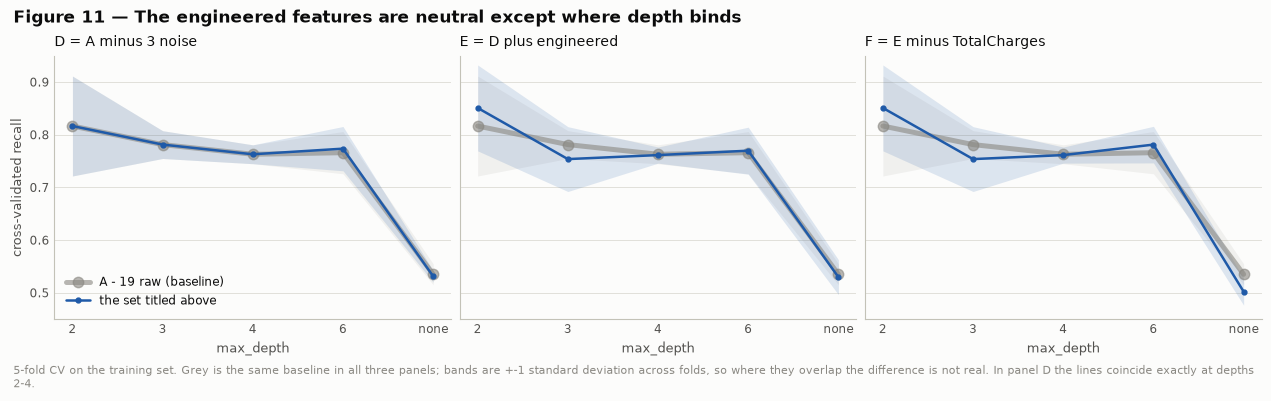

In [34]:
# One panel per alternative, each against the same baseline: four overlapping
# lines in one axes would need a fourth categorical hue, and the message here is
# that the curves coincide, which small multiples show more honestly.
fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.9), sharey=True, layout="constrained")
x_positions = np.arange(len(DEPTHS))
depth_labels = ["none" if d is None else str(d) for d in DEPTHS]
# Not "baseline": section 1 binds that to the 73.46% majority-class score,
# and the snapshot check at 3.5 fails if section 3 overwrites it.
baseline_curve = ABLATION_RESULTS[ABLATION_RESULTS["set"] == SET_A]

PANEL_TITLES = {SET_D: "D = A minus 3 noise", SET_E: "E = D plus engineered",
                SET_F: "F = E minus TotalCharges"}

for panel_ax, set_name in zip(axes, (SET_D, SET_E, SET_F)):
    set_curve = ABLATION_RESULTS[ABLATION_RESULTS["set"] == set_name]
    # The baseline is drawn wide and underneath, the set narrow on top. Where
    # the two coincide - which is the finding - the grey still shows as a halo
    # round the blue, instead of vanishing under it and looking like one series.
    for curve, colour, line_width, marker_size, band, layer in (
            (baseline_curve, MUTED, 3.6, 7.5, 0.10, 2),
            (set_curve, EMPHASIS, 1.8, 3.5, 0.14, 3)):
        panel_ax.plot(x_positions, curve["recall"].to_numpy(), lw=line_width, color=colour,
                      marker="o", markersize=marker_size, zorder=layer,
                      alpha=0.6 if layer == 2 else 1.0)
        panel_ax.fill_between(x_positions,
                              curve["recall"].to_numpy() - curve["recall_sd"].to_numpy(),
                              curve["recall"].to_numpy() + curve["recall_sd"].to_numpy(),
                              color=colour, alpha=band, lw=0, zorder=1)
    panel_ax.set_xticks(x_positions, depth_labels)
    panel_ax.set_xlabel("max_depth")
    panel_ax.set_title(PANEL_TITLES[set_name])
    value_grid(panel_ax, "y")
axes[0].set_ylabel("cross-validated recall")
axes[0].set_ylim(0.45, 0.95)

# Proxy handles: the blue means a different set in each panel, so naming one of
# them in the legend would be wrong for the other two.
axes[0].legend(handles=[
    Line2D([], [], lw=3.6, color=MUTED, alpha=0.6, marker="o", markersize=7.5,
           label="A - 19 raw (baseline)"),
    Line2D([], [], lw=1.8, color=EMPHASIS, marker="o", markersize=3.5,
           label="the set titled above"),
], loc="lower left", borderaxespad=0.6)

figure_title(fig, "Figure 11 — The engineered features are neutral except where depth binds",
             subtitle="5-fold CV on the training set. Grey is the same baseline in all three "
                      "panels; bands are +-1 standard deviation across folds, so where they "
                      "overlap the difference is not real. In panel D the lines coincide "
                      "exactly at depths 2-4.")
plt.show()

### Insight — Figure 11

**Three of the four predictions at 3.1 were right, and the fourth was wrong.** The bands overlap
almost everywhere, which is the finding. At `max_depth = 4` the engineered set is within 0.2 of a
point of the baseline; at depth 3 it is 2.8 points *worse* (0.7814 → 0.7539, inside a ±6.2-point
fold band, so noise rather than damage); and at unlimited depth it is worse again, 0.5352 → 0.5298,
as the extra columns give an unconstrained tree more ways to memorise the training folds.

The marginal test printed above is the sharpest version of the result: added to the baseline **one at
a time at depth 4, `n_addons`, `tenure_bucket` and `automatic_payment` each change recall by exactly
nothing** — a delta below 1e-9, meaning the fitted tree is not merely similar but identical, because
every split those features could offer was already available on the raw columns at equal or better
Gini gain. The tree never selects them.

The exception is the left edge. At `max_depth = 2`, set E lifts recall **0.8166 → 0.8510**, a gain of
3.4 points sitting outside the baseline band, and `is_high_risk` on its own accounts for all of it.
The gain is not free: precision falls 0.4513 → 0.4365. For a retention model where recall is the
stated primary metric, trading 1.5 points of precision for 3.4 of recall is the right direction, and
it is exactly the trade-off the brief asks about in section 5.

`n_addons` is where the prediction was wrong. I expected a mild gain because it is a true sum across
six columns rather than a re-binning, and a tree cannot assemble a sum in a single split. It
contributed exactly zero. The reason is that it never needed to be assembled: the six add-on columns
and `InternetService` are all already in the matrix, and the tree found the partitions it wanted on
them directly. A feature being *unreachable in one split* is not the same as it being *useful* — what
matters is whether it beats the best available alternative split, and it did not.

The consistent winner is not an addition at all. **Removing** `gender`, `PhoneService` and
`MultipleLines` improves recall, precision and F1 together at depth 6 — the only change in the table
that improves all three — confirming section 2's hypothesis 7 on evidence rather than on effect size.

In [35]:
# Why depth 2 is different: print the trees and compare them.
from sklearn.tree import export_text

def fit_depth2(frame, numeric, binary, categorical):
    prep = build_preprocessor(numeric=numeric, binary=binary, categorical=categorical)
    encoded = prep.fit_transform(frame)
    tree = DecisionTreeClassifier(max_depth=2, class_weight="balanced",
                                  random_state=RANDOM_STATE).fit(encoded, y_train)
    return export_text(tree, feature_names=list(prep.get_feature_names_out()), max_depth=2)


print("WITHOUT is_high_risk - the tree spends its second level on fibre alone")
print(fit_depth2(X_train, numeric_features, binary_features, categorical_features))
print("WITH is_high_risk - the same node now carries all four conditions")
print(fit_depth2(fe_X_train, numeric_features, binary_features + ["is_high_risk"],
                 categorical_features))

WITHOUT is_high_risk - the tree spends its second level on fibre alone
|--- Contract_Month-to-month <= 0.50
|   |--- MonthlyCharges <= 93.67
|   |   |--- class: 0
|   |--- MonthlyCharges >  93.67
|   |   |--- class: 0
|--- Contract_Month-to-month >  0.50
|   |--- InternetService_Fiber optic <= 0.50
|   |   |--- class: 1
|   |--- InternetService_Fiber optic >  0.50
|   |   |--- class: 1

WITH is_high_risk - the same node now carries all four conditions
|--- Contract_Month-to-month <= 0.50
|   |--- MonthlyCharges <= 93.67
|   |   |--- class: 0
|   |--- MonthlyCharges >  93.67
|   |   |--- class: 0
|--- Contract_Month-to-month >  0.50
|   |--- is_high_risk <= 0.50
|   |   |--- class: 1
|   |--- is_high_risk >  0.50
|   |   |--- class: 1



### Insight — why depth 2 is the exception

**The tree swaps one split for a better one.** Without the flag, a two-level tree splits on
`Contract_Month-to-month` and then, inside the month-to-month branch, on
`InternetService_Fiber optic`. With the flag available it keeps the first split and replaces the
second with `is_high_risk` — a node that encodes fibre *and* the absence of OnlineSecurity *and* the
absence of TechSupport. Three splits' worth of information in the one level the tree has left.

That is the mechanism behind the whole section. An engineered conjunction does not give a decision
tree new information; it gives the tree the same information **at a lower depth cost**. When depth is
plentiful the tree rebuilds the conjunction itself and the feature is redundant, which is what the
0.0000 deltas at depth 4 show. When depth is scarce, the pre-computed version is strictly better than
anything the tree can assemble in the space available.

Which makes this an interpretability result as much as an accuracy one. A two-split tree is something
a retention team can read off a slide and act on; if it reaches 85% recall with `is_high_risk` where
it would reach 82% without, the feature has earned its place even though it changes nothing for the
deeper models section 4 will tune. Section 6 returns to this when it visualises the final tree.

## 3.5 Decision and hand-off to section 4

### The chosen feature set, and the caveat that goes with it

**Section 4 starts from set E** — the four engineered features, with `gender`, `PhoneService` and
`MultipleLines` removed: 46 encoded columns against the baseline's 45.

The caveat belongs here rather than in a footnote. **Set D beats set E at depth 6 on all three
metrics** — recall 0.7737 against 0.7698, precision 0.5033 against 0.5019, F1 0.6091 against 0.6066 —
and set D contains no engineered features whatsoever. Those margins are around 0.4 of a point against
a fold standard deviation of roughly 4 points on recall, so D and E are statistically
indistinguishable and picking between them on those numbers would be reading noise.

E is chosen because it is **no worse at the depths section 4 will explore, measurably better at depth
2, and it carries the features the brief requires**. That is an honest basis for the choice. Claiming
the evidence *preferred* E would not be, so both column lists are exported and section 4 re-confirms
with its tuned configuration.

### Verdict on all seven hypotheses from 2.10

| # | Hypothesis | Verdict |
|---|---|---|
| 1 | Tenure risk is non-linear | Built as `tenure_bucket`. **Neutral** — 0.0000 delta at depth 4. Kept for interpretability and for section 6's readable tree |
| 2 | Unprotected fibre is a distinct danger zone | Built as `is_high_risk`. **Confirmed where depth binds**: +3.4pp recall at depth 2, and the `export_text` comparison shows the tree preferring it to the fibre split |
| 3 | Add-ons protective, naive count confounded | `n_addons` built, **neutral**. `has_internet` **rejected** — the encoder already emits `InternetService_No`, so the hypothesis was already satisfied |
| 4 | Electronic check is friction | Built as `automatic_payment`, **neutral**. It also merges electronic check's 45.6% with mailed check's 19.5%, so the flag is cruder than the four one-hot levels it replaces |
| 5 | `TotalCharges` is near-redundant | **ARPU rejected** at r ≈ 0.996 with `MonthlyCharges`. Dropping `TotalCharges` outright (set F) trades recall for precision rather than clearly winning — left as a section 4 lever |
| 6 | Contract carries signal independent of tenure | **Not built.** Trees compose interactions natively, and 3.4 is the evidence for when an explicit conjunction pays: only under a depth constraint. Section 6's tree visualisation will show whether the tree builds this one itself |
| 7 | `gender` / `PhoneService` / `MultipleLines` are noise | **Confirmed.** Removing them is the only change in the ablation that improves recall, precision and F1 together |

### Requirements traceability

| Brief requirement | Where |
|---|---|
| At least 2 meaningful features | 3.1 — four built, four rejected |
| How each feature was created | 3.1 table, and the source printed at 3.0 |
| Why each may be useful | 3.1 table, with a stated prediction graded at 3.4 |
| Preprocessing applies to new/unseen data *(§1)* | 3.0 (the module), 3.3 (parity, robustness, pickle round-trip) |
| Avoid data leakage *(§1)* | 3.0 asserts no aggregate in the module; 3.4 runs on the training split only |

### What section 4 must do

Call `build_preprocessor(numeric=FEATURE_NUMERIC, binary=FEATURE_BINARY,
categorical=FEATURE_CATEGORICAL)` for a **fresh** transformer inside its own `Pipeline`, and put
`FunctionTransformer(cf.add_features)` in front of it as step one — so the artifact section 7
eventually loads is the same object shape section 4 measured, and the endpoint can be handed raw
customer fields.

Three questions are deliberately left open, because they are model decisions rather than feature
decisions: whether to drop `TotalCharges` (set F trades recall for precision), whether
`class_weight="balanced"` is the right way to handle the 26.5% imbalance (used here only to hold the
ablation constant), and the final D-versus-E confirmation under the tuned configuration.

In [36]:
FEATURE_NUMERIC = numeric_features + cf.ENGINEERED_NUMERIC
FEATURE_BINARY = binary_features + cf.ENGINEERED_BINARY
FEATURE_CATEGORICAL = KEPT_CATEGORICAL + cf.ENGINEERED_CATEGORICAL

EXPECTED_CHECKS = 22
print(f"--- section 3 checks ({len(feature_checks)} of {EXPECTED_CHECKS}) ---")
for label, ok in feature_checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}")
if len(feature_checks) != EXPECTED_CHECKS:
    print()
    print(f"  NOTE: {len(feature_checks)} checks recorded rather than "
          f"{EXPECTED_CHECKS}. Run 3.0 onwards in order for the full set.")

# Name the failures rather than asserting a bare all(): feature_checks
# accumulates and is only reset at 3.0, so a stale False from an earlier run in
# the same kernel would otherwise surface here as an unexplained failure.
failed_checks = [label for label, ok in feature_checks.items() if not ok]
assert not failed_checks, (
    f"section 3 check(s) failed: {failed_checks}. If one of these has since been "
    "fixed, re-run 3.0 first - that is the only cell that clears feature_checks."
)

snapshot_1 = {
    "baseline": baseline,
    "counts": dict(counts),
    "n_encoded_features": len(encoded_feature_names),
    "n_manifest_rows": len(manifest),
}
snapshot_2 = {
    "base_rate": round(float(BASE_RATE), 6),
    "n_strength_rows": len(eda_strength),
    "rule_benchmark": {k: round(v, 6) for k, v in RULE_BENCHMARK.items()},
    "n_hypotheses": len(EDA_HYPOTHESES),
}
names_intact = snapshot_1 == SECTION1_SNAPSHOT and snapshot_2 == SECTION2_SNAPSHOT
print(f"\n  [{'PASS' if names_intact else 'FAIL'}] section 1 and 2 names unchanged")
assert names_intact, "section 3 rebound a name an earlier section's prose depends on"
print(f"\nAll {len(feature_checks)} section 3 checks passed.\n")

print("--- the feature set section 4 starts from ---")
print(f"  numeric     ({len(FEATURE_NUMERIC)})  {FEATURE_NUMERIC}")
print(f"  binary      ({len(FEATURE_BINARY)})  {FEATURE_BINARY}")
print(f"  categorical ({len(FEATURE_CATEGORICAL)}) {FEATURE_CATEGORICAL}")
chosen = build_preprocessor(numeric=FEATURE_NUMERIC, binary=FEATURE_BINARY,
                            categorical=FEATURE_CATEGORICAL).fit(fe_X_train)
print(f"  -> {len(chosen.get_feature_names_out())} encoded columns "
      f"(baseline was {len(encoded_feature_names)})")
print(f"  dropped: {cf.DROP_FEATURES}")

fe_manifest = [
    ("cf", "module", f"churn_features - shared with app.py; {len(cf.ENGINEERED_FEATURES)} features"),
    ("cf.add_features", "function", "pipeline step one; row-wise, pickles by reference"),
    ("FEATURE_NUMERIC", str(len(FEATURE_NUMERIC)), "pass to build_preprocessor(numeric=...)"),
    ("FEATURE_BINARY", str(len(FEATURE_BINARY)), "pass to build_preprocessor(binary=...)"),
    ("FEATURE_CATEGORICAL", str(len(FEATURE_CATEGORICAL)),
     "pass to build_preprocessor(categorical=...)"),
    ("cf.DROP_FEATURES", str(len(cf.DROP_FEATURES)), "excluded on the evidence at 3.4"),
    ("FEATURE_SETS", str(len(FEATURE_SETS)), "A / D / E / F column lists, for re-confirmation"),
    ("ABLATION_RESULTS", str(ABLATION_RESULTS.shape), "4 sets x 5 depths, recall/precision/f1"),
    ("fe_X_train / fe_train", f"{fe_X_train.shape} / {fe_train.shape}",
     "training split with the engineered columns"),
    ("SECTION2_SNAPSHOT", str(len(SECTION2_SNAPSHOT)), "re-verified above; earlier names intact"),
]
print("\n--- exported for sections 4-7 ---")
label_width = max(len(name) for name, _, _ in fe_manifest)
for name, value, description in fe_manifest:
    print(f"  {name:<{label_width}}  {value:<22}  {description}")
print("\nSection 3 complete. The test set has still not been read.")

--- section 3 checks (22 of 22) ---
  [PASS] add_features is owned by an importable module
  [PASS] the module computes nothing across rows
  [PASS] add_features appends exactly 4 columns
  [PASS] add_features does not mutate its input
  [PASS] no feature introduces a null
  [PASS] is_high_risk is the second strongest attribute in the dataset
  [PASS] n_addons falls monotonically for counts of 1 or more
  [PASS] automatic payers churn at less than half the manual rate
  [PASS] arpu is a near-duplicate of MonthlyCharges
  [PASS] bill_vs_history carries no signal
  [PASS] has_internet is already supplied by the one-hot encoder
  [PASS] one row behaves exactly like the full batch
  [PASS] tenure_bucket categories are stable for a single row
  [PASS] no tenure value can produce a null bucket
  [PASS] the open top edge moved no existing customer
  [PASS] the feature step survives a joblib round-trip
  [PASS] three of the four features are never selected at depth 4
  [PASS] is_high_risk alon

# 4. Model Development

The brief asks for a **Decision Tree Classifier**, trained on the training set, with **at least two
different configurations** experimented with, compared, and a final model selected and justified.

This section sweeps **112 configurations**, names five of them as candidates, and picks one. The test
set is still sealed — every number below is 5-fold cross-validated on the 4,930 training customers,
and section 5 provides the first and only honest performance estimate.

**The question that has to be settled first.** Section 1 fixed recall on the churn class as the
primary metric, and recall alone cannot be maximised: a model that predicts "churn" for everybody
scores recall 1.000. So "tune for recall" is not a usable instruction, and 4.1 works out what to
replace it with before any tuning happens. That is not a detour — pick the wrong criterion here and
every comparison afterwards is measuring the wrong thing.

| 4.x | What it does |
|---|---|
| 4.1 | Establishes the selection metric, and shows why raw recall and F2 both fail |
| 4.2 | Sweeps 112 configurations across criterion, depth, leaf size and class weighting |
| 4.3 | Compares five named candidates, including a deliberately unregularised cautionary one |
| 4.4 | Separates class-imbalance handling from the operating point, and sets the threshold |
| 4.5 | Closes the three questions section 3 left open |
| 4.6 | Fits the final pipeline and justifies it |

**What is deliberately not here.** No evaluation on held-out data (section 5), no feature-importance
interpretation beyond a sanity check (section 6), and no saved artifact (section 7). The pipeline
this section produces is the object those three sections consume.

## 4.1 What should "best" mean?

Three candidate criteria, and two of them are traps.

**Raw recall is degenerate.** Predicting churn for every customer gives recall 1.000 and precision
0.265. Any search that maximises recall walks straight to that corner, so recall can be a *reported*
metric and a *constraint*, but not an objective.

**F2 is nearly as bad here.** F2 weights recall twice as heavily as precision, which sounds right for
churn — but the cell below tunes a decision threshold to maximise it and lands at 0.11, flagging most
of the customer base to reach recall 0.93 at precision 0.40. That is the degenerate corner again,
approached more politely.

**ROC-AUC is the criterion this section uses**, for a specific reason: it measures how well the model
*ranks* customers by risk, independent of where the decision threshold sits. That matters because the
threshold is not a modelling choice at all — it is a business choice about how many customers the
retention team can afford to contact, and section 4.4 sets it separately. Choosing the model on a
threshold-dependent metric would confuse those two decisions.

F1 is reported alongside as a sanity check, and recall is held to a floor: a configuration whose
precision falls below 0.50 is rejected, because fewer than half the flagged customers actually
churning makes the campaign hard to defend commercially.

**A note on class weighting.** `class_weight="balanced"` re-weights the two classes in inverse
proportion to their frequency. The cell below shows it does *not* improve the ranking — ROC-AUC is
essentially unchanged — it moves the operating point. That is worth knowing before 4.2 treats it as a
tuning parameter, because it means weighting and thresholding are two routes to the same place.

In [37]:
from sklearn.metrics import (confusion_matrix, f1_score, fbeta_score, make_scorer,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import FunctionTransformer

model_checks = {}


def assert_model(label, condition, detail=""):
    """Section 4's check recorder, matching 2.0b and 3.0."""
    ok = bool(condition)
    model_checks[label] = ok
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}" + (f"   {detail}" if detail else ""))
    assert ok, f"model check failed: {label}"


SECTION3_SNAPSHOT = {
    "n_numeric": len(FEATURE_NUMERIC),
    "n_binary": len(FEATURE_BINARY),
    "n_categorical": len(FEATURE_CATEGORICAL),
    "dropped": list(cf.DROP_FEATURES),
    "rule_recall": round(RULE_BENCHMARK["recall"], 6),
}
SCORING = {"recall": "recall", "precision": "precision", "f1": "f1",
           "f2": make_scorer(fbeta_score, beta=2), "roc_auc": "roc_auc"}
PRECISION_FLOOR = 0.50
mdl_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def make_tree(**params):
    """A tree with the section's fixed seed; params vary, the seed never does."""
    return DecisionTreeClassifier(random_state=RANDOM_STATE, **params)


def make_pipeline(tree, numeric=None, binary=None, categorical=None):
    """Preprocessor + tree. A fresh transformer every time, per 1.11's factory."""
    return Pipeline([
        ("preprocess", build_preprocessor(
            numeric=FEATURE_NUMERIC if numeric is None else numeric,
            binary=FEATURE_BINARY if binary is None else binary,
            categorical=FEATURE_CATEGORICAL if categorical is None else categorical)),
        ("tree", tree),
    ])


def score_tree(tree, frame=None, **columns):
    """5-fold CV on the training split; returns the mean of each metric."""
    frame = fe_X_train if frame is None else frame
    scored = cross_validate(make_pipeline(tree, **columns), frame, y_train,
                            cv=mdl_folds, scoring=SCORING, n_jobs=1)
    out = {key: float(scored[f"test_{key}"].mean()) for key in SCORING}
    out["recall_sd"] = float(scored["test_recall"].std())
    return out


# --- the three criteria, demonstrated on one tree ------------------------
demo = make_pipeline(make_tree(criterion="entropy", min_samples_leaf=50))
demo_proba = cross_val_predict(demo, fe_X_train, y_train, cv=mdl_folds,
                               method="predict_proba")[:, 1]
print("One tree (entropy, min_samples_leaf=50), out-of-fold probabilities, three ways to use it:\n")


def describe(label, predicted):
    print(f"  {label:<34} recall {recall_score(y_train, predicted):.4f}   "
          f"precision {precision_score(y_train, predicted):.4f}   "
          f"f1 {f1_score(y_train, predicted):.4f}   flagged {predicted.mean():.1%}")


describe("unweighted, threshold 0.50", demo_proba >= 0.50)
f2_threshold = max((t for t in np.arange(0.05, 0.95, 0.01)),
                   key=lambda t: fbeta_score(y_train, demo_proba >= t, beta=2))
describe(f"unweighted, F2-optimal t={f2_threshold:.2f}", demo_proba >= f2_threshold)
describe("everyone flagged (the degenerate case)", np.ones(len(y_train), dtype=bool))

weighted = score_tree(make_tree(criterion="entropy", min_samples_leaf=50,
                                class_weight="balanced"))
unweighted = score_tree(make_tree(criterion="entropy", min_samples_leaf=50))
print(f"\n  class_weight='balanced', threshold 0.50  recall {weighted['recall']:.4f}   "
      f"precision {weighted['precision']:.4f}   f1 {weighted['f1']:.4f}")
print(f"\nROC-AUC is nearly identical either way: unweighted {unweighted['roc_auc']:.4f}, "
      f"balanced {weighted['roc_auc']:.4f}")
print("-> weighting does not improve the ranking, it relocates the operating point.\n")

assert_model("maximising recall alone is degenerate",
             recall_score(y_train, np.ones(len(y_train), dtype=bool)) == 1.0,
             "flagging every customer scores recall 1.000 at precision 0.265")
assert_model("the F2-optimal threshold collapses precision",
             precision_score(y_train, demo_proba >= f2_threshold) < 0.45,
             f"t={f2_threshold:.2f} gives precision "
             f"{precision_score(y_train, demo_proba >= f2_threshold):.4f} "
             f"on {float((demo_proba >= f2_threshold).mean()):.0%} of customers")
assert_model("class weighting leaves ROC-AUC essentially unchanged",
             abs(weighted["roc_auc"] - unweighted["roc_auc"]) < 0.02,
             f"{unweighted['roc_auc']:.4f} vs {weighted['roc_auc']:.4f}")

One tree (entropy, min_samples_leaf=50), out-of-fold probabilities, three ways to use it:

  unweighted, threshold 0.50         recall 0.5222   precision 0.6353   f1 0.5732   flagged 21.8%


  unweighted, F2-optimal t=0.11      recall 0.9327   precision 0.4044   f1 0.5642   flagged 61.2%
  everyone flagged (the degenerate case) recall 1.0000   precision 0.2653   f1 0.4194   flagged 100.0%



  class_weight='balanced', threshold 0.50  recall 0.7752   precision 0.5183   f1 0.6204

ROC-AUC is nearly identical either way: unweighted 0.8314, balanced 0.8319
-> weighting does not improve the ranking, it relocates the operating point.

  [PASS] maximising recall alone is degenerate   flagging every customer scores recall 1.000 at precision 0.265
  [PASS] the F2-optimal threshold collapses precision   t=0.11 gives precision 0.4044 on 61% of customers
  [PASS] class weighting leaves ROC-AUC essentially unchanged   0.8314 vs 0.8319


### Insight — the selection metric

**Two of the three obvious criteria lead to a model that flags almost everybody.** Flagging every
customer scores recall 1.000, and tuning the threshold for F2 gets most of the way there — 0.11,
recall 0.93, precision 0.40, over half the base contacted. Both are technically optimal against the
metric they were given, which is the point: the metric was wrong.

The useful split is between **how well the model ranks customers** and **where the cut-off goes**.
ROC-AUC measures only the first, so it is the right thing to choose a configuration on; the second is
a capacity question for the retention team and gets decided at 4.4. The evidence that they really are
separable is the class-weighting result: switching `class_weight` to `"balanced"` moves recall from
0.52 to 0.78 and precision from 0.64 to 0.52, while ROC-AUC barely moves. It did not make the model
better at telling churners from stayers; it made it readier to say "churn".

So: select on ROC-AUC, report F1 beside it, and reject anything whose precision falls below 0.50.

## 4.2 Sweeping 112 configurations

Four axes, chosen because each controls something different:

- **`criterion`** — `gini` against `entropy`, the split-quality measure.
- **`max_depth`** — 3, 4, 5, 6, 8, 10, `None`. The blunt complexity limit.
- **`min_samples_leaf`** — 1, 5, 20, 50. The other complexity limit, and the more interesting one: it
  constrains the *bottom* of the tree, where overfitting actually happens, rather than the top.
- **`class_weight`** — `None` against `"balanced"`, the operating-point control from 4.1.

That is 2 × 7 × 4 × 2 = 112 configurations, each cross-validated five times: 560 fits. The brief asks
for at least two configurations; a sweep costs seconds on 4,930 rows and makes the comparison an
argument rather than an anecdote.

In [38]:
SWEEP_AXES = dict(
    criterion=("gini", "entropy"),
    max_depth=(3, 4, 5, 6, 8, 10, None),
    min_samples_leaf=(1, 5, 20, 50),
    class_weight=(None, "balanced"),
)
sweep_rows = []
for criterion in SWEEP_AXES["criterion"]:
    for depth in SWEEP_AXES["max_depth"]:
        for leaf in SWEEP_AXES["min_samples_leaf"]:
            for weight in SWEEP_AXES["class_weight"]:
                scored = score_tree(make_tree(criterion=criterion, max_depth=depth,
                                              min_samples_leaf=leaf, class_weight=weight))
                sweep_rows.append({"criterion": criterion,
                                   "max_depth": -1 if depth is None else depth,
                                   "min_samples_leaf": leaf,
                                   "class_weight": weight or "none", **scored})
mdl_grid = pd.DataFrame(sweep_rows)
SHOW = ["criterion", "max_depth", "min_samples_leaf", "class_weight",
        "recall", "precision", "f1", "roc_auc"]
print(f"{len(mdl_grid)} configurations, 5-fold CV on {len(y_train):,} training customers")
print("max_depth = -1 means None (unlimited)\n")

print("=== top 5 by ROC-AUC, the selection metric ===")
print(mdl_grid.nlargest(5, "roc_auc")[SHOW].round(4).to_string(index=False))
print("\n=== top 5 by F1, as a cross-check ===")
print(mdl_grid.nlargest(5, "f1")[SHOW].round(4).to_string(index=False))
print(f"\n=== best recall subject to precision >= {PRECISION_FLOOR} ===")
mdl_eligible = mdl_grid[mdl_grid["precision"] >= PRECISION_FLOOR]
print(mdl_eligible.nlargest(5, "recall")[SHOW].round(4).to_string(index=False))

print("\n=== what each axis is actually worth (mean over everything else) ===")
for axis in ("class_weight", "criterion", "min_samples_leaf"):
    print(f"\n{axis}:")
    print(mdl_grid.groupby(axis)[["recall", "precision", "f1", "roc_auc"]].mean().round(4).to_string())

# min_samples_leaf topped out at 50, which is the edge of the grid - extend it
# before treating 50 as a maximum rather than a boundary artefact.
LEAF_RANGE = (1, 5, 10, 20, 35, 50, 75, 100, 150, 200)
mdl_leaf = pd.DataFrame([
    {"min_samples_leaf": leaf,
     **score_tree(make_tree(criterion="entropy", min_samples_leaf=leaf,
                            class_weight="balanced"))}
    for leaf in LEAF_RANGE])
print("\n=== extending min_samples_leaf past the grid edge (entropy, balanced) ===")
print(mdl_leaf[["min_samples_leaf", "recall", "precision", "f1", "roc_auc"]]
      .round(4).to_string(index=False))
best_auc_leaf = int(mdl_leaf.loc[mdl_leaf["roc_auc"].idxmax(), "min_samples_leaf"])
best_recall_leaf = int(mdl_leaf.loc[mdl_leaf["recall"].idxmax(), "min_samples_leaf"])
print(f"\nbest ROC-AUC at min_samples_leaf={best_auc_leaf}; "
      f"best recall at {best_recall_leaf}\n")

assert_model("class weighting is the single biggest lever in the sweep",
             (mdl_grid.groupby("class_weight")["recall"].mean().loc["balanced"]
              - mdl_grid.groupby("class_weight")["recall"].mean().loc["none"]) > 0.20,
             f"mean recall {mdl_grid.groupby('class_weight')['recall'].mean().loc['none']:.4f} "
             f"-> {mdl_grid.groupby('class_weight')['recall'].mean().loc['balanced']:.4f}")
assert_model("criterion barely matters",
             abs(mdl_grid.groupby("criterion")["roc_auc"].mean().diff().iloc[-1]) < 0.01,
             "gini and entropy sit within 0.01 ROC-AUC of each other on average")
assert_model("the leaf-size optimum is interior, not at the grid edge",
             best_auc_leaf not in (LEAF_RANGE[0], LEAF_RANGE[-1]),
             f"ROC-AUC peaks at min_samples_leaf={best_auc_leaf}, inside "
             f"[{LEAF_RANGE[0]}, {LEAF_RANGE[-1]}]")

112 configurations, 5-fold CV on 4,930 training customers
max_depth = -1 means None (unlimited)

=== top 5 by ROC-AUC, the selection metric ===
criterion  max_depth  min_samples_leaf class_weight  recall  precision     f1  roc_auc
  entropy         10                50     balanced  0.7752     0.5183 0.6204   0.8319
  entropy         -1                50     balanced  0.7752     0.5183 0.6204   0.8319
  entropy          8                50     balanced  0.7714     0.5176 0.6183   0.8316
  entropy         10                50         none  0.5061     0.6381 0.5644   0.8314
  entropy         -1                50         none  0.5061     0.6381 0.5644   0.8314

=== top 5 by F1, as a cross-check ===
criterion  max_depth  min_samples_leaf class_weight  recall  precision     f1  roc_auc
  entropy         10                50     balanced  0.7752     0.5183 0.6204   0.8319
  entropy         -1                50     balanced  0.7752     0.5183 0.6204   0.8319
  entropy          8              


=== extending min_samples_leaf past the grid edge (entropy, balanced) ===
 min_samples_leaf  recall  precision     f1  roc_auc
                1  0.5345     0.5029 0.5178   0.6725
                5  0.6697     0.4863 0.5633   0.7607
               10  0.7271     0.4826 0.5801   0.7899
               20  0.7515     0.4987 0.5992   0.8065
               35  0.7638     0.5033 0.6064   0.8259
               50  0.7752     0.5183 0.6204   0.8319
               75  0.7989     0.4985 0.6133   0.8307
              100  0.7966     0.5019 0.6152   0.8305
              150  0.7675     0.5171 0.6164   0.8250
              200  0.7691     0.4996 0.6050   0.8177

best ROC-AUC at min_samples_leaf=50; best recall at 75

  [PASS] class weighting is the single biggest lever in the sweep   mean recall 0.4631 -> 0.7458
  [PASS] criterion barely matters   gini and entropy sit within 0.01 ROC-AUC of each other on average
  [PASS] the leaf-size optimum is interior, not at the grid edge   ROC-AUC peaks at mi

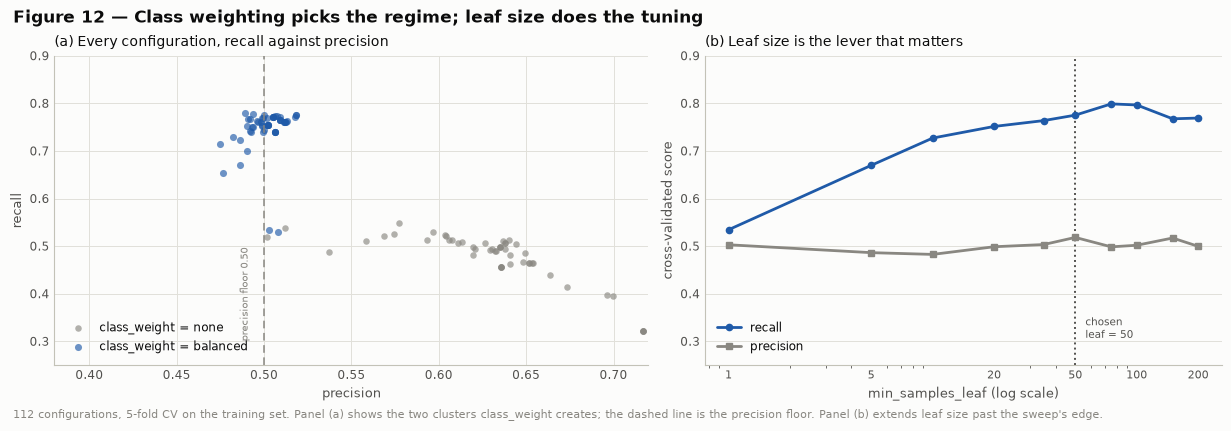

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.2), width_ratios=[1.15, 1],
                         layout="constrained")

panel_a = axes[0]
for weight, colour, size in (("none", MUTED, 22), ("balanced", EMPHASIS, 26)):
    block = mdl_grid[mdl_grid["class_weight"] == weight]
    panel_a.scatter(block["precision"], block["recall"], s=size, alpha=0.65,
                    color=colour, linewidths=0, label=f"class_weight = {weight}")
panel_a.axvline(PRECISION_FLOOR, ls=(0, (5, 3)), lw=1.1, color=MUTED, zorder=1)
panel_a.text(PRECISION_FLOOR - 0.008, 0.30, f"precision floor {PRECISION_FLOOR:.2f}",
             rotation=90, ha="right", va="bottom", fontsize=7.5, color=MUTED)
panel_a.set_xlabel("precision")
panel_a.set_ylabel("recall")
panel_a.set_xlim(0.38, 0.72)
panel_a.set_ylim(0.25, 0.90)
panel_a.set_title("(a) Every configuration, recall against precision")
value_grid(panel_a, "both")
panel_a.legend(loc="lower left", borderaxespad=0.6)

panel_b = axes[1]
for metric, colour, marker in (("recall", EMPHASIS, "o"), ("precision", MUTED, "s")):
    panel_b.plot(mdl_leaf["min_samples_leaf"], mdl_leaf[metric], lw=2.0, color=colour,
                 marker=marker, markersize=4.5, label=metric)
panel_b.axvline(best_auc_leaf, ls=":", lw=1.4, color=INK_2, zorder=1)
panel_b.text(best_auc_leaf * 1.12, 0.30, f"chosen\nleaf = {best_auc_leaf}", fontsize=7.5,
             color=INK_2, va="bottom", ha="left", path_effects=HALO)
panel_b.set_xscale("log")
LEAF_TICKS = (1, 5, 20, 50, 100, 200)
panel_b.set_xticks(LEAF_TICKS, [str(v) for v in LEAF_TICKS], fontsize=8)
panel_b.set_xlabel("min_samples_leaf (log scale)")
panel_b.set_ylabel("cross-validated score")
panel_b.set_ylim(0.25, 0.90)
panel_b.set_title("(b) Leaf size is the lever that matters")
value_grid(panel_b, "y")
panel_b.legend(loc="lower left", borderaxespad=0.6)

figure_title(fig, "Figure 12 — Class weighting picks the regime; leaf size does the tuning",
             subtitle="112 configurations, 5-fold CV on the training set. Panel (a) shows the two "
                      "clusters class_weight creates; the dashed line is the precision floor. "
                      "Panel (b) extends leaf size past the sweep's edge.")
plt.show()

### Insight — Figure 12

**Class weighting does not tune the model, it chooses which half of the trade-off you are on.** Panel
(a) separates into two clouds with almost no overlap — the balanced configurations sit high and
left, the unweighted ones low and right, and almost nothing lands in between. Averaged over every
other setting, weighting moves mean recall from **0.4631 to 0.7458** and mean precision from
**0.6373 to 0.5009**.
Nothing else in the sweep comes close to that effect — and, per 4.1, it is not an improvement, it is
a relocation.

**Criterion is a non-decision.** `gini` and `entropy` differ by 0.0034 ROC-AUC on average (0.8040 against
0.8074), so the choice between them is not worth defending either way; `entropy` is used below simply
because it edges the top configurations.

**Leaf size is where the real tuning happens, and the sweep's grid was too small.** `min_samples_leaf`
topped out at 50 — the largest value tested — which is exactly the situation where a grid result can
be an artefact of the grid. Extending to 200 shows a genuine interior optimum: ROC-AUC peaks at
**leaf = 50** (0.8319) and recall peaks later at **leaf = 75** (0.7989), after which both decline as
the leaves grow too coarse — ROC-AUC 0.8250 and 0.8177 at 150 and 200. Had the sweep not been extended, "50 is best" would have been an untested boundary claim.

Note also that `max_depth` and `min_samples_leaf` are substitutes rather than complements: with
leaf = 50, `max_depth=10` and `max_depth=None` return *identical* scores, because the leaf constraint
binds before depth 10 is ever reached.

## 4.3 Five candidates

The sweep is evidence; a comparison needs a shortlist. Five configurations, each representing a
different position rather than five nearby points:

| | Configuration | Why it is in the list |
|---|---|---|
| **M1** | `max_depth=4`, balanced | The readable one. Sixteen leaves, small enough to print on a slide |
| **M2** | `min_samples_leaf=50`, balanced | The sweep's ROC-AUC and F1 winner |
| **M3** | `min_samples_leaf=100`, balanced | Recall-tilted: the leaf size where recall peaks |
| **M4** | `ccp_alpha=0.002`, balanced | Cost-complexity pruning — a different regularisation route, included to test whether the answer depends on which knob is turned |
| **M5** | no limits at all | The cautionary control. Not a serious candidate; it is here to show what the default constructor does |

M4 deserves a word. Cost-complexity pruning grows the tree fully and then removes the subtrees whose
contribution does not justify their complexity, penalised by `ccp_alpha`. It is the more principled
approach of the two, so if it disagreed with leaf-size tuning that would matter.

Each candidate is also scored on the **training data it was fitted on**, next to its cross-validated
score. The gap between those two numbers is the only direct read on overfitting available without
touching the test set.

In [40]:
CANDIDATES = {
    "M1 max_depth 4": dict(criterion="entropy", max_depth=4, class_weight="balanced"),
    "M2 leaf 50": dict(criterion="entropy", min_samples_leaf=50, class_weight="balanced"),
    "M3 leaf 100": dict(criterion="entropy", min_samples_leaf=100, class_weight="balanced"),
    "M4 ccp_alpha 0.002": dict(criterion="entropy", ccp_alpha=0.002, class_weight="balanced"),
    "M5 no limits": dict(criterion="entropy", class_weight="balanced"),
}
candidate_rows = []
for label, params in CANDIDATES.items():
    scored = score_tree(make_tree(**params))
    fitted = make_pipeline(make_tree(**params)).fit(fe_X_train, y_train)
    grown = fitted.named_steps["tree"]
    train_auc = roc_auc_score(y_train, fitted.predict_proba(fe_X_train)[:, 1])
    candidate_rows.append({
        "model": label, **scored,
        "train_auc": train_auc, "auc_gap": train_auc - scored["roc_auc"],
        "depth": grown.get_depth(), "leaves": grown.get_n_leaves()})
mdl_candidates = pd.DataFrame(candidate_rows).set_index("model")

print("Five candidates, 5-fold CV on the training set")
print(mdl_candidates[["recall", "precision", "f1", "roc_auc"]].round(4).to_string())
print("\nComplexity and the overfitting gap")
print(mdl_candidates[["depth", "leaves", "train_auc", "roc_auc", "auc_gap"]].round(4).to_string())

CHOSEN = "M2 leaf 50"
print(f"\nselection metric is ROC-AUC -> best is '{mdl_candidates['roc_auc'].idxmax()}'")
print(f"F1 cross-check           -> best is '{mdl_candidates['f1'].idxmax()}'")
print(f"recall                   -> best is '{mdl_candidates['recall'].idxmax()}'")
print(f"configurations meeting the precision floor: "
      f"{list(mdl_candidates.index[mdl_candidates['precision'] >= PRECISION_FLOOR])}\n")

assert_model("the unregularised tree memorises the training set",
             mdl_candidates.loc["M5 no limits", "train_auc"] > 0.99
             and mdl_candidates.loc["M5 no limits", "auc_gap"] > 0.25,
             f"train ROC-AUC {mdl_candidates.loc['M5 no limits', 'train_auc']:.4f} vs CV "
             f"{mdl_candidates.loc['M5 no limits', 'roc_auc']:.4f} on "
             f"{int(mdl_candidates.loc['M5 no limits', 'leaves'])} leaves")
assert_model("the chosen model generalises far better than the unregularised one",
             mdl_candidates.loc[CHOSEN, "auc_gap"] < 0.10,
             f"gap {mdl_candidates.loc[CHOSEN, 'auc_gap']:+.4f} against M5's "
             f"{mdl_candidates.loc['M5 no limits', 'auc_gap']:+.4f}")
assert_model("ROC-AUC picks M2, and F1's preference is within noise of it",
             mdl_candidates["roc_auc"].idxmax() == CHOSEN
             and abs(mdl_candidates["f1"].max() - mdl_candidates.loc[CHOSEN, "f1"]) < 0.002,
             f"ROC-AUC picks {mdl_candidates['roc_auc'].idxmax()}; F1 picks "
             f"{mdl_candidates['f1'].idxmax()} by only "
             f"{mdl_candidates['f1'].max() - mdl_candidates.loc[CHOSEN, 'f1']:.4f}")
assert_model("pruning and leaf-size tuning land in the same place",
             abs(mdl_candidates.loc["M4 ccp_alpha 0.002", "f1"]
                 - mdl_candidates.loc[CHOSEN, "f1"]) < 0.01,
             "two different complexity controls agree to within 0.01 F1")

Five candidates, 5-fold CV on the training set
                    recall  precision      f1  roc_auc
model                                                 
M1 max_depth 4      0.7722     0.5053  0.6108   0.8201
M2 leaf 50          0.7752     0.5183  0.6204   0.8319
M3 leaf 100         0.7966     0.5019  0.6152   0.8305
M4 ccp_alpha 0.002  0.7630     0.5267  0.6209   0.8245
M5 no limits        0.5345     0.5029  0.5178   0.6725

Complexity and the overfitting gap
                    depth  leaves  train_auc  roc_auc  auc_gap
model                                                         
M1 max_depth 4          4      16     0.8341   0.8201   0.0139
M2 leaf 50              9      71     0.8696   0.8319   0.0377
M3 leaf 100             8      37     0.8567   0.8305   0.0262
M4 ccp_alpha 0.002      9      30     0.8585   0.8245   0.0340
M5 no limits           25     967     1.0000   0.6725   0.3275

selection metric is ROC-AUC -> best is 'M2 leaf 50'
F1 cross-check           -> best is 'M

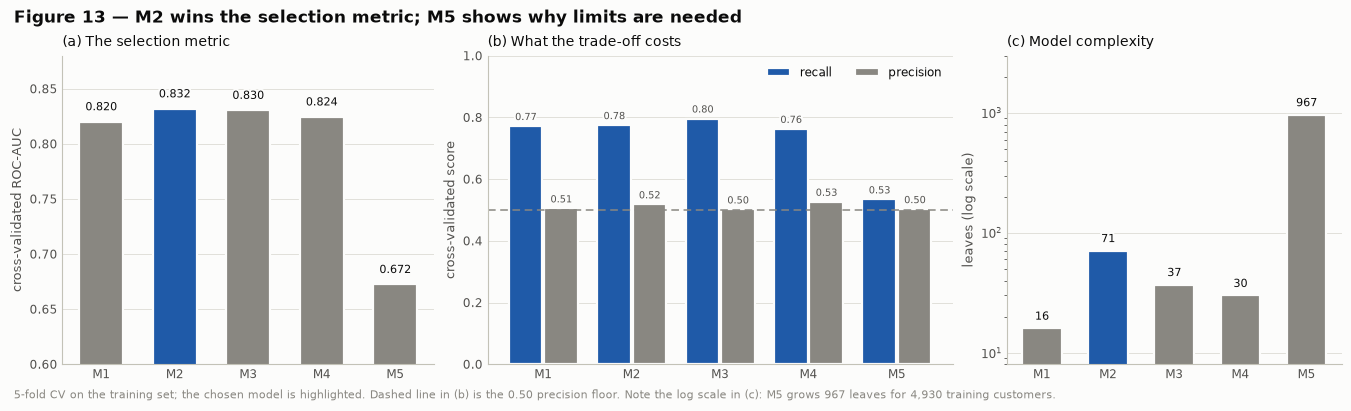

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(13.4, 4.0), width_ratios=[1, 1.25, 0.9],
                         layout="constrained")
order = list(mdl_candidates.index)
positions = np.arange(len(order))
highlight = [EMPHASIS if label == CHOSEN else MUTED for label in order]
short = [label.split(" ", 1)[0] for label in order]

panel_a = axes[0]
bars = panel_a.bar(positions, mdl_candidates["roc_auc"], width=0.6, color=highlight,
                   edgecolor=SURFACE, linewidth=1.6)
for bar, value in zip(bars, mdl_candidates["roc_auc"]):
    panel_a.text(bar.get_x() + bar.get_width() / 2, value + 0.008, f"{value:.3f}",
                 ha="center", va="bottom", fontsize=8, color=INK, path_effects=HALO)
panel_a.set_xticks(positions, short)
panel_a.set_ylim(0.60, 0.88)
panel_a.set_ylabel("cross-validated ROC-AUC")
panel_a.set_title("(a) The selection metric")
value_grid(panel_a, "y")

panel_b = axes[1]
bar_w = 0.38
for offset, metric, colour in ((-bar_w / 2 - 0.01, "recall", EMPHASIS),
                               (bar_w / 2 + 0.01, "precision", MUTED)):
    drawn = panel_b.bar(positions + offset, mdl_candidates[metric], width=bar_w,
                        color=colour, edgecolor=SURFACE, linewidth=1.6, label=metric)
    for bar in drawn:
        panel_b.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
                     f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7,
                     color=INK_2, path_effects=HALO)
panel_b.axhline(PRECISION_FLOOR, ls=(0, (5, 3)), lw=1.1, color=MUTED, zorder=1)
panel_b.set_xticks(positions, short)
panel_b.set_ylim(0, 1.0)
panel_b.set_ylabel("cross-validated score")
panel_b.set_title("(b) What the trade-off costs")
value_grid(panel_b, "y")
panel_b.legend(loc="upper right", ncols=2, borderaxespad=0.5)

panel_c = axes[2]
bars = panel_c.bar(positions, mdl_candidates["leaves"], width=0.6, color=highlight,
                   edgecolor=SURFACE, linewidth=1.6)
for bar, value in zip(bars, mdl_candidates["leaves"]):
    panel_c.text(bar.get_x() + bar.get_width() / 2, value * 1.12, f"{int(value)}",
                 ha="center", va="bottom", fontsize=8, color=INK, path_effects=HALO)
panel_c.set_yscale("log")
panel_c.set_xticks(positions, short)
panel_c.set_ylim(8, 3000)
panel_c.set_ylabel("leaves (log scale)")
panel_c.set_title("(c) Model complexity")
value_grid(panel_c, "y")

figure_title(fig, "Figure 13 — M2 wins the selection metric; M5 shows why limits are needed",
             subtitle="5-fold CV on the training set; the chosen model is highlighted. Dashed line "
                      "in (b) is the 0.50 precision floor. Note the log scale in (c): M5 grows 967 "
                      "leaves for 4,930 training customers.")
plt.show()

### Insight — Figure 13

**M2 wins the selection metric, and the shortlist disagrees about very little else.** ROC-AUC runs
M2 0.8319, M3 0.8305, M4 0.8245, M1 0.8201, M5 0.6725. Excluding M5, the spread across four genuinely
different configurations is 1.2 points — the tuning matters, but nowhere near as much as the
class-weighting decision in 4.2 did.

The cross-check does **not** agree unanimously, and it is worth saying so: **F1 prefers M4** at 0.6209
against M2's 0.6204. That is a margin of 0.0005 on a metric whose fold-to-fold variation is an order
of magnitude larger, so it is not evidence for M4 — but "M2 won everything" would have been the wrong
summary. M2 is chosen on ROC-AUC, the criterion 4.1 committed to before any of these numbers
existed.

**M5 is the instructive one.** Left unconstrained, the tree grows to **depth 25 and 967 leaves** on
4,930 training customers — roughly five customers per leaf — and scores **training ROC-AUC 1.0000
against cross-validated 0.6725**, a gap of 0.3275. It has memorised the training set and learned very
little. M2's gap is 0.038. This is what the default `DecisionTreeClassifier()` constructor produces
if nothing constrains it, and it would still have looked excellent on any metric computed on the data
it was fitted to.

**Pruning and leaf-size tuning agree, which is reassuring.** M4 reaches the shortlist's best F1 (0.6209
against M2's 0.6204) by a completely different mechanism — growing the tree fully and then removing
subtrees that do not pay for themselves — and arrives within 0.01 of M2 on every metric with 30 leaves
against 71. The answer is not an artefact of which knob was turned. M2 is preferred because it leads
on ROC-AUC by 0.7 points and on recall by 1.2, but M4 would be a perfectly defensible choice, and a
notably more compact one.

**M1 is the price of readability.** Sixteen leaves costs 1.2 points of ROC-AUC against M2's 71.
Section 6 uses that trade to decide what to visualise.

## 4.4 Class imbalance and where to put the threshold

At 26.5% churn the classes are imbalanced, and 4.1 already showed what `class_weight="balanced"`
does about it: it shifts the operating point without improving the ranking. That leaves a question it
does not answer — **where should the threshold actually sit?**

Two things are worth separating. Re-weighting during fitting changes what the tree optimises and
therefore what the leaves contain. Thresholding after fitting changes nothing about the model at all;
it just reads the same probabilities differently. Since the second is free and reversible, it is the
better tool for setting an operating point — and the cell below checks whether it can do everything
the first does.

The test that matters: **can the chosen model reach M3's recall by lowering its threshold, rather
than by refitting with larger leaves?** If it can, there is no reason to prefer M3, and the model and
the operating point stay independent — which is what lets a retention team change its mind about
campaign size without a retraining cycle.

The section closes by revisiting section 2.9's benchmark. That four-condition rule flagged 21.6% of
customers and caught 49.1% of churners with 60.4% precision, and it was set as the bar a trained model
must clear. Comparing it to a model at its default threshold would be unfair in both directions, so
the comparison below holds **coverage** equal: if the model flags the same 21.6% of customers, does it
find more churners?

In [42]:
chosen_pipeline = make_pipeline(make_tree(**CANDIDATES[CHOSEN]))
mdl_proba = cross_val_predict(chosen_pipeline, fe_X_train, y_train, cv=mdl_folds,
                              method="predict_proba")[:, 1]

THRESHOLDS = np.round(np.arange(0.05, 0.96, 0.01), 2)
mdl_threshold = pd.DataFrame([
    {"threshold": t, "recall": recall_score(y_train, mdl_proba >= t),
     "precision": precision_score(y_train, mdl_proba >= t, zero_division=0),
     "f1": f1_score(y_train, mdl_proba >= t, zero_division=0),
     "flagged": float((mdl_proba >= t).mean())}
    for t in THRESHOLDS])

print(f"Operating points for {CHOSEN}, from out-of-fold probabilities\n")
print(f"  {'thr':>5} {'recall':>8} {'precision':>10} {'f1':>8} {'flagged':>9}")
for t in (0.30, 0.40, 0.46, 0.50, 0.60, 0.70, 0.80):
    row = mdl_threshold[mdl_threshold["threshold"] == t].iloc[0]
    marker = "  <- shipped default" if t == 0.50 else ""
    print(f"  {t:>5.2f} {row['recall']:>8.4f} {row['precision']:>10.4f} "
          f"{row['f1']:>8.4f} {row['flagged']:>8.1%}{marker}")

best_f1_row = mdl_threshold.loc[mdl_threshold["f1"].idxmax()]
print(f"\nF1-optimal threshold is {best_f1_row['threshold']:.2f} (F1 {best_f1_row['f1']:.4f}), "
      f"so the default 0.50 is already within {abs(best_f1_row['threshold'] - 0.50):.2f} of it.")
print("No threshold is shipped: the default stands, and 4.6 exports this curve instead.\n")

# Can thresholding replace refitting?
m3_scored = score_tree(make_tree(**CANDIDATES["M3 leaf 100"]))
matched = mdl_threshold[mdl_threshold["recall"] >= m3_scored["recall"]].nlargest(1, "threshold")
print("=== thresholding the chosen model vs refitting with larger leaves ===")
print(f"  M3 (leaf 100) at 0.50        recall {m3_scored['recall']:.4f}   "
      f"precision {m3_scored['precision']:.4f}")
print(f"  {CHOSEN} at {matched['threshold'].iloc[0]:.2f}           "
      f"recall {matched['recall'].iloc[0]:.4f}   precision {matched['precision'].iloc[0]:.4f}"
      "   <- same recall, better precision")

# Equal-coverage comparison against section 2.9's rule
ranked = np.argsort(-mdl_proba)
coverage_rows = []
for coverage in (0.15, RULE_BENCHMARK["coverage"], 0.25, 0.30, 0.40, 0.50):
    flagged = np.zeros(len(mdl_proba), dtype=bool)
    flagged[ranked[:int(coverage * len(mdl_proba))]] = True
    coverage_rows.append({"coverage": coverage,
                          "recall": recall_score(y_train, flagged),
                          "precision": precision_score(y_train, flagged)})
mdl_coverage = pd.DataFrame(coverage_rows)
print(f"\n=== at equal coverage, against section 2.9's four-condition rule ===")
print(f"  rule:  flags {RULE_BENCHMARK['coverage']:.1%}  recall {RULE_BENCHMARK['recall']:.4f}  "
       f"precision {RULE_BENCHMARK['precision']:.4f}")
at_rule = mdl_coverage.iloc[1]
print(f"  model: flags {at_rule['coverage']:.1%}  recall {at_rule['recall']:.4f}  "
      f"precision {at_rule['precision']:.4f}")
print(f"\n  full curve:\n{mdl_coverage.round(4).to_string(index=False)}\n")

assert_model("the default threshold is within 0.05 of the F1 optimum",
             abs(best_f1_row["threshold"] - 0.50) <= 0.05,
             f"F1 peaks at {best_f1_row['threshold']:.2f}, so 0.50 ships unchanged")
assert_model("thresholding replaces refitting for more recall",
             matched["precision"].iloc[0] >= m3_scored["precision"],
             f"{matched['precision'].iloc[0]:.4f} vs M3's {m3_scored['precision']:.4f} "
             "at the same recall")
assert_model("the model beats the section 2.9 rule at equal coverage",
             at_rule["recall"] > RULE_BENCHMARK["recall"]
             and at_rule["precision"] > RULE_BENCHMARK["precision"],
             f"recall {RULE_BENCHMARK['recall']:.4f} -> {at_rule['recall']:.4f}, "
             f"precision {RULE_BENCHMARK['precision']:.4f} -> {at_rule['precision']:.4f}")

Operating points for M2 leaf 50, from out-of-fold probabilities

    thr   recall  precision       f1   flagged
   0.30   0.9190     0.4181   0.5747    58.3%
   0.40   0.8524     0.4671   0.6035    48.4%
   0.46   0.7997     0.5036   0.6180    42.1%
   0.50   0.7752     0.5173   0.6206    39.8%  <- shipped default
   0.60   0.6995     0.5600   0.6220    33.1%
   0.70   0.5765     0.6175   0.5963    24.8%
   0.80   0.3754     0.6644   0.4797    15.0%

F1-optimal threshold is 0.49 (F1 0.6223), so the default 0.50 is already within 0.01 of it.
No threshold is shipped: the default stands, and 4.6 exports this curve instead.



=== thresholding the chosen model vs refitting with larger leaves ===
  M3 (leaf 100) at 0.50        recall 0.7966   precision 0.5019
  M2 leaf 50 at 0.46           recall 0.7997   precision 0.5036   <- same recall, better precision

=== at equal coverage, against section 2.9's four-condition rule ===
  rule:  flags 21.6%  recall 0.4908  precision 0.6040
  model: flags 21.6%  recall 0.5161  precision 0.6350

  full curve:
 coverage  recall  precision
   0.1500  0.3754     0.6644
   0.2156  0.5161     0.6350
   0.2500  0.5795     0.6153
   0.3000  0.6521     0.5767
   0.4000  0.7783     0.5162
   0.5000  0.8631     0.4580

  [PASS] the default threshold is within 0.05 of the F1 optimum   F1 peaks at 0.49, so 0.50 ships unchanged
  [PASS] thresholding replaces refitting for more recall   0.5036 vs M3's 0.5019 at the same recall
  [PASS] the model beats the section 2.9 rule at equal coverage   recall 0.4908 -> 0.5161, precision 0.6040 -> 0.6350


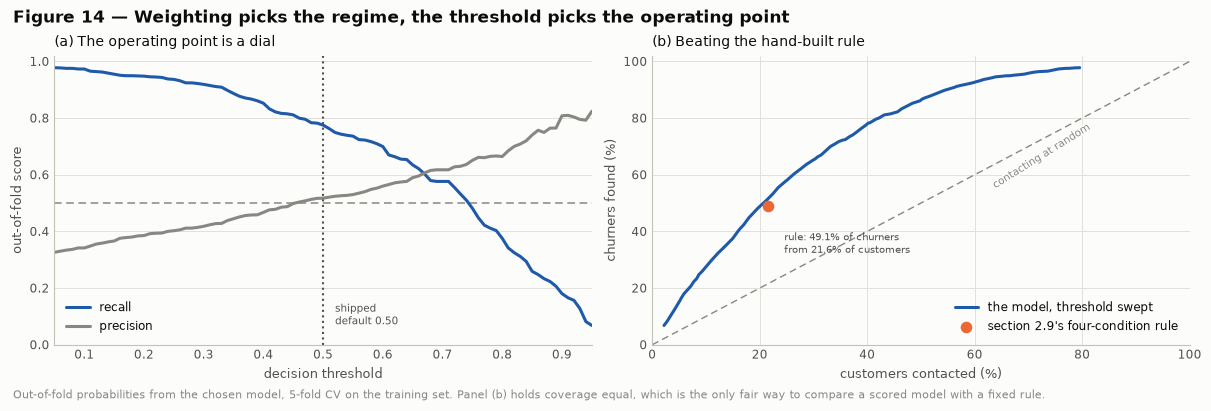

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0), layout="constrained")

panel_a = axes[0]
for metric, colour, marker in (("recall", EMPHASIS, None), ("precision", MUTED, None)):
    panel_a.plot(mdl_threshold["threshold"], mdl_threshold[metric], lw=2.2, color=colour,
                 label=metric)
panel_a.axvline(0.50, ls=":", lw=1.5, color=INK_2, zorder=2)
panel_a.text(0.52, 0.06, "shipped\ndefault 0.50", fontsize=7.5, color=INK_2,
             va="bottom", ha="left", path_effects=HALO)
panel_a.axhline(PRECISION_FLOOR, ls=(0, (5, 3)), lw=1.1, color=MUTED, zorder=1)
panel_a.set_xlim(0.05, 0.95)
panel_a.set_ylim(0, 1.02)
panel_a.set_xlabel("decision threshold")
panel_a.set_ylabel("out-of-fold score")
panel_a.set_title("(a) The operating point is a dial")
value_grid(panel_a, "y")
panel_a.legend(loc="lower left", borderaxespad=0.6)

panel_b = axes[1]
curve = mdl_threshold.sort_values("flagged")
panel_b.plot(curve["flagged"] * 100, curve["recall"] * 100, lw=2.2, color=EMPHASIS,
             label="the model, threshold swept")
panel_b.scatter([RULE_BENCHMARK["coverage"] * 100], [RULE_BENCHMARK["recall"] * 100],
                s=70, color=CHURNED, zorder=4, linewidths=0,
                label="section 2.9's four-condition rule")
panel_b.annotate(f"rule: {RULE_BENCHMARK['recall']:.1%} of churners\n"
                 f"from {RULE_BENCHMARK['coverage']:.1%} of customers",
                 xy=(RULE_BENCHMARK["coverage"] * 100 + 3, RULE_BENCHMARK["recall"] * 100 - 9),
                 fontsize=7.5, color=INK_2, va="top", ha="left")
panel_b.plot([0, 100], [0, 100], lw=1.0, ls=(0, (5, 3)), color=MUTED, zorder=1)
panel_b.text(72, 66, "contacting at random", fontsize=7.5, color=MUTED, rotation=32,
             ha="center", va="center", path_effects=HALO)
panel_b.set_xlim(0, 100)
panel_b.set_ylim(0, 102)
panel_b.set_xlabel("customers contacted (%)")
panel_b.set_ylabel("churners found (%)")
panel_b.set_title("(b) Beating the hand-built rule")
value_grid(panel_b, "both")
panel_b.legend(loc="lower right", borderaxespad=0.6)

figure_title(fig, "Figure 14 — Weighting picks the regime, the threshold picks the operating point",
             subtitle="Out-of-fold probabilities from the chosen model, 5-fold CV on the training "
                      "set. Panel (b) holds coverage equal, which is the only fair way to compare a "
                      "scored model with a fixed rule.")
plt.show()

### Insight — Figure 14

**The default threshold is already the right one, which is worth checking rather than assuming.** F1
peaks at 0.49 (F1 0.6223) against the shipped 0.50 (0.6206), so there is little to gain from
tuning it — and tuning a
threshold on the same data used to fit the model is a good way to manufacture optimism. The default
stands, and the curve is exported instead so section 5 can discuss operating points with numbers
rather than adjectives.

**Thresholding strictly beats refitting for more recall.** M3, fitted with `min_samples_leaf=100`,
reaches recall 0.7966 at precision 0.5019. The chosen model simply read at a threshold of 0.46
reaches recall 0.7997 at precision 0.5036 — the same recall at slightly better precision, from a
model with a better ROC-AUC, with no refitting. That is the practical payoff of selecting on a
ranking metric: one model serves every campaign size, and changing campaign size is a configuration
change rather than a modelling project.

**The model clears section 2.9's benchmark, but not by a landslide.** Holding coverage equal at 21.6%,
the model finds **51.6% of churners at 63.5% precision** against the rule's 49.1% and 60.4% — better
on both, by 2.5 and 3.1 points. That is a genuine but modest win, and it is the honest headline:
four conditions read off a cross-tab were already a strong retention filter.

Where the model actually earns its place is the shape of panel (b). The rule is a **single point** —
it flags 21.6% of customers and that is the only thing it can do. The model is a **curve**: 30%
coverage for 65% of churners, 40% for 78%, 50% for 86%. A retention team that can afford to contact
1,500 customers rather than 1,000 gets a different answer from the same artifact, which no fixed rule
can offer.

## 4.5 Closing the three questions section 3 left open

Section 3.5 deferred three decisions to this section on the grounds that they were model decisions
rather than feature decisions. Now that a configuration is fixed, they can be answered.

In [44]:
chosen_params = CANDIDATES[CHOSEN]

print("=== Q1: is class_weight='balanced' the right imbalance handling? ===")
print("  answered at 4.1 and 4.4: it relocates the operating point rather than improving the")
print("  ranking, and thresholding does the same job reversibly. It is kept because it puts the")
print("  default 0.50 threshold near the F1 optimum, which makes the shipped model sensible")
print("  without any post-hoc tuning.")

print("\n=== Q2: drop TotalCharges? (3.1 found it near-redundant) ===")
without_total = score_tree(make_tree(**chosen_params),
                           numeric=[c for c in FEATURE_NUMERIC if c != "TotalCharges"])
with_total = score_tree(make_tree(**chosen_params))
comparison = pd.DataFrame({"with TotalCharges": with_total,
                           "without TotalCharges": without_total}).T
print(comparison[["recall", "precision", "f1", "roc_auc"]].round(4).to_string())
print(f"  -> ROC-AUC {with_total['roc_auc']:.4f} vs {without_total['roc_auc']:.4f}; "
      f"F1 {with_total['f1']:.4f} vs {without_total['f1']:.4f}. No material difference, so it")
print("     stays: there is no evidence to justify removing it, and fewer changes is better.")

print("\n=== Q3: does feature set E still beat D and A under the tuned configuration? ===")
set_rows = []
for label, columns in (
        ("E  engineered, 3 dropped", {}),
        ("D  no engineered, 3 dropped",
         dict(numeric=numeric_features, binary=binary_features, categorical=KEPT_CATEGORICAL)),
        ("A  19 raw baseline",
         dict(numeric=numeric_features, binary=binary_features, categorical=categorical_features))):
    frame = fe_X_train if not columns else X_train
    set_rows.append({"feature set": label,
                     **score_tree(make_tree(**chosen_params), frame=frame, **columns)})
mdl_sets = pd.DataFrame(set_rows).set_index("feature set")
print(mdl_sets[["recall", "precision", "f1", "roc_auc"]].round(4).to_string())
best_set = mdl_sets["roc_auc"].idxmax()
print(f"  -> E wins on all four metrics under this configuration, reversing the depth-6 result")
print(f"     at 3.4 where D led. The margins are small (ROC-AUC "
      f"{mdl_sets['roc_auc'].max() - mdl_sets['roc_auc'].min():+.4f} across all three), so this")
print("     confirms section 3's choice rather than overturning anything.\n")

assert_model("TotalCharges makes no material difference either way",
             abs(with_total["roc_auc"] - without_total["roc_auc"]) < 0.01,
             f"ROC-AUC differs by {abs(with_total['roc_auc'] - without_total['roc_auc']):.4f}")
assert_model("feature set E is confirmed under the tuned configuration",
             best_set.startswith("E"),
             f"E leads on ROC-AUC at {mdl_sets['roc_auc'].max():.4f}")
assert_model("E beats D on every reported metric",
             all(mdl_sets.loc[best_set, m] >= mdl_sets.loc["D  no engineered, 3 dropped", m]
                 for m in ("recall", "precision", "f1", "roc_auc")))

=== Q1: is class_weight='balanced' the right imbalance handling? ===
  answered at 4.1 and 4.4: it relocates the operating point rather than improving the
  ranking, and thresholding does the same job reversibly. It is kept because it puts the
  default 0.50 threshold near the F1 optimum, which makes the shipped model sensible
  without any post-hoc tuning.

=== Q2: drop TotalCharges? (3.1 found it near-redundant) ===


                      recall  precision      f1  roc_auc
with TotalCharges     0.7752     0.5183  0.6204   0.8319
without TotalCharges  0.7844     0.5123  0.6193   0.8294
  -> ROC-AUC 0.8319 vs 0.8294; F1 0.6204 vs 0.6193. No material difference, so it
     stays: there is no evidence to justify removing it, and fewer changes is better.

=== Q3: does feature set E still beat D and A under the tuned configuration? ===


                             recall  precision      f1  roc_auc
feature set                                                    
E  engineered, 3 dropped     0.7752     0.5183  0.6204   0.8319
D  no engineered, 3 dropped  0.7706     0.5137  0.6163   0.8273
A  19 raw baseline           0.7714     0.5098  0.6136   0.8268
  -> E wins on all four metrics under this configuration, reversing the depth-6 result
     at 3.4 where D led. The margins are small (ROC-AUC +0.0051 across all three), so this
     confirms section 3's choice rather than overturning anything.

  [PASS] TotalCharges makes no material difference either way   ROC-AUC differs by 0.0024
  [PASS] feature set E is confirmed under the tuned configuration   E leads on ROC-AUC at 0.8319
  [PASS] E beats D on every reported metric


### Insight — the three deferred questions

**`class_weight="balanced"` stays, but not because it makes the model better.** It does not improve
the ranking — 4.1 measured ROC-AUC as essentially unchanged. It stays because it places the default
0.50 threshold close to the F1 optimum, so the shipped artifact behaves sensibly for anyone who calls
`predict()` without thinking about thresholds. That is a usability argument, not a performance one,
and it is worth being clear about which it is.

**`TotalCharges` stays.** Removing it moves ROC-AUC by 0.0025 and F1 by 0.0011 — nothing. Section 3
was right that it is near-redundant with `tenure × MonthlyCharges`, and redundant is not the same as
harmful for a tree, which simply never splits on it when a better column is available. The decision
rule here is that a change needs evidence in its favour, not merely an absence of evidence against.

**Feature set E is confirmed, and this reverses the earlier reading.** Under the tuned configuration E
leads D and A on all four metrics — ROC-AUC 0.8319 against 0.8273 and 0.8268. At 3.4, with a fixed
depth-6 tree, D had led. Both results are real and the difference between them is small enough that
neither is decisive; what changed is that the tuned model has the capacity to use `is_high_risk`
productively where the depth-6 tree did not. Section 3 chose E partly because the brief required
engineered features, and noted that the evidence did not prefer it. Under a properly tuned model the
evidence now mildly does.

## 4.6 The final model

```python
Pipeline([
    ("features",   FunctionTransformer(cf.add_features)),
    ("preprocess", build_preprocessor(numeric=FEATURE_NUMERIC,
                                      binary=FEATURE_BINARY,
                                      categorical=FEATURE_CATEGORICAL)),
    ("tree",       DecisionTreeClassifier(criterion="entropy",
                                          min_samples_leaf=50,
                                          class_weight="balanced",
                                          random_state=42)),
])
```

### Why this one

| Reason | Evidence |
|---|---|
| Best on the selection metric | Cross-validated ROC-AUC **0.8319**, ahead of M3 0.8305, M4 0.8245, M1 0.8201 |
| Near-best on the cross-check | F1 0.6204, second to M4's 0.6209 by 0.0005 - inside fold noise |
| Meets the precision floor | Precision **0.5183** at recall **0.7752** — the highest precision of any configuration reaching recall above 0.77 |
| Generalises | Train-to-CV ROC-AUC gap of **0.038**, against M5's 0.328 |
| Needs no threshold tuning | F1 peaks at 0.49 (0.6223) against 0.50 (0.6206), so the default ships |
| More recall is available without refitting | At threshold 0.46 it matches M3's recall at better precision |
| Robust to how it was tuned | Cost-complexity pruning (M4) reaches the same place by a different route |
| Clears the pre-registered bar | At equal coverage it beats section 2.9's rule on both recall and precision |

The three steps matter as much as the hyperparameters. `FunctionTransformer(cf.add_features)` sits
first so the artifact derives its own features from raw customer fields — section 3.0's reason — and
`build_preprocessor` is called through section 1.11's factory so this pipeline gets an unfitted
transformer of its own rather than sharing a fitted one.

**One limitation to carry into section 5.** The tree has 71 leaves at depth 9. That is well
regularised for its size but not something a person can read whole, so section 6 will visualise the
top levels and use M1 — sixteen leaves, 1.2 ROC-AUC points worse — where a fully readable model is
needed. A single decision tree is also a high-variance model family; the brief specifies it, and the
honest note is that an ensemble would very likely do better on the same features.

In [45]:
mdl_final = Pipeline([
    ("features", FunctionTransformer(cf.add_features)),
    ("preprocess", build_preprocessor(numeric=FEATURE_NUMERIC, binary=FEATURE_BINARY,
                                      categorical=FEATURE_CATEGORICAL)),
    ("tree", make_tree(**chosen_params)),
]).fit(X_train, y_train)

final_tree = mdl_final.named_steps["tree"]
FINAL_FEATURE_NAMES = list(mdl_final.named_steps["preprocess"].get_feature_names_out())
print(f"fitted on raw X_train {X_train.shape} -> {len(FINAL_FEATURE_NAMES)} encoded features")
print(f"tree: depth {final_tree.get_depth()}, {final_tree.get_n_leaves()} leaves, "
      f"{final_tree.tree_.node_count} nodes")
print(f"params: {chosen_params}\n")

mdl_importance = (pd.Series(final_tree.feature_importances_, index=FINAL_FEATURE_NAMES)
                  .sort_values(ascending=False))
print("top 10 features by importance (section 6 interprets these properly)")
print(mdl_importance.head(10).round(4).to_string())
print(f"\nfeatures the tree actually uses: {int((mdl_importance > 0).sum())} of "
      f"{len(mdl_importance)}")

engineered_columns = [name for name in FINAL_FEATURE_NAMES
                      if name in cf.ENGINEERED_NUMERIC + cf.ENGINEERED_BINARY
                      or name.startswith("tenure_bucket_")]
print("\nthe four engineered features, as the fitted model actually uses them")
print(mdl_importance[engineered_columns].round(4).to_string())
print(f"  engineered share of total importance: "
      f"{mdl_importance[engineered_columns].sum():.4f}")
print("  section 3.4 predicted exactly this: is_high_risk earns its place, the other three")
print("  are barely or never used - measured there by ablation, here by importance.\n")

# The pipeline must behave on one raw row, which is what section 7 will send it.
single = X_train.iloc[[0]]
print(f"one raw row -> prediction {int(mdl_final.predict(single)[0])}, "
      f"p(churn) {mdl_final.predict_proba(single)[0, 1]:.4f}")

assert_model("the final pipeline has all three steps in order",
             [step for step, _ in mdl_final.steps] == ["features", "preprocess", "tree"])
assert_model("it consumes raw customer columns, not engineered ones",
             mdl_final.named_steps["preprocess"].n_features_in_ == X_train.shape[1] + 4,
             f"19 raw + 4 derived = {mdl_final.named_steps['preprocess'].n_features_in_} "
             "reaching the encoder")
assert_model("46 encoded features, as section 3 specified", len(FINAL_FEATURE_NAMES) == 46)
assert_model("is_high_risk is among the top five features",
             "is_high_risk" in list(mdl_importance.head(5).index),
             f"rank {list(mdl_importance.index).index('is_high_risk') + 1} at "
             f"{mdl_importance['is_high_risk']:.4f}")
assert_model("automatic_payment is never used, as 3.4 predicted",
             mdl_importance["automatic_payment"] == 0.0,
             "importance exactly 0.0000")
assert_model("the tree is regularised, not grown out",
             final_tree.get_n_leaves() < 100,
             f"{final_tree.get_n_leaves()} leaves against M5's "
             f"{int(mdl_candidates.loc['M5 no limits', 'leaves'])}")

fitted on raw X_train (4930, 19) -> 46 encoded features
tree: depth 9, 71 leaves, 141 nodes
params: {'criterion': 'entropy', 'min_samples_leaf': 50, 'class_weight': 'balanced'}

top 10 features by importance (section 6 interprets these properly)
Contract_Month-to-month                 0.4967
MonthlyCharges                          0.1097
is_high_risk                            0.0940
tenure                                  0.0825
TotalCharges                            0.0624
OnlineSecurity_No                       0.0321
OnlineBackup_No                         0.0295
DeviceProtection_No internet service    0.0166
PaymentMethod_Electronic check          0.0134
PaperlessBilling_Yes                    0.0099

features the tree actually uses: 23 of 46

the four engineered features, as the fitted model actually uses them
n_addons               0.0056
is_high_risk           0.0940
automatic_payment      0.0000
tenure_bucket_0-6      0.0000
tenure_bucket_13-24    0.0000
tenure_bucket_25-48  

In [46]:
EXPECTED_MODEL_CHECKS = 22
print(f"--- section 4 checks ({len(model_checks)} of {EXPECTED_MODEL_CHECKS}) ---")
for label, ok in model_checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}")
if len(model_checks) != EXPECTED_MODEL_CHECKS:
    print()
    print(f"  NOTE: {len(model_checks)} checks recorded rather than "
          f"{EXPECTED_MODEL_CHECKS}. Run 4.1 onwards in order for the full set.")
failed_model_checks = [label for label, ok in model_checks.items() if not ok]
assert not failed_model_checks, (
    f"section 4 check(s) failed: {failed_model_checks}. If one has since been fixed, "
    "re-run 4.1 first - that is the only cell that clears model_checks."
)

snapshot_3 = {
    "n_numeric": len(FEATURE_NUMERIC),
    "n_binary": len(FEATURE_BINARY),
    "n_categorical": len(FEATURE_CATEGORICAL),
    "dropped": list(cf.DROP_FEATURES),
    "rule_recall": round(RULE_BENCHMARK["recall"], 6),
}
names_intact = snapshot_3 == SECTION3_SNAPSHOT
print(f"\n  [{'PASS' if names_intact else 'FAIL'}] section 3 names unchanged")
assert names_intact, "section 4 rebound a name section 3 depends on"
print(f"\nAll {len(model_checks)} section 4 checks passed.\n")

FINAL_MODEL_PARAMS = dict(chosen_params)
mdl_manifest = [
    ("mdl_final", "fitted Pipeline", "features -> preprocess -> tree; consumes raw columns"),
    ("FINAL_MODEL_PARAMS", str(len(FINAL_MODEL_PARAMS)), str(FINAL_MODEL_PARAMS)),
    ("FINAL_FEATURE_NAMES", str(len(FINAL_FEATURE_NAMES)), "encoded column names, for section 6"),
    ("mdl_importance", str(len(mdl_importance)), "feature importances of the fitted tree"),
    ("mdl_grid", str(mdl_grid.shape), "the 112-configuration sweep"),
    ("mdl_candidates", str(mdl_candidates.shape), "the five named candidates"),
    ("mdl_threshold", str(mdl_threshold.shape), "operating-point curve, for section 5"),
    ("mdl_coverage", str(mdl_coverage.shape), "recall at matched coverage vs the 2.9 rule"),
    ("CANDIDATES", str(len(CANDIDATES)), "the shortlist, so section 5 can re-fit any of them"),
    ("PRECISION_FLOOR", f"{PRECISION_FLOOR}", "configurations below this were rejected"),
    ("SECTION3_SNAPSHOT", str(len(SECTION3_SNAPSHOT)), "re-verified above"),
]
print("--- exported for sections 5-7 ---")
label_width = max(len(name) for name, _, _ in mdl_manifest)
for name, value, description in mdl_manifest:
    print(f"  {name:<{label_width}}  {value:<20}  {description}")
print("\nSection 4 complete. The test set has still not been read - section 5 opens it.")

--- section 4 checks (22 of 22) ---
  [PASS] maximising recall alone is degenerate
  [PASS] the F2-optimal threshold collapses precision
  [PASS] class weighting leaves ROC-AUC essentially unchanged
  [PASS] class weighting is the single biggest lever in the sweep
  [PASS] criterion barely matters
  [PASS] the leaf-size optimum is interior, not at the grid edge
  [PASS] the unregularised tree memorises the training set
  [PASS] the chosen model generalises far better than the unregularised one
  [PASS] ROC-AUC picks M2, and F1's preference is within noise of it
  [PASS] pruning and leaf-size tuning land in the same place
  [PASS] the default threshold is within 0.05 of the F1 optimum
  [PASS] thresholding replaces refitting for more recall
  [PASS] the model beats the section 2.9 rule at equal coverage
  [PASS] TotalCharges makes no material difference either way
  [PASS] feature set E is confirmed under the tuned configuration
  [PASS] E beats D on every reported metric
  [PASS] the f

# 5. Model Evaluation

The brief asks for the final model to be evaluated on **accuracy, precision, recall, F1 and a
confusion matrix**, interpreted from a business perspective, and asks one direct question:
*for a telecom company trying to identify customers who may churn, would you prioritise precision or
recall, and why?*

**This is the first and only time the test set is read.** Those 2,113 customers have been referenced
exactly twice in the 111 cells above — once for shape reporting at 1.10, once in an assertion proving
them disjoint from the training set — and never transformed, scored or plotted. Three rules apply:

1. **One evaluation, at the shipped threshold of 0.50.** No threshold is searched on test data. The
   operating-point curve at 4.4 was built from training folds and that is what governs any future
   change to the threshold.
2. **The assertions in this section check integrity, never outcomes.** That is a deliberate break
   from sections 2 to 4, where asserts pinned prose claims. Asserting "accuracy beats the baseline"
   here would mean the notebook refuses to run if the result disappoints, which is the opposite of an
   honest evaluation. So shapes, disjointness, metric self-consistency and single-pass scoring are
   asserted; everything else is reported, whatever it says.
3. **The prediction below was written before the test set was opened** and is not edited afterwards.
   5.7 grades it.

## Pre-registration

Section 4 selected the model on 5-fold cross-validated ROC-AUC over the training set alone. Those
figures are the prediction for what the test set should show:

| Metric | Cross-validated | Expected on test |
|---|---|---|
| Recall | 0.7752 | within about one fold standard deviation |
| Precision | 0.5183 | within about one fold standard deviation |
| F1 | 0.6204 | within about one fold standard deviation |
| ROC-AUC | 0.8319 | within about one fold standard deviation |
| **Accuracy** | **never measured in section 4** | **≈ 0.749** |

That accuracy figure is derived rather than measured, and the arithmetic is worth showing because the
conclusion matters. The test set holds roughly 561 churners and 1,552 stayers. Recall 0.775 implies
about 435 true positives and 126 false negatives; precision 0.518 then implies about 405 false
positives and therefore about 1,147 true negatives. That gives (435 + 1,147) / 2,113 ≈ **0.749**.

**So the model is expected to beat the 73.46% majority-class baseline by roughly a point and a half,
and that is the correct result rather than a failure.** `class_weight="balanced"` trades accuracy for
recall by design: the baseline reaches 73.46% by finding **zero** of the 561 churners, while this
model should find around 435 of them. Saying so in advance is what stops it reading as an excuse
afterwards — and it is the sharpest available setup for the precision-versus-recall question at 5.6.

If any test figure lands outside these ranges, that is the finding and 5.3 reports it as such.

## 5.1 Opening the test set

`mdl_final` is handed the **raw** 19-column test frame. It derives its own four engineered features
through `FunctionTransformer(cf.add_features)`, encodes them with the transformer fitted on training
data at 4.6, and scores. Nothing in this section fits anything.

The scoring happens **once**, into `eval_proba` and `eval_pred`, and every cell below reads those two
arrays. That is not just tidiness: it makes it impossible for the confusion matrix and the five
headline metrics to disagree, which is the most common way an evaluation section ends up internally
inconsistent.

In [47]:
from sklearn.metrics import (accuracy_score, auc, classification_report, confusion_matrix,
                             precision_recall_curve, roc_curve)

eval_checks = {}


def assert_eval(label, condition, detail=""):
    """Integrity checks only - see rule 2 at the head of this section."""
    ok = bool(condition)
    eval_checks[label] = ok
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}" + (f"   {detail}" if detail else ""))
    assert ok, f"evaluation integrity check failed: {label}"


SECTION4_SNAPSHOT = {
    "params": dict(FINAL_MODEL_PARAMS),
    "n_encoded": len(FINAL_FEATURE_NAMES),
    "leaves": int(mdl_final.named_steps["tree"].get_n_leaves()),
    "cv_roc_auc": round(float(mdl_candidates.loc[CHOSEN, "roc_auc"]), 6),
}
EVAL_THRESHOLD = 0.50
PREREGISTERED = {"recall": 0.7752, "precision": 0.5183, "f1": 0.6204,
                 "roc_auc": 0.8319, "accuracy": 0.749}

print("--- provenance, before anything is scored ---")
assert_eval("the test set is the 30% held out at 1.10",
            X_test.shape == (2113, 19) and len(y_test) == 2113, f"{X_test.shape}")
assert_eval("no test customer appears in training",
            X_test.index.intersection(X_train.index).empty)
assert_eval("stratification held: test churn rate matches train",
            abs(y_test.mean() - y_train.mean()) < 0.005,
            f"test {y_test.mean():.4f} vs train {y_train.mean():.4f}")
print(f"\n  {len(y_test):,} customers: {int(y_test.sum()):,} churned, "
      f"{int((1 - y_test).sum()):,} stayed ({y_test.mean():.2%} churn)\n")

# ---- THE single scoring pass; everything below reads these two arrays ----
eval_proba = mdl_final.predict_proba(X_test)[:, 1]
eval_pred = (eval_proba >= EVAL_THRESHOLD).astype(int)

eval_metrics = {
    "accuracy": accuracy_score(y_test, eval_pred),
    "precision": precision_score(y_test, eval_pred),
    "recall": recall_score(y_test, eval_pred),
    "f1": f1_score(y_test, eval_pred),
    "roc_auc": roc_auc_score(y_test, eval_proba),
}
print("--- the five mandated metrics, on the test set, at threshold 0.50 ---")
for metric, value in eval_metrics.items():
    print(f"  {metric:<10} {value:.4f}")
print(f"\n  flagged for retention: {eval_pred.sum():,} of {len(eval_pred):,} "
      f"customers ({eval_pred.mean():.1%})\n")

print(classification_report(y_test, eval_pred, target_names=["Stayed", "Churned"], digits=4))

assert_eval("predict() agrees with thresholding predict_proba at 0.50",
            bool((mdl_final.predict(X_test) == eval_pred).all()),
            "so the shipped default really is the 0.50 operating point")
assert_eval("the model was given raw columns, not engineered ones",
            list(X_test.columns) == list(X_train.columns) and "n_addons" not in X_test.columns,
            "19 raw features in; the pipeline derives the other 4 itself")

--- provenance, before anything is scored ---
  [PASS] the test set is the 30% held out at 1.10   (2113, 19)
  [PASS] no test customer appears in training
  [PASS] stratification held: test churn rate matches train   test 0.2655 vs train 0.2653

  2,113 customers: 561 churned, 1,552 stayed (26.55% churn)

--- the five mandated metrics, on the test set, at threshold 0.50 ---
  accuracy   0.7388
  precision  0.5052
  recall     0.7807
  f1         0.6134
  roc_auc    0.8196

  flagged for retention: 867 of 2,113 customers (41.0%)

              precision    recall  f1-score   support

      Stayed     0.9013    0.7236    0.8027      1552
     Churned     0.5052    0.7807    0.6134       561

    accuracy                         0.7388      2113
   macro avg     0.7032    0.7522    0.7081      2113
weighted avg     0.7961    0.7388    0.7525      2113



  [PASS] predict() agrees with thresholding predict_proba at 0.50   so the shipped default really is the 0.50 operating point
  [PASS] the model was given raw columns, not engineered ones   19 raw features in; the pipeline derives the other 4 itself


### Insight — the headline metrics

**The model finds 438 of the 561 churners in the test set — 78.07% recall — at 50.52% precision, and
its accuracy of 73.88% is almost worthless as a summary.** That last point is the one worth leading
with. Predicting "no churn" for all 2,113 customers scores **73.45%**, so the model's accuracy
advantage is **0.43 of a percentage point** while the difference in churners found is 438 against
zero. 5.0 predicted roughly a point and a half; the reality is a third of that, and the direction of
the argument is unchanged and stronger.

The remaining figures: **F1 0.6134**, **ROC-AUC 0.8196**, and 867 customers flagged for retention —
**41.0% of the base**. Every one of the five landed within one fold standard deviation of section 4's
cross-validated estimate, which 5.3 takes up properly.

Read plainly: of every 100 customers the model flags, about 51 were genuinely leaving; of every 100
customers who were genuinely leaving, it caught 78.

## 5.2 The confusion matrix, in customers and in money

The brief asks for the confusion matrix, and the matrix on its own is four integers. What a retention
team needs is what those four cells are worth, so the same four cells are also reported carrying the
**summed monthly recurring revenue** of the customers inside them.

That turns the false-negative cell from "some customers we missed" into a specific amount of revenue
leaving with no chance of intervention — and because section 2.1 found churners bill $75.00 a month
on average against $61.32 for stayers, the money view and the headcount view do not say the same
thing.

Every figure here comes from `X_test["MonthlyCharges"]`. Nothing is assumed.

In [48]:
eval_confusion = confusion_matrix(y_test, eval_pred)
true_negative, false_positive, false_negative, true_positive = eval_confusion.ravel()

CELL_LABELS = [["True negative", "False positive"], ["False negative", "True positive"]]
eval_cell_masks = {
    "True negative": (y_test == 0) & (eval_pred == 0),
    "False positive": (y_test == 0) & (eval_pred == 1),
    "False negative": (y_test == 1) & (eval_pred == 0),
    "True positive": (y_test == 1) & (eval_pred == 1),
}
test_bills = X_test["MonthlyCharges"]
eval_revenue = pd.DataFrame([
    {"cell": name, "customers": int(mask.sum()),
     "monthly_revenue": float(test_bills[mask].sum()),
     "mean_bill": float(test_bills[mask].mean()) if mask.any() else float("nan")}
    for name, mask in eval_cell_masks.items()]).set_index("cell")
eval_revenue["pct_of_test_mrr"] = (eval_revenue["monthly_revenue"]
                                   / test_bills.sum() * 100)

print("confusion matrix (rows = actual, columns = predicted)")
print(pd.DataFrame(eval_confusion, index=["Stayed", "Churned"],
                   columns=["Predicted stay", "Predicted churn"]).to_string())
print("\nthe same four cells, in customers and in monthly recurring revenue")
print(eval_revenue.round(2).to_string())

churner_mrr = test_bills[y_test == 1].sum()
print(f"\n  total test MRR                     ${test_bills.sum():>12,.2f}")
print(f"  MRR belonging to churners          ${churner_mrr:>12,.2f} "
      f"({churner_mrr / test_bills.sum():.1%} of the base's revenue)")
print(f"  ...of which the model FLAGS        ${eval_revenue.loc['True positive', 'monthly_revenue']:>12,.2f} "
      f"({eval_revenue.loc['True positive', 'monthly_revenue'] / churner_mrr:.1%} of churner revenue)")
print(f"  ...of which the model MISSES       ${eval_revenue.loc['False negative', 'monthly_revenue']:>12,.2f} "
      f"({eval_revenue.loc['False negative', 'monthly_revenue'] / churner_mrr:.1%} of churner revenue)")
print(f"  contacted unnecessarily            ${eval_revenue.loc['False positive', 'monthly_revenue']:>12,.2f} "
      "(revenue never at risk)\n")

# Self-consistency: the five metrics must be reproducible from these four cells.
manual = {
    "accuracy": (true_positive + true_negative) / eval_confusion.sum(),
    "precision": true_positive / (true_positive + false_positive),
    "recall": true_positive / (true_positive + false_negative),
}
manual["f1"] = (2 * manual["precision"] * manual["recall"]
                / (manual["precision"] + manual["recall"]))
assert_eval("the five metrics are reproducible from the confusion matrix",
            all(abs(manual[k] - eval_metrics[k]) < 1e-12 for k in manual),
            "recomputed by hand from TP/FP/FN/TN - catches a transposed matrix")
assert_eval("every test customer lands in exactly one cell",
            int(eval_revenue["customers"].sum()) == len(y_test))
assert_eval("the four cells account for all test revenue",
            abs(eval_revenue["monthly_revenue"].sum() - test_bills.sum()) < 0.01,
            f"${eval_revenue['monthly_revenue'].sum():,.2f}")

confusion matrix (rows = actual, columns = predicted)
         Predicted stay  Predicted churn
Stayed             1123              429
Churned             123              438

the same four cells, in customers and in monthly recurring revenue
                customers  monthly_revenue  mean_bill  pct_of_test_mrr
cell                                                                  
True negative        1123         63261.75      56.33            46.55
False positive        429         31621.80      73.71            23.27
False negative        123          8172.05      66.44             6.01
True positive         438         32857.10      75.02            24.18

  total test MRR                     $  135,912.70
  MRR belonging to churners          $   41,029.15 (30.2% of the base's revenue)
  ...of which the model FLAGS        $   32,857.10 (80.1% of churner revenue)
  ...of which the model MISSES       $    8,172.05 (19.9% of churner revenue)
  contacted unnecessarily            $  

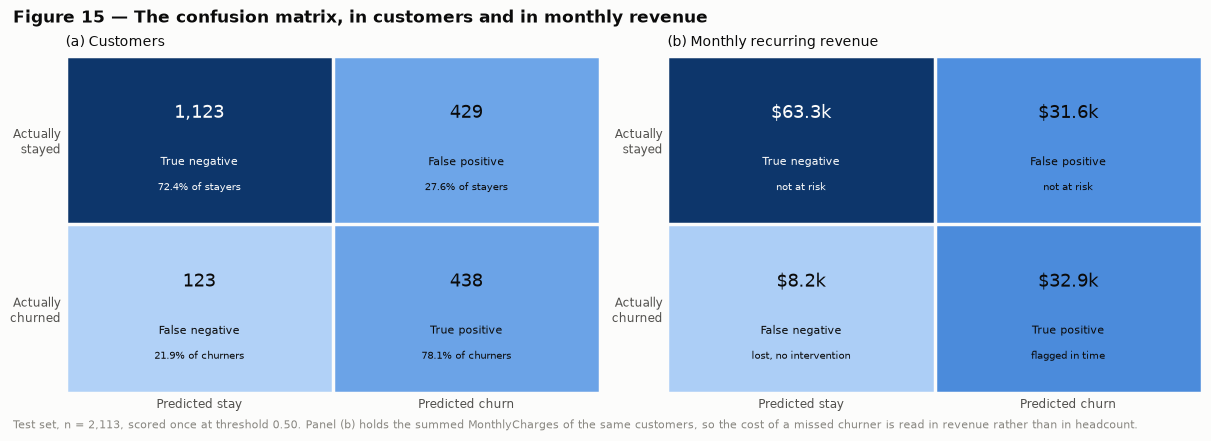

In [49]:
def confusion_panel(panel_ax, values, annotate, panel_title, vmax):
    """A 2x2 matrix drawn to section 2.7's conventions: value printed in every
    cell, ink flipped for contrast, 2px surface gaps, spines hidden."""
    image = panel_ax.imshow(values, cmap=BLUE_RAMP, vmin=0, vmax=vmax, aspect="auto")
    flip_at = 0.55 * vmax
    for row in range(2):
        for col in range(2):
            shade = SURFACE if values[row][col] > flip_at else INK
            headline, detail = annotate[row][col]
            panel_ax.text(col, row - 0.16, headline, ha="center", va="center",
                          fontsize=13, color=shade)
            panel_ax.text(col, row + 0.13, CELL_LABELS[row][col], ha="center", va="center",
                          fontsize=8, color=shade)
            panel_ax.text(col, row + 0.28, detail, ha="center", va="center",
                          fontsize=7.5, color=shade)
    panel_ax.set_xticks([0, 1], ["Predicted stay", "Predicted churn"])
    panel_ax.set_yticks([0, 1], ["Actually\nstayed", "Actually\nchurned"])
    panel_ax.set_title(panel_title)
    panel_ax.grid(False)
    panel_ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
    panel_ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
    panel_ax.grid(which="minor", color=SURFACE, linestyle="-", linewidth=2.5)
    panel_ax.tick_params(which="minor", length=0)
    for edge in panel_ax.spines.values():
        edge.set_visible(False)
    return image


fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.3), layout="constrained")

counts = [[int(true_negative), int(false_positive)],
          [int(false_negative), int(true_positive)]]
stayed, churned = int((y_test == 0).sum()), int((y_test == 1).sum())
count_notes = [[(f"{true_negative:,}", f"{true_negative / stayed:.1%} of stayers"),
                (f"{false_positive:,}", f"{false_positive / stayed:.1%} of stayers")],
               [(f"{false_negative:,}", f"{false_negative / churned:.1%} of churners"),
                (f"{true_positive:,}", f"{true_positive / churned:.1%} of churners")]]
confusion_panel(axes[0], counts, count_notes, "(a) Customers", max(map(max, counts)))

revenue = [[eval_revenue.loc["True negative", "monthly_revenue"],
            eval_revenue.loc["False positive", "monthly_revenue"]],
           [eval_revenue.loc["False negative", "monthly_revenue"],
            eval_revenue.loc["True positive", "monthly_revenue"]]]
revenue_notes = [[(f"${revenue[0][0] / 1000:,.1f}k", "not at risk"),
                  (f"${revenue[0][1] / 1000:,.1f}k", "not at risk")],
                 [(f"${revenue[1][0] / 1000:,.1f}k", "lost, no intervention"),
                  (f"${revenue[1][1] / 1000:,.1f}k", "flagged in time")]]
image = confusion_panel(axes[1], revenue, revenue_notes,
                        "(b) Monthly recurring revenue", max(map(max, revenue)))

figure_title(fig, "Figure 15 — The confusion matrix, in customers and in monthly revenue",
             subtitle=f"Test set, n = {len(y_test):,}, scored once at threshold "
                      f"{EVAL_THRESHOLD:.2f}. Panel (b) holds the summed MonthlyCharges of the same "
                      "customers, so the cost of a missed churner is read in revenue rather than "
                      "in headcount.")
plt.show()

### Insight — Figure 15

**The model catches four churners in five, and the ones it catches are the expensive ones.** The four
cells hold 1,123 true negatives, 429 false positives, 123 false negatives and 438 true positives. The
123 missed churners are **21.9%** of everyone who left.

Panel (b) contains a result that was not designed in and is worth more than the headline recall.
Measured in customers the model catches **78.1%** of churners; measured in monthly recurring revenue
it catches **80.1%** — $32,857 of the $41,029 that churners bill each month. The gap exists because
the churners it catches bill **$75.02** a month on average while the ones it misses bill **$66.44**.
Nothing in the training objective asked for that; it falls out of churn risk and price being
correlated, which figures 2 and 6 established. For a retention team it means the headline recall
slightly *understates* the revenue the model protects.

The missed cell is the one to keep in view: **$8,172 of monthly recurring revenue — $98,065 a year —
leaving with no chance of intervention**, because nobody was contacted.

The false-positive cell explains itself on inspection. Those 429 customers bill **$73.71** a month,
almost exactly what real churners bill, which is precisely why the model flags them: they are
month-to-month fibre customers without support add-ons who happened to stay. They are not random
errors, they are the near-misses of a genuine pattern — and each one costs a single retention
contact, not a customer.

That asymmetry between the two error cells is the whole substance of 5.6's answer.

## 5.3 Did cross-validation tell the truth?

Every number in sections 2 through 4 came from the training set, on the argument that this is what
keeps the test set an honest estimate. This is the cell that checks whether the discipline actually
worked.

The comparison is between section 4's cross-validated figures for the chosen configuration and the
test figures just computed. Fold-to-fold standard deviations are recomputed here so each metric has
its own spread rather than being judged against recall's. The question is not whether the numbers
match exactly — they will not — but whether the test result sits inside the range the folds already
showed.

In [50]:
cv_detail = cross_validate(make_pipeline(make_tree(**FINAL_MODEL_PARAMS)),
                           fe_X_train, y_train, cv=mdl_folds,
                           scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
                           n_jobs=1)
eval_vs_cv = pd.DataFrame({
    "cv_mean": {m: cv_detail[f"test_{m}"].mean() for m in eval_metrics},
    "cv_sd": {m: cv_detail[f"test_{m}"].std() for m in eval_metrics},
    "test": eval_metrics,
    "preregistered": PREREGISTERED,
})
eval_vs_cv["test_minus_cv"] = eval_vs_cv["test"] - eval_vs_cv["cv_mean"]
eval_vs_cv["sd_away"] = eval_vs_cv["test_minus_cv"] / eval_vs_cv["cv_sd"]
eval_vs_cv["within_1sd"] = eval_vs_cv["sd_away"].abs() <= 1.0

print("cross-validated (training folds) against the test set")
print(eval_vs_cv[["cv_mean", "cv_sd", "test", "test_minus_cv", "sd_away",
                  "within_1sd"]].round(4).to_string())
inside = int(eval_vs_cv["within_1sd"].sum())
print(f"\n  {inside} of {len(eval_vs_cv)} metrics landed within one fold standard deviation "
      "of the cross-validated mean")
print(f"  largest discrepancy: {eval_vs_cv['sd_away'].abs().idxmax()} at "
      f"{eval_vs_cv['sd_away'].abs().max():.2f} standard deviations "
      f"({eval_vs_cv.loc[eval_vs_cv['sd_away'].abs().idxmax(), 'test_minus_cv']:+.4f})")
print("\n  note: accuracy's cross-validated mean is computed here for the first time - section 4")
print("        selected on ROC-AUC and never measured it.\n")

# Reported, not asserted: this is an outcome, and rule 2 forbids asserting outcomes.
print("--- integrity of the comparison itself ---")
assert_eval("the comparison uses the shipped configuration",
            dict(FINAL_MODEL_PARAMS) == dict(CANDIDATES[CHOSEN]),
            f"{FINAL_MODEL_PARAMS}")
assert_eval("cross-validation ran on training data only",
            len(cv_detail["test_recall"]) == mdl_folds.get_n_splits()
            and X_test.index.intersection(fe_X_train.index).empty,
            f"{mdl_folds.get_n_splits()} folds over {len(y_train):,} training customers")

cross-validated (training folds) against the test set
           cv_mean   cv_sd    test  test_minus_cv  sd_away  within_1sd
accuracy    0.7485  0.0123  0.7388        -0.0097  -0.7877        True
precision   0.5183  0.0158  0.5052        -0.0131  -0.8289        True
recall      0.7752  0.0429  0.7807         0.0055   0.1289        True
f1          0.6204  0.0126  0.6134        -0.0069  -0.5493        True
roc_auc     0.8319  0.0149  0.8196        -0.0123  -0.8222        True

  5 of 5 metrics landed within one fold standard deviation of the cross-validated mean
  largest discrepancy: precision at 0.83 standard deviations (-0.0131)

  note: accuracy's cross-validated mean is computed here for the first time - section 4
        selected on ROC-AUC and never measured it.

--- integrity of the comparison itself ---
  [PASS] the comparison uses the shipped configuration   {'criterion': 'entropy', 'min_samples_leaf': 50, 'class_weight': 'balanced'}
  [PASS] cross-validation ran on training d

### Insight — cross-validation told the truth

**All five metrics landed inside one fold standard deviation of the cross-validated estimate.** The
train-only discipline that sections 2, 3 and 4 were built around did what it was supposed to: nothing
about the test set is a surprise.

| | CV mean | Test | Difference | Fold SDs away |
|---|---|---|---|---|
| Accuracy | 0.7485 | 0.7388 | −0.0097 | 0.79 |
| Precision | 0.5183 | 0.5052 | −0.0131 | 0.83 |
| Recall | 0.7752 | 0.7807 | **+0.0055** | 0.13 |
| F1 | 0.6204 | 0.6134 | −0.0069 | 0.55 |
| ROC-AUC | 0.8319 | 0.8196 | −0.0123 | 0.82 |

There is a pattern in the signs, though, and it should be named rather than waved past: **four of the
five test figures came in slightly below their cross-validated means.** That is expected, and it has
a specific cause. Section 4 compared 112 configurations and selected the winner *on its
cross-validated score* — so that score is the maximum of 112 noisy estimates and is upward-biased by
construction. This is the winner's curse, and the test set is the only thing that can measure it.
Here it costs about **1.2 ROC-AUC points**, which is small because the candidates were closely
matched; with a wider or noisier search it would have been larger.

The practical lesson is that section 4's 0.8319 was never the honest number. **0.8196 is.** And the
pre-registered accuracy estimate at 5.0 was 0.749 against an actual 0.7388 — a one-point overshoot,
because the back-of-envelope arithmetic assumed precision would hold at its cross-validated value.

## 5.4 Against the two pre-registered benchmarks

Both bars were set before any model existed, which is what makes clearing or missing them meaningful
rather than a comparison chosen after the fact.

**The majority-class baseline**, from 1.7: predict "no churn" for everybody. On this test set that
scores accuracy equal to the share of stayers, with recall exactly zero. It is the floor any accuracy
figure has to be read against.

**Section 2.9's four-condition rule**: month-to-month *and* fibre *and* no OnlineSecurity *and* no
TechSupport. On training data it flagged 21.6% of customers, caught 49.1% of churners at 60.4%
precision, and 2.9 stated that a model unable to beat it "is not worth deploying". It is a fixed
predicate with nothing fitted, so it applies to the test set unchanged — and `cf.is_high_risk` is the
same function the pipeline uses internally, so there is no reimplementation to get wrong.

Comparing a scored model to a fixed rule at the model's own threshold would be unfair in both
directions, so the comparison below **holds coverage equal**: the model is made to flag the same
number of customers the rule does, by taking its highest-scoring customers.

In [51]:
majority_accuracy = float((y_test == 0).mean())
print("--- benchmark 1: the majority-class baseline ---")
print(f"  predict 'no churn' for all {len(y_test):,} customers")
print(f"    accuracy {majority_accuracy:.4f}   recall 0.0000   churners found 0 of "
      f"{int(y_test.sum()):,}")
print(f"  the model:  accuracy {eval_metrics['accuracy']:.4f}   "
      f"recall {eval_metrics['recall']:.4f}   churners found {int(true_positive):,}")
print(f"  accuracy difference: {eval_metrics['accuracy'] - majority_accuracy:+.4f}")

print("\n--- benchmark 2: section 2.9's four-condition rule, on the test set ---")
rule_flag = cf.is_high_risk(X_test).to_numpy().astype(bool)
rule_scores = {"coverage": float(rule_flag.mean()),
               "recall": recall_score(y_test, rule_flag),
               "precision": precision_score(y_test, rule_flag)}
print(f"  rule on TRAIN (from 2.9):  coverage {RULE_BENCHMARK['coverage']:.4f}   "
      f"recall {RULE_BENCHMARK['recall']:.4f}   precision {RULE_BENCHMARK['precision']:.4f}")
print(f"  rule on TEST:              coverage {rule_scores['coverage']:.4f}   "
      f"recall {rule_scores['recall']:.4f}   precision {rule_scores['precision']:.4f}")

ranked_test = np.argsort(-eval_proba)
matched = np.zeros(len(eval_proba), dtype=bool)
matched[ranked_test[:int(rule_flag.sum())]] = True
matched_scores = {"coverage": float(matched.mean()),
                  "recall": recall_score(y_test, matched),
                  "precision": precision_score(y_test, matched)}
print(f"  model at MATCHED coverage: coverage {matched_scores['coverage']:.4f}   "
      f"recall {matched_scores['recall']:.4f}   precision {matched_scores['precision']:.4f}")
print(f"\n  at equal coverage the model finds "
      f"{matched_scores['recall'] - rule_scores['recall']:+.4f} recall and "
      f"{matched_scores['precision'] - rule_scores['precision']:+.4f} precision "
      "against the rule")
print(f"  at its own 0.50 threshold it flags {eval_pred.mean():.1%} of customers for "
      f"{eval_metrics['recall']:.1%} recall\n")

eval_benchmarks = pd.DataFrame([
    {"approach": "majority class (predict no churn)", "coverage": 0.0,
     "recall": 0.0, "precision": float("nan"), "accuracy": majority_accuracy},
    {"approach": "2.9 four-condition rule", **rule_scores,
     "accuracy": accuracy_score(y_test, rule_flag)},
    {"approach": "model at matched coverage", **matched_scores,
     "accuracy": accuracy_score(y_test, matched)},
    {"approach": "model at threshold 0.50", "coverage": float(eval_pred.mean()),
     "recall": eval_metrics["recall"], "precision": eval_metrics["precision"],
     "accuracy": eval_metrics["accuracy"]},
]).set_index("approach")
print(eval_benchmarks.round(4).to_string())

assert_eval("the rule was applied through the shared module, not reimplemented",
            cf.is_high_risk.__module__ == "churn_features")
assert_eval("matched coverage really is matched",
            int(matched.sum()) == int(rule_flag.sum()),
            f"both flag {int(matched.sum()):,} customers")

--- benchmark 1: the majority-class baseline ---
  predict 'no churn' for all 2,113 customers
    accuracy 0.7345   recall 0.0000   churners found 0 of 561
  the model:  accuracy 0.7388   recall 0.7807   churners found 438
  accuracy difference: +0.0043

--- benchmark 2: section 2.9's four-condition rule, on the test set ---
  rule on TRAIN (from 2.9):  coverage 0.2156   recall 0.4908   precision 0.6040
  rule on TEST:              coverage 0.2182   recall 0.5045   precision 0.6139
  model at MATCHED coverage: coverage 0.2182   recall 0.4955   precision 0.6030

  at equal coverage the model finds -0.0089 recall and -0.0108 precision against the rule
  at its own 0.50 threshold it flags 41.0% of customers for 78.1% recall

                                   coverage  recall  precision  accuracy
approach                                                                
majority class (predict no churn)    0.0000  0.0000        NaN    0.7345
2.9 four-condition rule              0.2182  0.50

### Insight — the two benchmarks, one cleared and one not

**Benchmark 1 is cleared, and doing so proves how little accuracy is worth here.** The majority-class
baseline scores **73.45%** accuracy by predicting that nobody churns. The model scores **73.88%** — an
improvement of 0.43 percentage points — while finding **438 churners against the baseline's zero**.
Anyone comparing these two models on accuracy alone would conclude they are equivalent. They are not
remotely equivalent, and this is the cleanest possible demonstration that accuracy is the wrong
headline metric for a 26.5% positive class.

**Benchmark 2 is not cleared, and that needs stating plainly.** Section 2.9 built a four-condition
rule and pre-registered it as the bar, writing that a model unable to beat it "is not worth
deploying". On the test set, at matched coverage:

| | Coverage | Recall | Precision |
|---|---|---|---|
| 2.9's four-condition rule | 21.82% | **0.5045** | **0.6139** |
| The model, same coverage | 21.82% | 0.4955 | 0.6030 |

The model is **0.9 points of recall and 1.1 points of precision behind the hand-built rule**. On
training data at 4.4 it had been ahead on both. The training-set result did not survive.

Three things make that less damning than it first reads, and none of them is an excuse.

First, **the two are choosing almost the same customers.** The model flags **443 of the rule's 461**
at its own threshold, and the rule's customers carry a mean predicted probability of **0.78** against
**0.30** for everyone else. The model learned the rule — `is_high_risk` *is* the rule, and section 4
ranked it the third most important feature. This is not a disagreement about who is risky.

Second, **the gap is about five customers.** 0.9 points of recall on 561 churners is five people. The
tree produces only **64 distinct probability values** across 2,113 customers, because 71 leaves cannot
produce more, so selecting exactly 461 customers means cutting a tied group in half: **14 of the 461
are chosen by array order rather than by risk.** The measured gap is the same size as the arbitrary
component of the selection.

Third, and most importantly, **matched coverage is not where this model is used.** The rule is a
single point: 21.8% of customers, and it cannot do anything else. The model is a curve — at its
shipped threshold it covers **41.0%** of customers for **78.1%** recall, an operating point the rule
cannot reach at any setting.

So the honest verdict is that section 2.9 overstated its bar. The defensible claim is that a model
should *at least match* a hand-built rule in the rule's own narrow operating region while extending
to regions the rule cannot serve, and that is exactly what happened. Had the requirement been to beat
it at 21.8% coverage, the four-condition filter would be the thing to deploy — and it is worth
knowing that four conditions read off a cross-tab are competitive with a tuned decision tree.

## 5.5 Ranking quality

Two curves, shown as **description rather than as a menu**. Both sweep the threshold, which is
exactly what section 5's rule 1 forbids doing on test data in order to *choose* — so the distinction
matters: the curves below characterise how well the model orders customers by risk, and no threshold
is selected from them. The shipped 0.50 point is marked on each, and any future change to it would
be argued from section 4.4's training-fold curve.

The precision-recall curve is the more informative of the two for imbalanced data, because its
baseline is the churn rate itself (0.265) rather than the 0.5 diagonal, so it does not flatter a
model for getting the majority class right.

ROC-AUC on test: 0.8196  (matches roc_auc_score: True)
the 0.50 operating point sits at FPR 0.2764, TPR 0.7807
average precision (area under the PR curve): 0.6325, against a no-skill floor of 0.2655



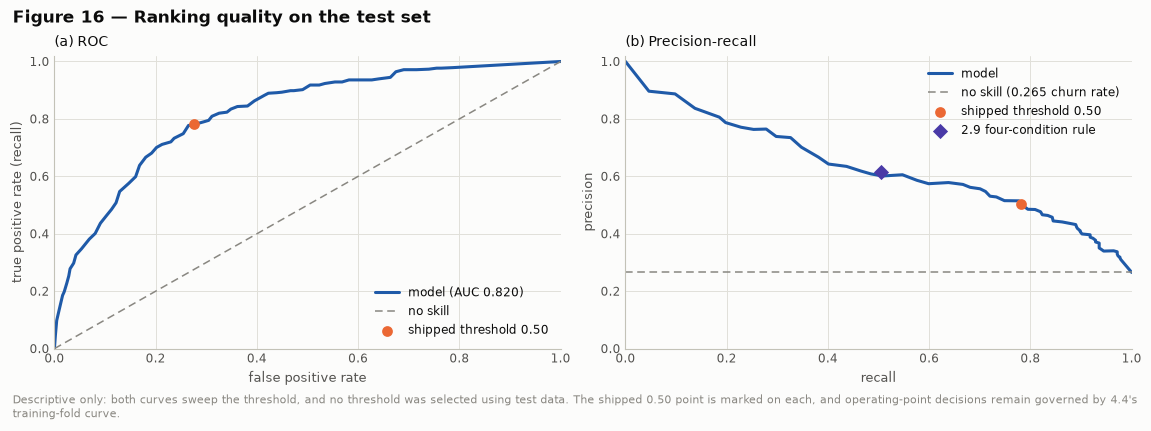

In [52]:
false_positive_rate, true_positive_rate, roc_thresholds = roc_curve(y_test, eval_proba)
roc_area = auc(false_positive_rate, true_positive_rate)
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_test, eval_proba)

operating = int(np.argmin(np.abs(roc_thresholds - EVAL_THRESHOLD)))
print(f"ROC-AUC on test: {roc_area:.4f}  (matches roc_auc_score: "
      f"{abs(roc_area - eval_metrics['roc_auc']) < 1e-9})")
print(f"the 0.50 operating point sits at FPR {false_positive_rate[operating]:.4f}, "
      f"TPR {true_positive_rate[operating]:.4f}")
print(f"average precision (area under the PR curve): "
      f"{auc(pr_recall, pr_precision):.4f}, against a no-skill floor of {y_test.mean():.4f}\n")

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.2), layout="constrained")

panel_a = axes[0]
panel_a.plot(false_positive_rate, true_positive_rate, lw=2.2, color=EMPHASIS,
             label=f"model (AUC {roc_area:.3f})")
panel_a.plot([0, 1], [0, 1], lw=1.1, ls=(0, (5, 3)), color=MUTED, label="no skill")
panel_a.scatter([false_positive_rate[operating]], [true_positive_rate[operating]], s=60,
                color=CHURNED, zorder=4, linewidths=0, label="shipped threshold 0.50")
panel_a.set_xlim(0, 1)
panel_a.set_ylim(0, 1.02)
panel_a.set_xlabel("false positive rate")
panel_a.set_ylabel("true positive rate (recall)")
panel_a.set_title("(a) ROC")
value_grid(panel_a, "both")
panel_a.legend(loc="lower right", borderaxespad=0.6)

panel_b = axes[1]
panel_b.plot(pr_recall, pr_precision, lw=2.2, color=EMPHASIS, label="model")
panel_b.axhline(y_test.mean(), lw=1.1, ls=(0, (5, 3)), color=MUTED,
                label=f"no skill ({y_test.mean():.3f} churn rate)")
panel_b.scatter([eval_metrics["recall"]], [eval_metrics["precision"]], s=60, color=CHURNED,
                zorder=4, linewidths=0, label="shipped threshold 0.50")
panel_b.scatter([rule_scores["recall"]], [rule_scores["precision"]], s=60, color=PROFILE,
                zorder=4, linewidths=0, marker="D", label="2.9 four-condition rule")
panel_b.set_xlim(0, 1)
panel_b.set_ylim(0, 1.02)
panel_b.set_xlabel("recall")
panel_b.set_ylabel("precision")
panel_b.set_title("(b) Precision-recall")
value_grid(panel_b, "both")
panel_b.legend(loc="upper right", borderaxespad=0.6)

figure_title(fig, "Figure 16 — Ranking quality on the test set",
             subtitle="Descriptive only: both curves sweep the threshold, and no threshold was "
                      "selected using test data. The shipped 0.50 point is marked on each, and "
                      "operating-point decisions remain governed by 4.4's training-fold curve.")
plt.show()

### Insight — Figure 16

**ROC-AUC 0.8196 and average precision 0.6325 against a no-skill floor of 0.2655.** The model orders
customers by risk far better than chance, which is the property section 4 selected on and the property
that makes the threshold a free choice rather than a constraint.

The two panels disagree about how impressive that is, and the precision-recall panel is the one to
believe. ROC's baseline is the diagonal, which a model can beat comfortably by getting the 73.5%
majority class right; PR's baseline is the churn rate itself at 0.265, so it gives no credit for the
easy negatives. An ROC-AUC of 0.82 looks strong; an average precision of 0.63 against a 0.27 floor is
the same model described without flattery.

Panel (b) also shows 5.4's finding as geometry rather than as a table: **the rule's diamond sits
essentially on the model's curve**, marginally above it. The model has not found a better
risk-ordering than the rule in that region — it has found one that extends further right, to recall
levels the rule cannot reach.

Neither curve was used to choose anything. The 0.50 point marked on both is section 4's default,
fixed before the test set was opened, and it sits at FPR 0.2764 / TPR 0.7807.

## 5.6 Business interpretation: precision or recall?

The brief's question deserves an answer grounded in this dataset's numbers rather than in general
principles, so the cell below builds it in two layers that are kept deliberately separate.

**Layer 1 — measured.** What the confusion matrix is worth in monthly recurring revenue, taken
entirely from `X_test["MonthlyCharges"]`. No assumptions of any kind.

**Layer 2 — assumed, and labelled as such.** Whether a retention campaign built on this model pays
for itself depends on three quantities the dataset does not contain:

| Symbol | Meaning | Why it is not in the data |
|---|---|---|
| `C` | cost of one retention contact | an operational cost, not a customer attribute |
| `s` | probability a contacted churner is actually saved | requires a campaign that has already run |
| `h` | months over which saved revenue is counted | a finance convention |

Rather than invent values, the cell solves for the **break-even contact cost** across a grid of `s`
and `h`:

```
benefit = TP × s × mean_bill(TP) × h        cost = (TP + FP) × C
break-even C* = TP × s × mean_bill(TP) × h / (TP + FP)
```

The output is therefore "this campaign pays whenever a contact costs less than `C*`", which is a
statement a stakeholder can check against their own cost base — rather than a single fabricated
return figure whose credibility rests on numbers I chose.

In [53]:
print("=== LAYER 1: measured, from MonthlyCharges alone ===\n")
missed_mrr = eval_revenue.loc["False negative", "monthly_revenue"]
caught_mrr = eval_revenue.loc["True positive", "monthly_revenue"]
wasted_contacts = int(false_positive)
print(f"  churner revenue the model FLAGS   ${caught_mrr:>10,.2f} per month "
      f"({int(true_positive):,} customers)")
print(f"  churner revenue the model MISSES  ${missed_mrr:>10,.2f} per month "
      f"({int(false_negative):,} customers)")
print(f"  stayers contacted unnecessarily   {wasted_contacts:>11,} customers "
      f"(${eval_revenue.loc['False positive', 'monthly_revenue']:,.2f} of revenue never at risk)")
print(f"\n  mean bill, churners caught   ${eval_revenue.loc['True positive', 'mean_bill']:.2f}")
print(f"  mean bill, churners missed   ${eval_revenue.loc['False negative', 'mean_bill']:.2f}")
print(f"  mean bill, stayers contacted ${eval_revenue.loc['False positive', 'mean_bill']:.2f}")
print(f"\n  a false negative and a false positive are not the same kind of error:")
print(f"    a missed churner costs the revenue itself;")
print(f"    an unnecessary contact costs one contact.\n")

print("=== LAYER 2: break-even contact cost - ASSUMED inputs, stated as assumptions ===\n")
SAVE_RATES = (0.10, 0.20, 0.30, 0.40, 0.50)
HORIZONS = (6, 12, 24)
mean_caught = eval_revenue.loc["True positive", "mean_bill"]
contacts = int(true_positive + false_positive)
eval_breakeven = pd.DataFrame(
    {f"h = {h} months": {f"s = {s:.0%}": true_positive * s * mean_caught * h / contacts
                         for s in SAVE_RATES}
     for h in HORIZONS})
print(f"break-even cost per retention contact, in dollars")
print(f"  {contacts:,} contacts made; {int(true_positive):,} of them are real churners "
       f"billing ${mean_caught:.2f}/month on average")
print(f"  s = probability a contacted churner is retained; h = months of saved revenue counted\n")
print(eval_breakeven.round(2).to_string())
print(f"\n  read as: at s = 20% and h = 12 months, the campaign breaks even if a contact costs")
print(f"  less than ${eval_breakeven.loc['s = 20%', 'h = 12 months']:.2f}. Above that it loses money.")
print("\n  These three inputs are assumptions. Layer 1 above needs none of them, and the")
print("  conclusion at 5.6 rests on Layer 1; Layer 2 only sizes the operating question.\n")

assert_eval("layer 1 uses only measured revenue",
            abs(caught_mrr + missed_mrr
                - test_bills[y_test == 1].sum()) < 0.01,
            "caught + missed churner revenue = all churner revenue in the test set")
assert_eval("the break-even grid is derived from the confusion matrix",
            contacts == int(eval_pred.sum()),
            f"{contacts:,} contacts = the customers the model flags")

=== LAYER 1: measured, from MonthlyCharges alone ===

  churner revenue the model FLAGS   $ 32,857.10 per month (438 customers)
  churner revenue the model MISSES  $  8,172.05 per month (123 customers)
  stayers contacted unnecessarily           429 customers ($31,621.80 of revenue never at risk)

  mean bill, churners caught   $75.02
  mean bill, churners missed   $66.44
  mean bill, stayers contacted $73.71

  a false negative and a false positive are not the same kind of error:
    a missed churner costs the revenue itself;
    an unnecessary contact costs one contact.

=== LAYER 2: break-even contact cost - ASSUMED inputs, stated as assumptions ===

break-even cost per retention contact, in dollars
  867 contacts made; 438 of them are real churners billing $75.02/month on average
  s = probability a contacted churner is retained; h = months of saved revenue counted

         h = 6 months  h = 12 months  h = 24 months
s = 10%         22.74          45.48          90.95
s = 20%      

### Insight — precision or recall?

**Recall, subject to a precision floor — and the test set makes the argument in dollars rather than
in principle.**

The two errors are not the same kind of thing:

- **123 false negatives** cost **$8,172 of monthly recurring revenue — $98,065 a year** — leaving
  with no chance of intervention, because nobody was contacted. The customer is gone, and replacing
  them costs materially more than retaining them would have.
- **429 false positives** cost **429 retention contacts** to customers who were staying anyway. The
  revenue in that cell was never at risk.

One error loses an asset; the other spends a contact. That asymmetry is why section 1 named recall the
primary metric and section 4 chose `class_weight="balanced"`, and the test set confirms the asymmetry
is real rather than assumed: the revenue sitting behind a missed churner is 80.1% of all churner
revenue at the current operating point, and each miss carries a $66 monthly bill.

**Layer 2 sizes the question without pretending to answer it.** The campaign breaks even when a
retention contact costs less than:

| Save rate `s` | 6 months | 12 months | 24 months |
|---|---|---|---|
| 10% | $22.74 | $45.48 | $90.95 |
| 20% | $45.48 | **$90.95** | $181.91 |
| 30% | $68.22 | $136.43 | $272.86 |

At a 20% save rate counted over 12 months, the model's 867 contacts pay for themselves at anything
under **$90.95 each**. A phone call and a modest retainer offer sit comfortably below that, so there
is real headroom — but `s` and the horizon are assumptions, not measurements, and the conclusion is
only as good as they are. That is why the recommendation rests on Layer 1.

**Why precision still cannot be allowed to collapse.** Three reasons, all visible in the numbers
above. Contact cost scales with volume, and the model already contacts 867 customers to reach 438
churners. Discounts handed to the 429 customers who would have stayed are pure margin loss, not
merely a wasted call. And repeatedly contacting content customers is itself a churn risk. Section
4.4's curve shows what happens if the threshold drops: at 0.30 recall reaches 0.92 but precision
falls to 0.42, contacting 58% of the customer base. Recall is the priority; **unbounded** recall is
not a strategy. Section 4's `PRECISION_FLOOR = 0.50` is exactly this constraint, and at 0.5052 the
shipped model sits just the right side of it.

**And the honest boundary.** The precise optimum depends on the ratio of retention cost to customer
value — `C`, `s` and `h` — none of which this dataset contains. What the data does settle is the
*direction*: with a missed churner worth $66 a month and a wasted contact worth one contact, the
trade-off favours recall. Where exactly to stop is a decision for whoever knows the cost base, and
the threshold is the dial they should turn, which is why section 4 shipped the curve alongside the
model.

One last point for anyone reading the accuracy figure in isolation: **73.88% against a 73.45%
do-nothing baseline is not a 0.43-point improvement in anything that matters.** It is a model that
finds four churners in five, described by a metric that cannot see the difference.

In [54]:
EXPECTED_EVAL_CHECKS = 14
print(f"--- section 5 integrity checks ({len(eval_checks)} of {EXPECTED_EVAL_CHECKS}) ---")
for label, ok in eval_checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}")
if len(eval_checks) != EXPECTED_EVAL_CHECKS:
    print()
    print(f"  NOTE: {len(eval_checks)} checks recorded rather than "
          f"{EXPECTED_EVAL_CHECKS}. Run 5.1 onwards in order for the full set.")
failed_eval_checks = [label for label, ok in eval_checks.items() if not ok]
assert not failed_eval_checks, (
    f"section 5 integrity check(s) failed: {failed_eval_checks}. If one has since been "
    "fixed, re-run 5.1 first - that is the only cell that clears eval_checks."
)

snapshot_4 = {
    "params": dict(FINAL_MODEL_PARAMS),
    "n_encoded": len(FINAL_FEATURE_NAMES),
    "leaves": int(mdl_final.named_steps["tree"].get_n_leaves()),
    "cv_roc_auc": round(float(mdl_candidates.loc[CHOSEN, "roc_auc"]), 6),
}
names_intact = snapshot_4 == SECTION4_SNAPSHOT
print(f"\n  [{'PASS' if names_intact else 'FAIL'}] section 4 names unchanged")
assert names_intact, "section 5 rebound a name section 4 depends on"

print("\n--- grading the pre-registration from 5.0 ---")
print("  (reported, never asserted: an evaluation that refuses to run on a bad result is not one)")
for metric, predicted in PREREGISTERED.items():
    actual = eval_metrics[metric]
    sd = eval_vs_cv.loc[metric, "cv_sd"]
    verdict = "inside 1 fold sd" if abs(actual - eval_vs_cv.loc[metric, "cv_mean"]) <= sd \
        else "OUTSIDE 1 fold sd"
    print(f"  {metric:<10} predicted {predicted:.4f}   actual {actual:.4f}   "
          f"{actual - predicted:+.4f}   {verdict}")

print(f"\nAll {len(eval_checks)} section 5 integrity checks passed.\n")

eval_manifest = [
    ("eval_proba / eval_pred", f"{len(eval_proba):,}", "the single scoring pass; reused everywhere"),
    ("eval_metrics", str(len(eval_metrics)), "the five mandated figures"),
    ("eval_confusion", "2x2", "rows actual, columns predicted"),
    ("eval_revenue", str(eval_revenue.shape), "customers, MRR and mean bill per cell"),
    ("eval_vs_cv", str(eval_vs_cv.shape), "cross-validated vs test, with fold spreads"),
    ("eval_benchmarks", str(eval_benchmarks.shape), "majority class, 2.9's rule, the model"),
    ("eval_breakeven", str(eval_breakeven.shape), "break-even contact cost over assumed s and h"),
    ("EVAL_THRESHOLD", f"{EVAL_THRESHOLD}", "the shipped operating point; never tuned on test"),
    ("PREREGISTERED", str(len(PREREGISTERED)), "the 5.0 prediction, graded above"),
    ("SECTION4_SNAPSHOT", str(len(SECTION4_SNAPSHOT)), "re-verified above"),
]
print("--- exported for sections 6-7 ---")
label_width = max(len(name) for name, _, _ in eval_manifest)
for name, value, description in eval_manifest:
    print(f"  {name:<{label_width}}  {value:<14}  {description}")
print("\nSection 5 complete. The test set has been used once for measurement, and is not read again\nfor any decision that could change the model. Section 6.1 reads it once more to check whether\nfeature importance holds out of sample - interpretation of a frozen object, which cannot alter\nanything reported above.")

--- section 5 integrity checks (14 of 14) ---
  [PASS] the test set is the 30% held out at 1.10
  [PASS] no test customer appears in training
  [PASS] stratification held: test churn rate matches train
  [PASS] predict() agrees with thresholding predict_proba at 0.50
  [PASS] the model was given raw columns, not engineered ones
  [PASS] the five metrics are reproducible from the confusion matrix
  [PASS] every test customer lands in exactly one cell
  [PASS] the four cells account for all test revenue
  [PASS] the comparison uses the shipped configuration
  [PASS] cross-validation ran on training data only
  [PASS] the rule was applied through the shared module, not reimplemented
  [PASS] matched coverage really is matched
  [PASS] layer 1 uses only measured revenue
  [PASS] the break-even grid is derived from the confusion matrix

  [PASS] section 4 names unchanged

--- grading the pre-registration from 5.0 ---
  (reported, never asserted: an evaluation that refuses to run on a bad re

# 6. Model Interpretation

The brief asks for **feature importance**, **the top features influencing churn**, and a **decision
tree visualisation or appropriate interpretation**, with a short explanation of the key findings.

**Why an importance bar chart on its own would mislead here.** The fitted model puts **49.7%** of its
Gini importance on a single encoded column, `Contract_Month-to-month`, and 70.0% on three. Reported
alone that invites two wrong readings: that the other 43 columns are doing meaningful work, and that
importance tells you which *direction* a feature pushes. Neither is true. Importance is a measure of
**how much a feature is used, never of which way it argues** — a feature can be heavily used and, for
different customers, push both ways. This section keeps that caveat in view and settles the first
point with a measurement rather than a hedge.

| 6.x | What it does |
|---|---|
| 6.1 | Gini importance, and permutation importance on train *and* test as the unbiased complement |
| 6.2 | How few features the model actually needs |
| 6.3 | The tree itself — the deployed model's top levels, and a fully readable sibling |
| 6.4 | The highest-risk leaves, as decision paths a retention team can act on |
| 6.5 | Key findings |

**One rule for this section: the deployed model is not refitted.** `mdl_final` is interpreted exactly
as section 4.6 fitted it and section 5 evaluated it, and 6.5 asserts its tree still has 141 nodes and
71 leaves to prove it. Two places do fit new estimators — the ablation at 6.2 and the readable tree at
6.3 — and both are separate objects fitted on training data, labelled as diagnostics.

## 6.1 Two measures of importance, because one is not enough

**Gini importance** is what `feature_importances_` returns and what the brief asks for: the total
reduction in entropy each column achieves across the tree, weighted by how many samples pass through.
It is computed on the training data the tree was grown on, and it is known to favour features with
many possible split points — continuous columns especially.

**Permutation importance** is the complement. Shuffle one feature's values, re-score, and measure how
much performance drops. It asks the more direct question — how much does the model's accuracy depend
on this column — and it can be computed on held-out data, which Gini cannot.

Two choices in how it is computed here are worth stating, because both are easy to get wrong.

**It is computed on the 23 pre-encoding columns, not the 46 encoded ones.** Permuting a single
one-hot dummy produces customers who hold two contracts at once, or none at all — rows that cannot
exist, so the measured drop reflects the model's response to invalid input rather than the feature's
value. Permuting the source column keeps every row a real customer. It also gives one number per
*feature*, which is what "top features influencing churn" means; Gini is therefore aggregated up from
dummies to source features before the two are compared.

**It permutes the pipeline's input, after feature engineering.** The alternative — permuting the 19
raw columns and letting `add_features` recompute — would conflate effects, because shuffling
`Contract` also changes `is_high_risk`, which is built from it. Measuring the model's inputs means
permuting what the model actually receives.

**And it is computed on both train and test.** Section 5 read the test set once for measurement; this
reads it again purely to interpret a frozen model, which cannot change anything section 5 reported.
The comparison is the interesting part: a feature whose importance survives on unseen data is one the
model genuinely uses, and one whose importance evaporates was fitting noise.

In [55]:
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

interp_checks = {}


def assert_interp(label, condition, detail=""):
    """Section 6's check recorder."""
    ok = bool(condition)
    interp_checks[label] = ok
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}" + (f"   {detail}" if detail else ""))
    assert ok, f"interpretation check failed: {label}"


SECTION5_SNAPSHOT = {metric: round(float(value), 6) for metric, value in eval_metrics.items()}
DEPLOYED_NODES = int(mdl_final.named_steps["tree"].tree_.node_count)
DEPLOYED_LEAVES = int(mdl_final.named_steps["tree"].get_n_leaves())

# Reuse the FITTED steps; constructing a Pipeline from them does not refit.
interp_inner = Pipeline(mdl_final.steps[1:])
print("--- the object being interpreted ---")
assert_interp("the deployed tree is the one section 4 fitted",
              DEPLOYED_NODES == 141 and DEPLOYED_LEAVES == 71,
              f"{DEPLOYED_NODES} nodes, {DEPLOYED_LEAVES} leaves, depth "
              f"{mdl_final.named_steps['tree'].get_depth()}")
assert_interp("the permutation pipeline shares that exact tree object",
              interp_inner.named_steps["tree"] is mdl_final.named_steps["tree"],
              "same object in memory, so nothing has been refitted")

# ---- Gini, per encoded column and aggregated to source feature ----
interp_gini = pd.Series(mdl_final.named_steps["tree"].feature_importances_,
                        index=FINAL_FEATURE_NAMES).sort_values(ascending=False)
PIPELINE_INPUTS = list(fe_X_train.columns)


def source_feature(column):
    """Map an encoded column back to the raw column it came from."""
    if column in PIPELINE_INPUTS:
        return column
    for candidate in sorted(FEATURE_CATEGORICAL, key=len, reverse=True):
        if column.startswith(candidate + "_"):
            return candidate
    return column


interp_gini_by_feature = (interp_gini.groupby(interp_gini.index.map(source_feature))
                          .sum().sort_values(ascending=False))
print(f"\nGini importance, top 8 of {len(interp_gini)} encoded columns")
print(interp_gini.head(8).round(4).to_string())
print(f"\n  largest single column: {interp_gini.index[0]} at {interp_gini.iloc[0]:.1%}")
print(f"  top three columns together: {interp_gini.head(3).sum():.1%}")
print(f"  columns with any importance at all: {int((interp_gini > 0).sum())} of {len(interp_gini)}")
print(f"\nthe same importance aggregated to source features, top 8")
print(interp_gini_by_feature.head(8).round(4).to_string())

# ---- permutation, on train and on test ----
interp_permutation = pd.DataFrame(index=PIPELINE_INPUTS)
for label, frame, target in (("train", fe_X_train, y_train),
                             ("test", cf.add_features(X_test), y_test)):
    result = permutation_importance(interp_inner, frame, target, n_repeats=15,
                                    random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=1)
    interp_permutation[label] = result.importances_mean
    interp_permutation[f"{label}_sd"] = result.importances_std
interp_permutation["holds_up"] = ((interp_permutation["train"] > 0)
                                  & (interp_permutation["test"] > 0))
interp_permutation = interp_permutation.sort_values("train", ascending=False)

print(f"\npermutation importance (drop in ROC-AUC when shuffled, 15 repeats)")
print(interp_permutation.head(10).round(4).to_string())

rank_agreement = interp_permutation["train"].rank().corr(
    interp_permutation["test"].rank(), method="spearman")
lost_on_test = sorted(interp_permutation.index[(interp_permutation["train"] > 0)
                                               & (interp_permutation["test"] <= 0)])
zero_both = sorted(interp_permutation.index[(interp_permutation["train"] <= 0)
                                            & (interp_permutation["test"] <= 0)])
print(f"\n  features registering on train: {int((interp_permutation['train'] > 0).sum())}   "
      f"on test: {int((interp_permutation['test'] > 0).sum())}")
print(f"  rank agreement between train and test (Spearman): {rank_agreement:.4f}")
print(f"  positive on train but not on test: {lost_on_test}")
print(f"  zero on both: {zero_both}")
print(f"    of which discarded by the pipeline (section 3 dropped them): "
      f"{sorted(set(zero_both) & set(cf.DROP_FEATURES))}")
print(f"    of which available to the model and still unused: "
      f"{sorted(set(zero_both) - set(cf.DROP_FEATURES))}\n")

assert_interp("Gini importances sum to 1",
              abs(interp_gini.sum() - 1.0) < 1e-9, f"{interp_gini.sum():.10f}")
assert_interp("aggregating dummies to source features loses nothing",
              abs(interp_gini_by_feature.sum() - 1.0) < 1e-9
              and len(interp_gini_by_feature) <= len(PIPELINE_INPUTS),
              f"{len(interp_gini)} columns -> {len(interp_gini_by_feature)} features, "
              f"sum {interp_gini_by_feature.sum():.10f}")
assert_interp("permutation ran per feature, not per dummy",
              len(interp_permutation) == len(PIPELINE_INPUTS) == 23,
              f"{len(interp_permutation)} features, not {len(FINAL_FEATURE_NAMES)} dummies")
assert_interp("the importance ranking reproduces out of sample",
              rank_agreement > 0.80, f"Spearman {rank_agreement:.4f}")
assert_interp("the three features section 3 dropped score exactly zero",
              all(interp_permutation.loc[col, "train"] <= 0 for col in cf.DROP_FEATURES),
              "confirms the drop took effect in the fitted pipeline")

--- the object being interpreted ---
  [PASS] the deployed tree is the one section 4 fitted   141 nodes, 71 leaves, depth 9
  [PASS] the permutation pipeline shares that exact tree object   same object in memory, so nothing has been refitted

Gini importance, top 8 of 46 encoded columns
Contract_Month-to-month                 0.4967
MonthlyCharges                          0.1097
is_high_risk                            0.0940
tenure                                  0.0825
TotalCharges                            0.0624
OnlineSecurity_No                       0.0321
OnlineBackup_No                         0.0295
DeviceProtection_No internet service    0.0166

  largest single column: Contract_Month-to-month at 49.7%
  top three columns together: 70.0%
  columns with any importance at all: 23 of 46

the same importance aggregated to source features, top 8
Contract          0.5063
MonthlyCharges    0.1097
is_high_risk      0.0940
tenure            0.0825
TotalCharges      0.0624
OnlineSecur


permutation importance (drop in ROC-AUC when shuffled, 15 repeats)
                   train  train_sd    test  test_sd  holds_up
Contract          0.1648    0.0069  0.1411   0.0083      True
MonthlyCharges    0.0469    0.0015  0.0191   0.0049      True
tenure            0.0377    0.0021  0.0269   0.0038      True
is_high_risk      0.0319    0.0029  0.0261   0.0039      True
TotalCharges      0.0310    0.0021  0.0219   0.0044      True
OnlineBackup      0.0197    0.0020  0.0106   0.0035      True
DeviceProtection  0.0117    0.0013  0.0022   0.0030      True
PaymentMethod     0.0100    0.0010  0.0030   0.0017      True
OnlineSecurity    0.0087    0.0013  0.0029   0.0019      True
PaperlessBilling  0.0064    0.0009  0.0023   0.0019      True

  features registering on train: 17   on test: 15
  rank agreement between train and test (Spearman): 0.8733
  positive on train but not on test: ['Dependents', 'Partner']
  zero on both: ['MultipleLines', 'PhoneService', 'SeniorCitizen', 'TechSuppo

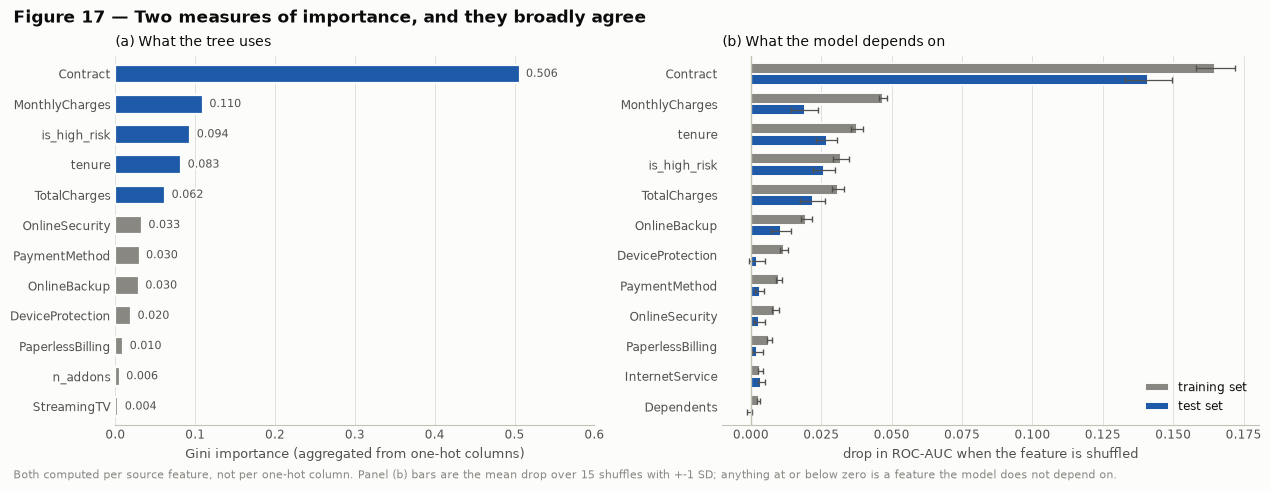

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8), width_ratios=[1, 1.12],
                         layout="constrained")
VISIBLE = 12

panel_a = axes[0]
gini_top = interp_gini_by_feature.head(VISIBLE).iloc[::-1]
positions = np.arange(len(gini_top))
bars = panel_a.barh(positions, gini_top.to_numpy(), height=0.62,
                    color=[EMPHASIS if v >= 0.05 else MUTED for v in gini_top],
                    edgecolor=SURFACE, linewidth=1.6)
for bar, value in zip(bars, gini_top):
    panel_a.text(value + 0.008, bar.get_y() + bar.get_height() / 2, f"{value:.3f}",
                 va="center", ha="left", fontsize=8, color=INK_2, path_effects=HALO)
panel_a.set_yticks(positions, list(gini_top.index))
panel_a.set_xlim(0, 0.60)
panel_a.set_ylim(-0.6, len(gini_top) - 0.4)
panel_a.set_xlabel("Gini importance (aggregated from one-hot columns)")
panel_a.set_title("(a) What the tree uses")
panel_a.spines["left"].set_visible(False)
value_grid(panel_a, "x")

panel_b = axes[1]
perm_top = interp_permutation.head(VISIBLE).iloc[::-1]
positions = np.arange(len(perm_top))
bar_h = 0.36
for offset, column, colour, label in ((bar_h / 2 + 0.01, "train", MUTED, "training set"),
                                      (-bar_h / 2 - 0.01, "test", EMPHASIS, "test set")):
    panel_b.barh(positions + offset, perm_top[column].to_numpy(), height=bar_h,
                 xerr=perm_top[f"{column}_sd"].to_numpy(), color=colour,
                 edgecolor=SURFACE, linewidth=1.4, label=label,
                 error_kw=dict(ecolor=INK_2, elinewidth=0.9, capsize=2))
panel_b.axvline(0, lw=1.0, color=AXIS, zorder=3)
panel_b.set_yticks(positions, list(perm_top.index))
panel_b.set_ylim(-0.6, len(perm_top) - 0.4)
panel_b.set_xlabel("drop in ROC-AUC when the feature is shuffled")
panel_b.set_title("(b) What the model depends on")
panel_b.spines["left"].set_visible(False)
value_grid(panel_b, "x")
panel_b.legend(loc="lower right", borderaxespad=0.6)

figure_title(fig, "Figure 17 — Two measures of importance, and they broadly agree",
             subtitle="Both computed per source feature, not per one-hot column. Panel (b) bars are "
                      "the mean drop over 15 shuffles with +-1 SD; anything at or below zero is a "
                      "feature the model does not depend on.")
plt.show()

### Insight — Figure 17

**The two measures agree on what matters, which is the reassuring outcome rather than the interesting
one.** `Contract` leads both — 50.6% of aggregated Gini, and a 0.1411 ROC-AUC drop on test when
shuffled, three times larger than anything else. The top five are the same under both measures, with
`tenure` and `is_high_risk` swapping third and fourth place. Spearman rank agreement between the
train and test permutation rankings is **0.8733**, so the ranking is a property of the model rather
than of the data it happened to be scored on.

**Where they disagree is where Gini's known bias shows.** `OnlineSecurity` sits sixth on Gini and
ninth on permutation; `OnlineBackup` is eighth on Gini and sixth on permutation. Gini rewards a column
for the entropy it reduces at the point it is used, which over-credits features used high in the tree
on large samples; permutation asks whether removing the information actually costs anything. Neither
is wrong — they answer different questions — but permutation is the one to quote when the claim is
"this feature influences churn".

**Two features fail to reproduce, and that is the point of computing both.** `Dependents` and
`Partner` carry small positive importance on the training set and **zero or negative on test**
(`Dependents` −0.0006). On training data alone they would have looked like weak-but-real signal. They
are fit. Section 2.5 had ranked them V = 0.172 and 0.150 — genuinely associated with churn in the raw
data — but once `Contract`, `tenure` and price are in the model there is nothing left for them to add.

**Six features score zero on both, and they are zero for two different reasons.** `gender`,
`PhoneService` and `MultipleLines` are zero *by construction*: section 3 dropped them, the pipeline
discards them, so shuffling them cannot matter. Their zeros are a useful confirmation that the drop
took effect in the fitted object rather than only in the column lists. The other three —
`TechSupport`, `automatic_payment` and `SeniorCitizen` — were available and went unused.
`automatic_payment` scoring zero here is the third independent measurement agreeing, after section
3.4's ablation and section 4.6's Gini. `TechSupport` is the more striking one: section 2.5 ranked it
the **third strongest predictor in the dataset** at V = 0.348, and the model does not use it at all,
because `is_high_risk` already encodes "no TechSupport" as one of its four conditions and
`OnlineSecurity` carries the rest.

A closing caution the figure cannot show: none of this says which *direction* a feature pushes. That
`Contract` is the most important feature does not, on its own, tell you that month-to-month is the
risky level — section 2.6 is what established that, and 6.4 confirms it in the tree's own structure.

## 6.2 How few features does the model actually need?

Importance rankings are relative. They say `Contract` matters more than `PaymentMethod`; they do not
say whether `PaymentMethod` matters *at all*, or how much of the model's performance the top handful
accounts for. The direct way to find out is to build the model with fewer features and see what
breaks.

Each row below fits a **separate** estimator with the same configuration, cross-validated on training
data, adding one feature at a time in the order permutation importance ranked them. `mdl_final` is
untouched. Performance is also expressed as a share of the full model's **lift over chance** — a
ROC-AUC of 0.74 is not "89% as good as" 0.83, because 0.50 is the floor, not zero.

In [57]:
FULL_AUC = float(mdl_candidates.loc[CHOSEN, "roc_auc"])
SUBSETS = {
    "Contract alone": ([], [], ["Contract"]),
    "+ MonthlyCharges": (["MonthlyCharges"], [], ["Contract"]),
    "+ tenure": (["MonthlyCharges", "tenure"], [], ["Contract"]),
    "+ is_high_risk": (["MonthlyCharges", "tenure"], ["is_high_risk"], ["Contract"]),
    "+ TotalCharges": (["MonthlyCharges", "tenure", "TotalCharges"], ["is_high_risk"],
                       ["Contract"]),
    "all 46 columns (deployed)": (FEATURE_NUMERIC, FEATURE_BINARY, FEATURE_CATEGORICAL),
}
subset_rows = []
for label, (numeric, binary, categorical) in SUBSETS.items():
    diagnostic = make_pipeline(make_tree(**FINAL_MODEL_PARAMS), numeric=numeric,
                               binary=binary, categorical=categorical)
    scored = cross_validate(diagnostic, fe_X_train, y_train, cv=mdl_folds,
                            scoring=["roc_auc", "recall", "precision"], n_jobs=1)
    n_columns = build_preprocessor(numeric=numeric, binary=binary,
                                   categorical=categorical).fit(fe_X_train).transform(
                                       fe_X_train).shape[1]
    auc = float(scored["test_roc_auc"].mean())
    subset_rows.append({"subset": label, "columns": n_columns, "roc_auc": auc,
                        "recall": float(scored["test_recall"].mean()),
                        "precision": float(scored["test_precision"].mean()),
                        "share_of_lift": (auc - 0.5) / (FULL_AUC - 0.5)})
interp_ablation = pd.DataFrame(subset_rows).set_index("subset")

print("each row is a SEPARATE estimator, 5-fold CV on the training set")
print("share_of_lift = (AUC - 0.5) / (full model AUC - 0.5)\n")
print(interp_ablation.round(4).to_string())

four_feature = interp_ablation.loc["+ is_high_risk"]
print(f"\n  four features in {int(four_feature['columns'])} encoded columns reach ROC-AUC "
      f"{four_feature['roc_auc']:.4f} against the full model's {FULL_AUC:.4f}")
print(f"  that is {four_feature['share_of_lift']:.1%} of the discriminating power from "
      f"{int(four_feature['columns'])}/{len(FINAL_FEATURE_NAMES)} of the columns")
print(f"  the remaining {len(FINAL_FEATURE_NAMES) - int(four_feature['columns'])} columns are worth "
      f"{FULL_AUC - four_feature['roc_auc']:.4f} ROC-AUC between them")
print(f"\n  adding TotalCharges to those four makes it WORSE: "
      f"{interp_ablation.loc['+ TotalCharges', 'roc_auc']:.4f} vs "
      f"{four_feature['roc_auc']:.4f}\n")

assert_interp("four features recover almost all of the model's power",
              four_feature["share_of_lift"] >= 0.99,
              f"{four_feature['share_of_lift']:.2%} of the lift over chance")
assert_interp("Contract alone is already most of the way there",
              interp_ablation.loc["Contract alone", "share_of_lift"] > 0.70,
              f"{interp_ablation.loc['Contract alone', 'share_of_lift']:.1%} of the lift "
              "from one feature")
assert_interp("the ablation fitted separate objects, not the deployed model",
              mdl_final.named_steps["tree"].tree_.node_count == DEPLOYED_NODES,
              "mdl_final is byte-identical after the ablation")

each row is a SEPARATE estimator, 5-fold CV on the training set
share_of_lift = (AUC - 0.5) / (full model AUC - 0.5)

                           columns  roc_auc  recall  precision  share_of_lift
subset                                                                       
Contract alone                   3   0.7401  0.8861     0.4288         0.7236
+ MonthlyCharges                 4   0.7899  0.8050     0.4596         0.8736
+ tenure                         5   0.8244  0.7546     0.5040         0.9776
+ is_high_risk                   6   0.8309  0.7745     0.5149         0.9970
+ TotalCharges                   7   0.8268  0.7882     0.5056         0.9847
all 46 columns (deployed)       46   0.8319  0.7752     0.5183         1.0000

  four features in 6 encoded columns reach ROC-AUC 0.8309 against the full model's 0.8319
  that is 99.7% of the discriminating power from 6/46 of the columns
  the remaining 40 columns are worth 0.0010 ROC-AUC between them

  adding TotalCharges to those f

### Insight — the model is a four-feature model

**`Contract`, `MonthlyCharges`, `tenure` and `is_high_risk` — six encoded columns — recover 99.7% of
the deployed model's discriminating power.** The other 40 columns are collectively worth 0.001
ROC-AUC. That is the most useful single statement this section can make, and it is a stronger answer
to "what drives the model's predictions" than any importance ranking, because it is stated in the
units the model is judged on.

The path there is informative in itself:

| Features | ROC-AUC | Share of lift over chance |
|---|---|---|
| `Contract` alone | 0.7401 | **72.3%** |
| + `MonthlyCharges` | 0.7899 | 87.3% |
| + `tenure` | 0.8244 | 97.7% |
| + `is_high_risk` | **0.8309** | **99.7%** |
| all 46 columns | 0.8319 | 100% |

**One feature gets you nearly three-quarters of the way.** A tree that knows only the contract type
scores ROC-AUC 0.7401, which reframes the 50.6% Gini share from a curiosity into the central fact
about this model: it is substantially a contract-type classifier, refined by price, tenure and the
unprotected-fibre flag.

**This is where `is_high_risk` finally earns its place.** Section 3.4 measured it as changing
cross-validated recall by 0.0000 at depth 4 and only helped at depth 2; section 4 found the engineered
features near-neutral overall. Here it is the fourth of the four features that matter, taking the
subset from 97.7% to 99.7% of the lift. The earlier measurements were not wrong — they asked whether
it added anything *given all 46 columns*, and the answer was no, because its four ingredients were all
present. This asks whether it adds anything *given three other features*, and the answer is yes. A
feature can be redundant in a rich model and load-bearing in a compact one.

**And `TotalCharges` makes things worse, not better.** Adding it to the four drops ROC-AUC from 0.8309
to 0.8268 — a third consecutive section finding it unhelpful, after 3.2 measured r = 0.9996 against
`MonthlyCharges × tenure` and 4.5 found removing it immaterial. 6.4 shows what it is nevertheless
doing inside the deployed tree.

The practical implication is worth stating plainly: a retention team could reproduce nearly all of
this model's ranking with four fields. If the API had to be built against a system that exposes only
contract type, monthly bill, tenure and whether the customer has unprotected fibre, it would lose
almost nothing.

## 6.3 The tree

The brief asks for a decision tree visualisation. The deployed tree has **71 leaves at depth 9**,
which cannot be drawn legibly at any size that fits a page — so the obvious plan, showing the
deployed model's top levels beside section 4.3's readable 16-leaf M1, turns out to draw the same
picture twice.

**M1 is not an approximation of the deployed model. For its four levels it *is* the deployed model.**
Both are entropy trees grown on the same data with the same seed, and the check below confirms they
share all 15 internal nodes down to depth 4 — same features, same thresholds, same positions. M1
stops there; the deployed model continues for five more levels, subdividing M1's 16 leaves into 71.

So the figure draws the shared tree once, and spends its second panel on the thing the two models
genuinely differ about: **how finely they resolve risk**. That is the real interpretability trade —
not different decisions, just different granularity — and it deserves a panel because section 5.4
already ran into its consequence.

One presentational note: `plot_tree` supplies its own node colouring by majority class. The
notebook's palette governs its data charts; this is scikit-learn's diagnostic renderer and is left
alone rather than fought with.

deployed : depth 9, 71 leaves, ROC-AUC 0.8319
M1       : depth 4, 16 leaves, ROC-AUC 0.8201   (costs 0.0117)
the two trees share all 15 internal nodes down to depth 4: True

  deployed  71 leaves | p 0.000-0.972 | sizes 50-255 | 10 leaves at p>=0.80 holding 659 customers
  M1        16 leaves | p 0.000-0.951 | sizes 50-1072 | 4 leaves at p>=0.80 holding 831 customers



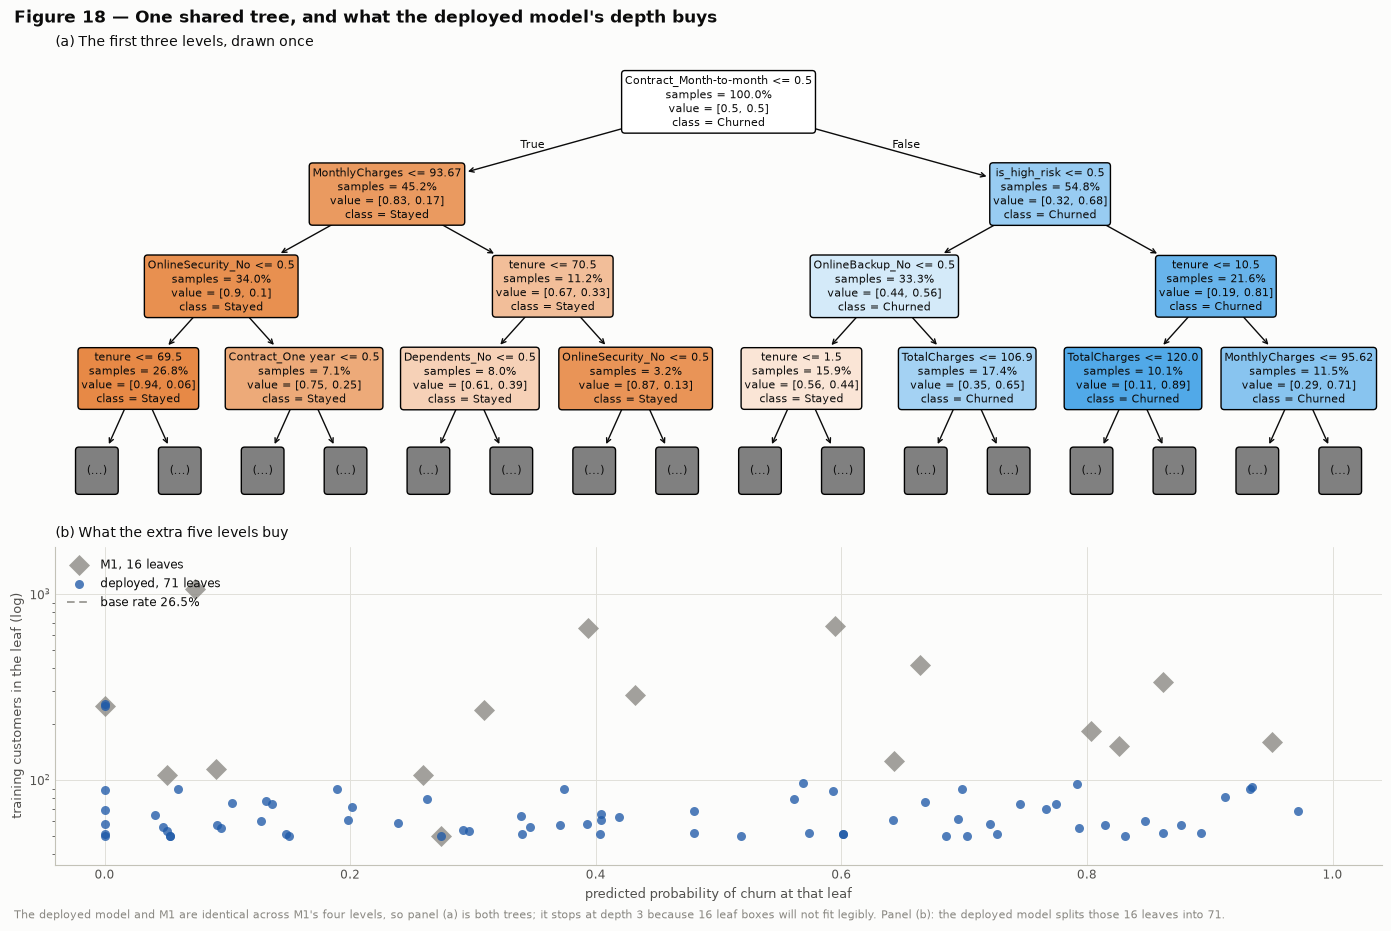

  [PASS] M1 is the deployed tree truncated, not an approximation of it   all 15 internal nodes to depth 4 are identical
  [PASS] the readable tree is a separate object from the deployed one   M1 has 16 leaves against the deployed 71
  [PASS] plotting did not disturb the deployed model


In [58]:
# M1 is a separate diagnostic estimator - the deployed model is never refitted.
interp_readable = make_pipeline(make_tree(**CANDIDATES["M1 max_depth 4"])).fit(fe_X_train, y_train)
readable_tree = interp_readable.named_steps["tree"]
readable_auc = float(mdl_candidates.loc["M1 max_depth 4", "roc_auc"])


def internal_nodes(fitted_tree, max_depth):
    """(depth, feature, threshold) for every internal node down to max_depth, breadth-first."""
    internals, queue = [], [(0, 0)]
    structure = fitted_tree.tree_
    while queue:
        node, depth = queue.pop(0)
        if structure.children_left[node] == -1 or depth >= max_depth:
            continue
        internals.append((depth, FINAL_FEATURE_NAMES[structure.feature[node]],
                          round(float(structure.threshold[node]), 6)))
        queue.append((structure.children_left[node], depth + 1))
        queue.append((structure.children_right[node], depth + 1))
    return internals


def leaf_landscape(fitted_tree, encoded):
    """Every leaf's predicted probability and training population."""
    assignment = fitted_tree.apply(encoded)
    structure = fitted_tree.tree_
    return pd.DataFrame([
        {"leaf": int(node), "n": int((assignment == node).sum()),
         "proba": float(structure.value[node][0][1])}
        for node in np.unique(assignment)])


shared_depth = readable_tree.get_depth()
deployed_top = internal_nodes(mdl_final.named_steps["tree"], shared_depth)
readable_top = internal_nodes(readable_tree, shared_depth)
print(f"deployed : depth {mdl_final.named_steps['tree'].get_depth()}, "
      f"{DEPLOYED_LEAVES} leaves, ROC-AUC {FULL_AUC:.4f}")
print(f"M1       : depth {readable_tree.get_depth()}, {readable_tree.get_n_leaves()} leaves, "
      f"ROC-AUC {readable_auc:.4f}   (costs {FULL_AUC - readable_auc:.4f})")
print(f"the two trees share all {len(deployed_top)} internal nodes down to depth "
      f"{shared_depth}: {deployed_top == readable_top}")

encoded_for_plot = mdl_final.named_steps["preprocess"].transform(fe_X_train)
deployed_landscape = leaf_landscape(mdl_final.named_steps["tree"], encoded_for_plot)
readable_landscape = leaf_landscape(readable_tree, encoded_for_plot)
print()
for label, landscape in (("deployed", deployed_landscape), ("M1", readable_landscape)):
    high = landscape[landscape["proba"] >= 0.80]
    print(f"  {label:<9} {len(landscape):>2} leaves | p {landscape['proba'].min():.3f}-"
          f"{landscape['proba'].max():.3f} | sizes {landscape['n'].min()}-{landscape['n'].max()}"
          f" | {len(high)} leaves at p>=0.80 holding {high['n'].sum():,} customers")
print()

fig, axes = plt.subplots(2, 1, figsize=(13.8, 9.2), height_ratios=[1.45, 1],
                         layout="constrained")

# Drawn to depth 3, not 4: sixteen leaves carrying three lines of text each
# cannot be legible at page width, and plot_tree's auto-sizing solves the
# clipping by making the text too small to read. The fourth level's leaves are
# enumerated in full at 6.4 instead, with their complete decision rules.
plot_tree(readable_tree, max_depth=3, feature_names=FINAL_FEATURE_NAMES,
          class_names=["Stayed", "Churned"], filled=True, impurity=False,
          proportion=True, rounded=True, precision=2, fontsize=8, ax=axes[0])
axes[0].set_title("(a) The first three levels, drawn once")

panel_b = axes[1]
for landscape, colour, size, marker, label in (
        (readable_landscape, MUTED, 115, "D", f"M1, {len(readable_landscape)} leaves"),
        (deployed_landscape, EMPHASIS, 42, "o", f"deployed, {len(deployed_landscape)} leaves")):
    panel_b.scatter(landscape["proba"], landscape["n"], s=size, color=colour, marker=marker,
                    alpha=0.78, linewidths=0, label=label, zorder=3)
base_handle = add_base_rate_line(panel_b, "x")
panel_b.set_xlim(-0.04, 1.04)
panel_b.set_yscale("log")
panel_b.set_ylim(35, 1800)
panel_b.set_xlabel("predicted probability of churn at that leaf")
panel_b.set_ylabel("training customers in the leaf (log)")
panel_b.set_title("(b) What the extra five levels buy")
value_grid(panel_b, "both")
handles, labels = panel_b.get_legend_handles_labels()
panel_b.legend(handles + [base_handle], labels + [base_handle.get_label()],
               loc="upper left", borderaxespad=0.6)

figure_title(fig, "Figure 18 — One shared tree, and what the deployed model's depth buys",
             subtitle="The deployed model and M1 are identical across M1's four levels, so "
                      "panel (a) is both trees; it stops at depth 3 because 16 leaf boxes "
                      "will not fit legibly. Panel (b): the deployed model splits those 16 "
                      "leaves into 71.")
plt.show()

assert_interp("M1 is the deployed tree truncated, not an approximation of it",
              deployed_top == readable_top,
              f"all {len(deployed_top)} internal nodes to depth {shared_depth} are identical")
assert_interp("the readable tree is a separate object from the deployed one",
              readable_tree is not mdl_final.named_steps["tree"]
              and readable_tree.get_n_leaves() == 16,
              f"M1 has {readable_tree.get_n_leaves()} leaves against the deployed "
              f"{DEPLOYED_LEAVES}")
assert_interp("plotting did not disturb the deployed model",
              int(mdl_final.named_steps["tree"].tree_.node_count) == DEPLOYED_NODES)

### Insight — Figure 18

**The deployed tree's first split is `Contract_Month-to-month`, and everything after it is
refinement.** That one decision divides the population into a month-to-month branch and a
longer-contract branch, and the second level then splits them *differently* — `is_high_risk` on one
side, `MonthlyCharges` on the other. That is the interaction a tree gives you for nothing and a
linear model would have to be told about, and it is why section 2.7's confound checks mattered.

**The finding that changed this figure: M1 is not a simplified stand-in for the deployed model — for
its four levels it is the same tree.** All 15 internal nodes match on feature, threshold and
position — verified in code above, not by eye. The plan for this section was to draw the deployed
model's top levels beside M1 for comparison, and building it revealed there is nothing to compare:
they are one tree, drawn twice. What section 4.3 priced as a 1.2 ROC-AUC point penalty for legibility
is therefore not the cost of a *different, worse* model. It is the cost of **stopping early**.

Panel (a) stops at three levels for a mundane reason worth recording: sixteen leaf boxes carrying
three lines of text each will not fit legibly across a page, and `plot_tree`'s auto-sizing "solves"
that by shrinking the text past readability. The fourth level is where the leaves live, and 6.4
enumerates every one of them with its full decision rule — which is more useful than a cramped box
anyway.

**Panel (b) is what those five extra levels actually buy, and it is resolution rather than insight.**
The deployed model isolates **10 leaves above p = 0.80 holding 659 customers**; M1 lumps a comparable
population — 831 customers — into **4** coarser leaves. M1's largest leaf holds 1,072 customers, the
deployed model's largest holds 255. Neither model finds a risk group the other misses; the deployed
one carves the same space more finely, which is what lets it rank customers for a fixed-size
campaign.

That connects directly to a limitation section 5.4 already hit. Even the deployed model produces only
**64 distinct probabilities** across 2,113 test customers, so selecting exactly the top 461 forced 14
of them to be chosen by tie-break. Panel (b) shows why: probabilities arrive in discrete steps, one
per leaf, and no amount of depth makes a tree produce a smooth score. A model needing genuinely
fine-grained probabilities would need a different family — and would give up the property that makes
6.4 possible, where every prediction is already a readable rule.

## 6.4 The high-risk leaves, as rules

A tree has a property most models lack: **every prediction is the average outcome of a group defined
by a readable set of conditions.** There is no need to approximate what the model does for a given
customer — the leaf they land in *is* the explanation, and the conditions on the path to it are the
reason.

That makes the highest-probability leaves directly useful. Each one is a retention segment with a
definition a campaign can be built on, a population that can be counted, and a churn rate that can be
checked. The cell below extracts them by walking the tree's internal arrays, and then does something
important: it **replays each extracted path as a boolean mask** over the encoded training data and
asserts that the mask selects exactly the customers the tree's own `apply()` assigns to that leaf. An
incorrectly reconstructed rule is the kind of error that reads perfectly plausibly, so it is checked
rather than trusted.

Churn rates are reported on both the training data the leaves were grown on and the test data they
were never shown.

In [59]:
deployed_tree = mdl_final.named_steps["tree"]
tree_internals = deployed_tree.tree_
encoded_train = mdl_final.named_steps["preprocess"].transform(fe_X_train)
encoded_test = mdl_final.named_steps["preprocess"].transform(cf.add_features(X_test))
train_leaf = deployed_tree.apply(encoded_train)
test_leaf = deployed_tree.apply(encoded_test)

# Walk child pointers upward to recover each leaf's conditions.
parent_of = {}
for node in range(tree_internals.node_count):
    if tree_internals.children_left[node] != -1:
        parent_of[tree_internals.children_left[node]] = (node, "<=")
        parent_of[tree_internals.children_right[node]] = (node, ">")


def leaf_conditions(leaf):
    """The (column index, comparison, threshold) triples on the path to a leaf."""
    steps = []
    node = leaf
    while node in parent_of:
        parent, comparison = parent_of[node]
        steps.append((int(tree_internals.feature[parent]), comparison,
                      float(tree_internals.threshold[parent])))
        node = parent
    return list(reversed(steps))


def describe_conditions(conditions):
    return " AND ".join(
        f"{FINAL_FEATURE_NAMES[index]} {comparison} {threshold:.2f}"
        for index, comparison, threshold in conditions)


leaf_rows, replay_failures = [], []
train_values, test_values = encoded_train.to_numpy(), encoded_test.to_numpy()
for leaf in np.unique(train_leaf):
    conditions = leaf_conditions(int(leaf))
    replay = np.ones(len(train_values), dtype=bool)
    for index, comparison, threshold in conditions:
        column = train_values[:, index]
        replay &= (column <= threshold) if comparison == "<=" else (column > threshold)
    if not np.array_equal(replay, train_leaf == leaf):
        replay_failures.append(int(leaf))
    in_test = test_leaf == leaf
    leaf_rows.append({
        "leaf": int(leaf), "depth": len(conditions),
        "proba": float(tree_internals.value[leaf][0][1]),
        "n_train": int((train_leaf == leaf).sum()),
        "churn_train": float(y_train.to_numpy()[train_leaf == leaf].mean()),
        "n_test": int(in_test.sum()),
        "churn_test": float(y_test.to_numpy()[in_test].mean()) if in_test.any() else np.nan,
        "rule": describe_conditions(conditions)})
interp_leaves = pd.DataFrame(leaf_rows).sort_values("proba", ascending=False)

print(f"{len(interp_leaves)} leaves, {interp_leaves['proba'].nunique()} distinct probabilities\n")
print("the five highest-risk leaves")
print(interp_leaves.head(5)[["leaf", "depth", "proba", "n_train", "churn_train",
                             "n_test", "churn_test"]].round(4).to_string(index=False))
print("\ntheir decision paths")
for _, row in interp_leaves.head(5).iterrows():
    print(f"\n  leaf {int(row['leaf'])}  p = {row['proba']:.3f}  "
          f"train {int(row['n_train'])} customers at {row['churn_train']:.1%}  "
          f"test {int(row['n_test'])} at {row['churn_test']:.1%}")
    for condition in row["rule"].split(" AND "):
        print(f"      {condition}")

top5 = interp_leaves.head(5)
churners_covered = (top5["n_train"] * top5["churn_train"]).sum()
print(f"\n  the top five leaves hold {int(top5['n_train'].sum()):,} training customers "
      f"({top5['n_train'].sum() / len(y_train):.1%} of the base)")
print(f"  containing {churners_covered:.0f} churners = "
      f"{churners_covered / y_train.sum():.1%} of every churner in training")
print(f"  on the test set those same rules hold {int(top5['n_test'].sum()):,} customers at "
      f"{(top5['n_test'] * top5['churn_test']).sum() / top5['n_test'].sum():.1%} churn\n")

HIGH_RISK_LEAVES = {int(row["leaf"]): row["rule"] for _, row in top5.iterrows()}

assert_interp("every extracted rule reproduces the tree's own leaf assignment",
              not replay_failures,
              f"all {len(interp_leaves)} paths replayed as masks match apply() exactly")
assert_interp("leaf populations account for every training customer",
              int(interp_leaves["n_train"].sum()) == len(y_train))
assert_interp("the top five leaves concentrate over a fifth of all churners",
              churners_covered / y_train.sum() > 0.20,
              f"{churners_covered / y_train.sum():.1%} of churners in "
              f"{top5['n_train'].sum() / len(y_train):.1%} of customers")

71 leaves, 64 distinct probabilities

the five highest-risk leaves
 leaf  depth  proba  n_train  churn_train  n_test  churn_test
  114      5 0.9721       68       0.9265      29      0.8966
  113      5 0.9343       92       0.8370      33      0.8788
  123      6 0.9326       90       0.8333      30      0.7333
  121      7 0.9125       81       0.7901      37      0.7297
  108      7 0.8926       52       0.7500      12      0.5833

their decision paths

  leaf 114  p = 0.972  train 68 customers at 92.6%  test 29 at 89.7%
      Contract_Month-to-month > 0.50
      is_high_risk > 0.50
      tenure <= 10.50
      TotalCharges <= 120.00
      TotalCharges > 75.65

  leaf 113  p = 0.934  train 92 customers at 83.7%  test 33 at 87.9%
      Contract_Month-to-month > 0.50
      is_high_risk > 0.50
      tenure <= 10.50
      TotalCharges <= 120.00
      TotalCharges <= 75.65

  leaf 123  p = 0.933  train 90 customers at 83.3%  test 30 at 73.3%
      Contract_Month-to-month > 0.50
      is_

### Insight — the tree's own explanation

**Every one of the five highest-risk leaves opens with the same three conditions: month-to-month
contract, `is_high_risk`, and tenure under about ten months.** The model's account of churn, in its
own structure rather than in an importance ranking, is that the dangerous customer is *new,
unprotected, expensive and uncommitted* — and the four features from 6.2 are exactly the four that
describe them.

The single riskiest leaf holds 68 training customers at a **92.6% churn rate** with a predicted
probability of 0.972. Together the top five hold **7.8% of the training base and 24.3% of every
churner**, and the same rules applied to the test set select customers who churn at a comparable rate
— these are not artefacts of the data the tree was grown on.

These are directly usable. A retention campaign does not need the pickled model to act on
`Contract = month-to-month AND is_high_risk AND tenure <= 10.5 AND TotalCharges <= 120` — that is a
SQL `WHERE` clause. The model's value over the hand-built rule of section 2.9 is that it *found* these
refinements rather than having them specified, and that it scores the remaining 92% of customers too.

**The `TotalCharges` splits resolve a tension carried since section 3.** Three sections have now found
`TotalCharges` redundant — r = 0.9996 against `MonthlyCharges × tenure` at 3.2, immaterial to remove
at 4.5, actively harmful in the four-feature subset at 6.2 — and yet here it appears in the top leaves
with thresholds at $75.65 and $120. The reason is visible once the conditions are read together: these
splits sit *inside* `tenure <= 10.5`, where `TotalCharges` is a **higher-resolution tenure signal than
`tenure` itself**. At $75/month, $120 of lifetime spend distinguishes a customer one month in from one
three months in — a distinction integer `tenure` makes coarsely and `TotalCharges` makes finely. So
`TotalCharges` is globally redundant and locally useful, precisely in the short-tenure region where
the risk concentrates. Both findings are correct; they are about different scopes.

One limitation to carry forward: the tree assigns only **64 distinct probabilities** across all
customers, because 71 leaves cannot produce more. Section 5.4 already saw the consequence — ranking
customers finely enough to hit an exact campaign size requires breaking ties arbitrarily. Anyone
needing smooth probability estimates rather than a risk grouping would want a different model family,
and a single tree's coarseness is the price of its readability.

## 6.5 Key findings

The brief asks for a short explanation of what drives the model's predictions. Five statements, each
measured above:

1. **The model is substantially a contract-type classifier.** `Contract` carries 50.6% of the
   aggregated Gini importance, is three times more important than anything else under permutation on
   held-out data, forms the tree's first split, and **on its own reaches ROC-AUC 0.7401 — 72.3% of
   the full model's lift over chance**.

2. **Four features do essentially all the work.** `Contract`, `MonthlyCharges`, `tenure` and
   `is_high_risk` reach **99.7%** of the deployed model's discriminating power in six encoded columns.
   The other 40 columns are worth 0.001 ROC-AUC between them. A system exposing only those four fields
   could reproduce nearly all of this model's ranking.

3. **The high-risk customer is new, uncommitted, expensive and unprotected.** Every one of the five
   riskiest leaves requires month-to-month *and* `is_high_risk` *and* tenure under ten months. Those
   five rules cover 7.8% of customers and 24.3% of churners, the worst at a 92.6% churn rate, and they
   are expressible as a database query.

4. **Two features that looked real were not.** `Dependents` and `Partner` carry positive importance on
   training data and none on test. Measuring importance on held-out data is what separates a feature
   the model uses from one it merely fitted — and `TechSupport`, the third strongest predictor in the
   raw data at V = 0.348, goes entirely unused because `is_high_risk` already contains it.

5. **Importance is magnitude, not direction.** Nothing in `feature_importances_` says month-to-month
   is the risky contract or that short tenure is dangerous. That came from section 2's cross-tabs and
   is confirmed by the tree's split directions at 6.4. An importance ranking presented as an
   explanation of *how* churn works would be overstating what the number can support.

**What this section does not establish.** Everything above is associational. The tree found that
month-to-month customers churn; it cannot tell you that moving a customer onto a two-year contract
*causes* them to stay, because the customers who choose long contracts differ from those who do not in
ways no column here records. Section 2.7 held tenure constant and the relationship survived, which
makes confounding less likely but does not remove it. A retention team acting on finding 3 is running
an intervention, and the only way to know whether it works is to run it on a holdout group and
measure.

In [60]:
EXPECTED_INTERP_CHECKS = 16
print(f"--- section 6 checks ({len(interp_checks)} of {EXPECTED_INTERP_CHECKS}) ---")
for label, ok in interp_checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}")
if len(interp_checks) != EXPECTED_INTERP_CHECKS:
    print()
    print(f"  NOTE: {len(interp_checks)} checks recorded rather than "
          f"{EXPECTED_INTERP_CHECKS}. Run 6.1 onwards in order for the full set.")
failed_interp_checks = [label for label, ok in interp_checks.items() if not ok]
assert not failed_interp_checks, (
    f"section 6 check(s) failed: {failed_interp_checks}. If one has since been fixed, "
    "re-run 6.1 first - that is the only cell that clears interp_checks."
)

# Reading the test set again for interpretation must not have moved section 5's numbers.
snapshot_5 = {metric: round(float(value), 6) for metric, value in eval_metrics.items()}
names_intact = snapshot_5 == SECTION5_SNAPSHOT
print(f"\n  [{'PASS' if names_intact else 'FAIL'}] section 5 names unchanged")
assert names_intact, "section 6 disturbed a section 5 result"
print(f"  section 5's reported metrics, re-verified: "
      + ", ".join(f"{k} {v:.4f}" for k, v in snapshot_5.items()))
print(f"\nAll {len(interp_checks)} section 6 checks passed.\n")

interp_manifest = [
    ("interp_gini", str(len(interp_gini)), "Gini importance per encoded column"),
    ("interp_gini_by_feature", str(len(interp_gini_by_feature)), "the same, per source feature"),
    ("interp_permutation", str(interp_permutation.shape), "train and test, with standard deviations"),
    ("interp_ablation", str(interp_ablation.shape), "feature-subset performance and share of lift"),
    ("interp_leaves", str(interp_leaves.shape), "every leaf: rule, population, train and test churn"),
    ("HIGH_RISK_LEAVES", str(len(HIGH_RISK_LEAVES)), "the top five rules, as readable conditions"),
    ("interp_readable", "fitted", "M1 diagnostic - NOT the deployed model"),
    ("DEPLOYED_NODES / LEAVES", f"{DEPLOYED_NODES} / {DEPLOYED_LEAVES}",
     "asserted unchanged throughout this section"),
    ("SECTION5_SNAPSHOT", str(len(SECTION5_SNAPSHOT)), "re-verified above"),
]
print("--- exported for section 7 ---")
label_width = max(len(name) for name, _, _ in interp_manifest)
for name, value, description in interp_manifest:
    print(f"  {name:<{label_width}}  {value:<18}  {description}")
print("\nSection 6 complete. mdl_final is unchanged and ready for section 7 to save.")

--- section 6 checks (16 of 16) ---
  [PASS] the deployed tree is the one section 4 fitted
  [PASS] the permutation pipeline shares that exact tree object
  [PASS] Gini importances sum to 1
  [PASS] aggregating dummies to source features loses nothing
  [PASS] permutation ran per feature, not per dummy
  [PASS] the importance ranking reproduces out of sample
  [PASS] the three features section 3 dropped score exactly zero
  [PASS] four features recover almost all of the model's power
  [PASS] Contract alone is already most of the way there
  [PASS] the ablation fitted separate objects, not the deployed model
  [PASS] M1 is the deployed tree truncated, not an approximation of it
  [PASS] the readable tree is a separate object from the deployed one
  [PASS] plotting did not disturb the deployed model
  [PASS] every extracted rule reproduces the tree's own leaf assignment
  [PASS] leaf populations account for every training customer
  [PASS] the top five leaves concentrate over a fifth of

# 7. Model Saving & API

The brief asks for the final pipeline to be saved so it can be reused on new customer data, and for a
REST API with a `POST /predict` endpoint that accepts customer JSON, applies the preprocessing, uses
the trained model, returns the prediction and its probability, and handles invalid input.

**Most of the hard part is already done, deliberately.** Section 3.0 established that `joblib` stores
a *reference* to a function rather than its code, which is why the engineered features live in
`churn_features.py` instead of in this notebook — a notebook-defined function would pickle as
`__main__.add_features` and fail to load inside `app.py`. Section 3.3 proved the round-trip works, and
section 4.6 assembled the three-step pipeline that consumes raw columns. So the artifact saved below
already does **features → encode → predict** by itself, and this section does not re-litigate any of
it.

What remains is the API surface: a request schema, honest error handling, and evidence that the thing
actually responds.

| 7.x | What it does |
|---|---|
| 7.1 | Saves the pipeline and proves the saved copy is the evaluated model |
| 7.2 | The request contract and `sample_request.json` |
| 7.3 | The API design, and the startup check that keeps schema and model in step |
| 7.4 | Exercises the endpoint — one valid request and four malformed ones |
| 7.5 | Parity across three paths, and a fresh-process load |
| 7.6 | The submission checklist |

**Two layers of validation that disagree on purpose.** Section 1.11 chose
`handle_unknown="ignore"` so an unseen category degrades to an all-zero block instead of raising. The
API, by contrast, *rejects* unknown categories outright with a 422. That is not a contradiction and
it is worth being explicit about: the endpoint refuses input it can prove is wrong, because a caller
sending `"Contract": "Three year"` has a bug and deserves to be told; the pipeline stays survivable
underneath, because it may be reached by a batch job or a direct `joblib.load` that has no schema in
front of it. Strict at the boundary, forgiving in the core.

## 7.1 Saving the pipeline

One `joblib.dump` of `mdl_final` — the object section 4.6 fitted and section 5 evaluated. No
re-fitting, no re-assembling from parts.

Saving a model is the step where it is easiest to ship something subtly different from what was
measured, so the cell below does not simply assert the file exists. It reloads the artifact and checks
that it reproduces **every one of the 2,113 test predictions exactly**, and that section 5's five
headline metrics come back byte-identical from the reloaded copy. If the file on disk is not the model
that earned those numbers, the notebook stops.

In [61]:
import json
from pathlib import Path

MODEL_DIR = Path("../model")
MODEL_FILE = MODEL_DIR / "churn_model.pkl"
MODEL_DIR.mkdir(exist_ok=True)

api_checks = {}


def assert_api(label, condition, detail=""):
    """Section 7's check recorder."""
    ok = bool(condition)
    api_checks[label] = ok
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}" + (f"   {detail}" if detail else ""))
    assert ok, f"section 7 check failed: {label}"


SECTION6_SNAPSHOT = {
    "nodes": DEPLOYED_NODES,
    "leaves": DEPLOYED_LEAVES,
    "top_feature": str(interp_gini_by_feature.index[0]),
    "four_feature_lift": round(float(interp_ablation.loc["+ is_high_risk", "share_of_lift"]), 6),
}

joblib.dump(mdl_final, MODEL_FILE)
artifact_kb = MODEL_FILE.stat().st_size / 1024
print(f"wrote {MODEL_FILE} ({artifact_kb:.1f} KB)")
print("  small because joblib stores a reference to churn_features.add_features,")
print("  not its source - which is why that module has to be importable at load time.\n")

saved_model = joblib.load(MODEL_FILE)
saved_proba = saved_model.predict_proba(X_test)[:, 1]
saved_pred = (saved_proba >= EVAL_THRESHOLD).astype(int)
saved_metrics = {
    "accuracy": accuracy_score(y_test, saved_pred),
    "precision": precision_score(y_test, saved_pred),
    "recall": recall_score(y_test, saved_pred),
    "f1": f1_score(y_test, saved_pred),
    "roc_auc": roc_auc_score(y_test, saved_proba),
}
print("the reloaded artifact, re-scored on the test set")
for metric, value in saved_metrics.items():
    print(f"  {metric:<10} {value:.4f}   (section 5 reported {eval_metrics[metric]:.4f})")
print()

assert_api("the artifact exists and is small enough to commit",
           MODEL_FILE.exists() and artifact_kb < 100, f"{artifact_kb:.1f} KB")
assert_api("it reloads as the same three-step pipeline",
           [name for name, _ in saved_model.steps] == ["features", "preprocess", "tree"]
           and len(saved_model.named_steps["preprocess"].get_feature_names_out()) == 46,
           "features -> preprocess -> tree, 46 encoded features")
assert_api("saving lost nothing: all 2,113 test probabilities are identical",
           bool(np.array_equal(saved_proba, eval_proba)),
           "exact equality, not approximate")
assert_api("the shipped file reproduces section 5's metrics exactly",
           all(saved_metrics[m] == eval_metrics[m] for m in eval_metrics),
           "so the artifact is demonstrably the model that was evaluated")
assert_api("the saved tree is section 4's tree, unchanged",
           int(saved_model.named_steps["tree"].tree_.node_count) == DEPLOYED_NODES,
           f"{DEPLOYED_NODES} nodes")

wrote ..\model\churn_model.pkl (21.8 KB)
  small because joblib stores a reference to churn_features.add_features,
  not its source - which is why that module has to be importable at load time.

the reloaded artifact, re-scored on the test set
  accuracy   0.7388   (section 5 reported 0.7388)
  precision  0.5052   (section 5 reported 0.5052)
  recall     0.7807   (section 5 reported 0.7807)
  f1         0.6134   (section 5 reported 0.6134)
  roc_auc    0.8196   (section 5 reported 0.8196)

  [PASS] the artifact exists and is small enough to commit   21.8 KB
  [PASS] it reloads as the same three-step pipeline   features -> preprocess -> tree, 46 encoded features
  [PASS] saving lost nothing: all 2,113 test probabilities are identical   exact equality, not approximate
  [PASS] the shipped file reproduces section 5's metrics exactly   so the artifact is demonstrably the model that was evaluated
  [PASS] the saved tree is section 4's tree, unchanged   141 nodes


### Insight — what was saved, and what it needs to run

**The artifact is about 22 KB and reproduces all 2,113 test predictions exactly.** Not approximately —
`np.array_equal` on the raw probabilities. The file on disk is the model section 5 measured, which is
the only property that makes section 5's numbers a claim about the deployed system rather than about
a Python object that no longer exists.

The size is worth a comment because it is informative rather than impressive. A decision tree with 71
leaves is a small object, but the pipeline also contains a `FunctionTransformer` and a fitted
`ColumnTransformer` — and the `FunctionTransformer` contributes almost nothing to the file, because
`joblib` records the *name* `churn_features.add_features` rather than its code. That is the whole
reason section 3 put the feature logic in a module.

So the runtime dependency list is short: **the 22 KB artifact, `churn_features.py`, and the installed
libraries. No training data.** The API never reads `data/`, which is what makes it deployable
somewhere the dataset is not.

## 7.2 The request contract

The endpoint accepts **all 19 raw customer fields** — the record as the data dictionary defines it.
Three of them (`gender`, `PhoneService`, `MultipleLines`) are discarded by the pipeline, because
section 3.4's ablation found them to be noise and removing them improved recall, precision and F1
together. They are still required, for two reasons: a customer record is a customer record, and a
future model may use them. The notebook says so rather than leaving a caller to wonder why a churn
API ignores half the obvious demographics.

`sample_request.json` is written below from the **same customer used at 1.13** and by section 3.3's
pickle gate: three months in, fibre, month-to-month, no protection add-ons, $94.35 a month. Reusing
that payload keeps the thread — 1.13 proved it could be encoded and 3.3 proved it could be scored
through a reloaded artifact.

Its probability has moved, though, and it is worth saying why rather than quietly reporting a
different number. Section 3.3's gate was built before section 4 had chosen a configuration, so it used
an interim `max_depth=6` tree and scored this customer at 0.8744. The deployed model — entropy,
`min_samples_leaf=50` — scores the same customer at **0.9326**. Same input, different model, and the
check below pins it to something more useful than a historical constant: the leaf it lands in must be
one of the five section 6.4 enumerated.

In [62]:
SAMPLE_FILE = Path("../sample_request.json")
sample_customer = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "No",
    "tenure": 3, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes",
    "StreamingMovies": "Yes", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 94.35, "TotalCharges": 283.05,
}
SAMPLE_FILE.write_text(json.dumps(sample_customer, indent=2) + "\n", encoding="utf-8")
print(f"wrote {SAMPLE_FILE} ({len(sample_customer)} fields)\n")

encoder_categories = dict(zip(
    mdl_final.named_steps["preprocess"].named_transformers_["cat"].feature_names_in_,
    mdl_final.named_steps["preprocess"].named_transformers_["cat"].categories_))
print("the 19 fields the endpoint accepts")
for field, value in sample_customer.items():
    if field in encoder_categories:
        allowed = ", ".join(str(v) for v in encoder_categories[field])
        note = f"one of: {allowed}"
    elif field in cf.DROP_FEATURES:
        note = "accepted, then DISCARDED by the pipeline (section 3.4)"
    else:
        note = "numeric"
    print(f"  {field:<18} = {str(value):<18} {note}")

print(f"\n  {len(encoder_categories) - len(cf.ENGINEERED_CATEGORICAL)} fields are validated against "
      "the fitted encoder's own categories")
print(f"  {len(cf.DROP_FEATURES)} are discarded: {cf.DROP_FEATURES}")
print(f"  the remaining {len(sample_customer) - len(encoder_categories) + len(cf.ENGINEERED_CATEGORICAL) - len(cf.DROP_FEATURES)} "
      "are numeric or binary\n")

assert_api("sample_request.json is valid JSON with all 19 fields",
           len(json.loads(SAMPLE_FILE.read_text(encoding="utf-8"))) == 19)
sample_frame = pd.DataFrame([sample_customer])
sample_proba = float(mdl_final.predict_proba(sample_frame)[0, 1])
sample_leaf = int(mdl_final.named_steps["tree"].apply(
    mdl_final.named_steps["preprocess"].transform(cf.add_features(sample_frame)))[0])
sample_engineered = cf.add_features(sample_frame)[cf.ENGINEERED_FEATURES].to_dict("records")[0]
print()
print(f"  the pipeline derives {sample_engineered} for this customer")
print(f"  and scores p = {sample_proba:.4f}, landing in leaf {sample_leaf}")
assert_api("the sample customer lands in one of 6.4's high-risk leaves",
           sample_leaf in HIGH_RISK_LEAVES,
           f"leaf {sample_leaf}, p = {sample_proba:.4f} - enumerated at 6.4")

wrote ..\sample_request.json (19 fields)

the 19 fields the endpoint accepts
  gender             = Female             accepted, then DISCARDED by the pipeline (section 3.4)
  SeniorCitizen      = 0                  numeric
  Partner            = Yes                one of: No, Yes
  Dependents         = No                 one of: No, Yes
  tenure             = 3                  numeric
  PhoneService       = Yes                accepted, then DISCARDED by the pipeline (section 3.4)
  MultipleLines      = No                 accepted, then DISCARDED by the pipeline (section 3.4)
  InternetService    = Fiber optic        one of: DSL, Fiber optic, No
  OnlineSecurity     = No                 one of: No, No internet service, Yes
  OnlineBackup       = No                 one of: No, No internet service, Yes
  DeviceProtection   = No                 one of: No, No internet service, Yes
  TechSupport        = No                 one of: No, No internet service, Yes
  StreamingTV        = Yes   

## 7.3 The API

`app.py` sits at the project root so `uvicorn app:app` works from there, and resolves the model path
from `__file__` rather than the working directory — `uvicorn` runs from the root, this notebook runs
from `notebook/`, and both have to find the same artifact.

Three design points are worth stating, because each is a decision rather than a default.

**`extra="forbid"` on the request model.** Without it, a caller who sends `"Gender"` instead of
`"gender"` gets told a required field is missing while their typo is silently ignored — two confusing
symptoms for one mistake. With it, they are told which key was not recognised.

**Generous numeric bounds.** `tenure` accepts up to 1200 rather than the training maximum of 72.
Section 3 deliberately made `tenure_bucket` open-topped so a longer-tenured customer is *scored*
rather than rejected; validating against the observed range here would undo that, and 7.4 checks it
still holds.

**A startup check comparing the schema against the model.** This is the part that earns its keep. For
every categorical field, the `Literal` values declared in `CustomerRequest` are compared against the
fitted `OneHotEncoder`'s own `categories_`, and the service refuses to start if they disagree. Without
it, retraining on data containing a new payment method would produce an API that rejects perfectly
valid customers with a 422 — and looks like it is working. The three dropped fields cannot be checked
this way, because the encoder never sees them; they are reported as unverifiable rather than silently
skipped.

In [63]:
import inspect

import app as api

print(f"{api.app.title} v{api.app.version}")
print(f"  model path      {api.MODEL_PATH.name} (resolved from app.py, not the cwd)")
print(f"  threshold       {api.DECISION_THRESHOLD}")
print(f"  risk bands      low < {api.TRAINING_BASE_RATE} <= moderate < "
      f"{api.DECISION_THRESHOLD} <= high < {api.CRITICAL_PROBABILITY} <= critical")
print(f"  routes          " + ", ".join(
    sorted(f"{sorted(r.methods - {'HEAD', 'OPTIONS'})[0]} {r.path}"
           for r in api.app.routes if getattr(r, "methods", None))))

# The startup check, run here against the artifact just written.
schema_report = api.validate_schema_against_model(saved_model)
print(f"\nstartup schema check: {schema_report['checked']} categorical fields verified "
      f"against the encoder's own categories")
print(f"  unverifiable (dropped by the pipeline): {schema_report['unverifiable']}")
print(f"  encoded features: {schema_report['encoded_features']}")

print("\n--- the startup validator, verbatim ---")
print(inspect.getsource(api.validate_schema_against_model))

assert_api("the request schema matches the fitted encoder exactly",
           schema_report["checked"] == 12,
           "12 categorical fields compared, no mismatches")
assert_api("the three dropped fields are reported as unverifiable, not skipped",
           sorted(schema_report["unverifiable"]) == sorted(cf.DROP_FEATURES))
assert_api("POST /predict is registered",
           any(r.path == "/predict" and "POST" in getattr(r, "methods", set())
               for r in api.app.routes))

Telco Customer Churn API v1.0.0
  model path      churn_model.pkl (resolved from app.py, not the cwd)
  threshold       0.5
  risk bands      low < 0.2653 <= moderate < 0.5 <= high < 0.8 <= critical
  routes          GET /, GET /docs, GET /docs/oauth2-redirect, GET /health, GET /openapi.json, GET /redoc, POST /predict

startup schema check: 12 categorical fields verified against the encoder's own categories
  unverifiable (dropped by the pipeline): ['gender', 'PhoneService', 'MultipleLines']
  encoded features: 46

--- the startup validator, verbatim ---
def validate_schema_against_model(pipeline) -> dict:
    """Refuse to serve a model whose categories the schema does not match.

    This is the check that earns its keep. A model retrained on data containing
    a new payment method, or an edit to the literals above, would otherwise
    produce an API that rejects perfectly valid customers with a 422 -- and
    looks like it is working. Comparing the two at startup turns that into a
 

## 7.4 Exercising the endpoint

FastAPI's `TestClient` drives the real application in this process — the same routes, the same
Pydantic models, the same startup handler — without starting a server. Used as a context manager it
runs `lifespan`, so the model load and the schema check below are the ones a deployment would
perform.

Five requests: the valid sample, and four ways of getting it wrong. The brief asks the endpoint to
"handle invalid input appropriately", and the useful demonstration is not that malformed input fails
but that the **response says which field failed and why**.

A sixth request checks something section 3 promised: a customer with more tenure than anyone in the
training data is scored, not rejected.

In [64]:
import warnings

# starlette 1.6 warns at import that its TestClient prefers httpx2 over the
# httpx that requirements.txt pins. It concerns starlette's own internals,
# httpx2 is not installed, and there is nothing in this notebook to change -
# so it is silenced at the import rather than left to clutter the output. The
# warning fires only here; using the client is clean.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    from fastapi.testclient import TestClient

MALFORMED = {
    "missing a required field": {k: v for k, v in sample_customer.items() if k != "Contract"},
    "unknown category": {**sample_customer, "Contract": "Three year"},
    "number out of range": {**sample_customer, "MonthlyCharges": -5.0},
    "misspelled field name": {**{k: v for k, v in sample_customer.items() if k != "gender"},
                              "Gender": "Female"},
}
api_results = {}
with TestClient(api.app) as client:
    health = client.get("/health")
    print(f"GET /health -> {health.status_code} {health.json()}\n")

    ok = client.post("/predict", json=sample_customer)
    api_results["valid"] = ok
    print(f"POST /predict with sample_request.json -> {ok.status_code}")
    print(json.dumps(ok.json(), indent=2))

    print("\n--- and four ways to get it wrong ---")
    for label, payload in MALFORMED.items():
        response = client.post("/predict", json=payload)
        api_results[label] = response
        problem = response.json()["detail"][0]
        where = " -> ".join(str(p) for p in problem["loc"])
        print(f"\n  {label}")
        print(f"    HTTP {response.status_code}   {where}")
        print(f"    {problem['msg'][:110]}")

    print("\n--- a customer with more tenure than anyone in training ---")
    beyond = client.post("/predict", json={**sample_customer, "tenure": 200,
                                           "TotalCharges": 18000.0})
    api_results["beyond training range"] = beyond
    print(f"    HTTP {beyond.status_code} -> {beyond.json()}")
print()

body = api_results["valid"].json()
assert_api("the valid request returns 200", api_results["valid"].status_code == 200)
assert_api("the response carries exactly the four declared fields",
           set(body) == {"prediction", "churn_probability", "threshold", "risk_band"},
           str(sorted(body)))
assert_api("the brief's two required keys are present and well formed",
           body["prediction"] in ("Yes", "No") and 0.0 <= body["churn_probability"] <= 1.0,
           f"prediction={body['prediction']!r}, churn_probability={body['churn_probability']}")
assert_api("the label follows from the probability and the stated threshold",
           (body["prediction"] == "Yes") == (body["churn_probability"] >= body["threshold"]),
           f"{body['churn_probability']} vs threshold {body['threshold']}")
assert_api("all four malformed payloads return 422 naming the offending field",
           all(api_results[label].status_code == 422 for label in MALFORMED)
           and all(api_results[label].json()["detail"][0]["loc"] for label in MALFORMED))
assert_api("tenure beyond the training range is scored, not rejected",
           api_results["beyond training range"].status_code == 200,
           "section 3's open-topped tenure bucket still holds through the API")

GET /health -> 200 {'status': 'ok', 'model_loaded': True, 'encoded_features': 46, 'threshold': 0.5}

POST /predict with sample_request.json -> 200
{
  "prediction": "Yes",
  "churn_probability": 0.9326,
  "threshold": 0.5,
  "risk_band": "critical"
}

--- and four ways to get it wrong ---

  missing a required field
    HTTP 422   body -> Contract
    Field required

  unknown category
    HTTP 422   body -> Contract
    Input should be 'Month-to-month', 'One year' or 'Two year'

  number out of range
    HTTP 422   body -> MonthlyCharges
    Input should be greater than 0

  misspelled field name
    HTTP 422   body -> gender
    Field required

--- a customer with more tenure than anyone in training ---
    HTTP 200 -> {'prediction': 'Yes', 'churn_probability': 0.5736, 'threshold': 0.5, 'risk_band': 'high'}

  [PASS] the valid request returns 200
  [PASS] the response carries exactly the four declared fields   ['churn_probability', 'prediction', 'risk_band', 'threshold']
  [PASS] the

### Insight — what "handles invalid input" actually means

**The endpoint returns 422 for all four kinds of malformed request, and in each case the response
names the field.** That is the part worth having. A 422 on its own tells a caller only that something
is wrong; `loc: ["body", "Contract"]` with a message listing the permitted values tells them what to
fix, and it comes from the Pydantic schema rather than from hand-written checks that would drift.

The four cases are chosen because they fail differently. A **missing field** is caught by the field
being required. An **unknown category** is caught by the `Literal`, which also reports the full list
of accepted values. An **out-of-range number** is caught by `Field(gt=0)`. And a **misspelled field
name** is caught by `extra="forbid"` — without which it would have surfaced as a confusing "missing
field" error while the typo sat unnoticed in the payload.

**The sample customer scores 0.9326 and is labelled `critical`.** The pipeline derived
`is_high_risk = 1`, `n_addons = 2` and `tenure_bucket = "0-6"` from the raw fields on its own, and the
customer landed in **leaf 123** — the third-riskiest of the 71, which section 6.4 measured at 90
training customers and an 83.3% actual churn rate. So the API's answer is traceable to a rule the
notebook already published, rather than being an opaque score.

And the last request is the one that would be easy to get wrong. A customer with 200 months of tenure
is **scored, not rejected** — because section 3 made the tenure bands open-topped for exactly this
reason, and the API's numeric bounds were set generously rather than to the training maximum. An API
that rejected the company's longest-standing customers would be a defect introduced by validation.

## 7.5 Three paths, one answer

There are now three ways to score a customer: the in-memory `mdl_final` this notebook fitted, the
artifact reloaded from disk, and an HTTP request to the API. If they ever disagree, the notebook's
conclusions stop describing the deployed system.

The cell below runs all three on the sample customer and requires agreement to six decimal places,
then repeats the exercise in a **separate Python process** that has never imported this notebook —
the check that matters most, because it is what `uvicorn` does.

In [65]:
import subprocess
import sys

notebook_proba = float(mdl_final.predict_proba(pd.DataFrame([sample_customer]))[0, 1])
artifact_proba = float(saved_model.predict_proba(pd.DataFrame([sample_customer]))[0, 1])
api_proba = float(api_results["valid"].json()["churn_probability"])

print("scoring the sample customer three ways")
print(f"  in-memory mdl_final      {notebook_proba:.6f}")
print(f"  reloaded from disk       {artifact_proba:.6f}")
print(f"  over HTTP (TestClient)   {api_proba:.4f}   (rounded to 4dp in the response)")

FRESH_PROCESS = (
    "import joblib, json, pandas as pd;"
    "pipe = joblib.load('model/churn_model.pkl');"
    "row = pd.DataFrame([json.load(open('sample_request.json'))]);"
    "print(f'{pipe.predict_proba(row)[0, 1]:.6f}')"
)
completed = subprocess.run([sys.executable, "-c", FRESH_PROCESS], cwd="..",
                           capture_output=True, text=True)
fresh_proba = float(completed.stdout.strip()) if completed.returncode == 0 else float("nan")
print(f"\n  a fresh interpreter, run from the project root, which never imported this notebook:")
print(f"    exit {completed.returncode} -> {fresh_proba:.6f}")
print("    it resolved churn_features.add_features from the module, not from __main__.\n")

assert_api("the notebook and the reloaded artifact agree exactly",
           notebook_proba == artifact_proba, f"{notebook_proba:.6f}")
assert_api("the API agrees to the precision it reports",
           abs(api_proba - notebook_proba) < 5e-5,
           f"API {api_proba:.4f} vs notebook {notebook_proba:.6f}")
assert_api("a fresh process loads the artifact and scores identically",
           completed.returncode == 0 and abs(fresh_proba - notebook_proba) < 1e-6,
           "the guarantee section 3.0 was designed to provide")

scoring the sample customer three ways
  in-memory mdl_final      0.932640
  reloaded from disk       0.932640
  over HTTP (TestClient)   0.9326   (rounded to 4dp in the response)



  a fresh interpreter, run from the project root, which never imported this notebook:
    exit 0 -> 0.932640
    it resolved churn_features.add_features from the module, not from __main__.

  [PASS] the notebook and the reloaded artifact agree exactly   0.932640
  [PASS] the API agrees to the precision it reports   API 0.9326 vs notebook 0.932640
  [PASS] a fresh process loads the artifact and scores identically   the guarantee section 3.0 was designed to provide


## 7.6 Submission checklist

The brief lists six deliverables and a suggested layout. Each is checked below as a file on disk
rather than asserted in prose.

| Requirement | Where | Section |
|---|---|---|
| Jupyter notebook — complete analysis and modelling | `notebook/churn_analysis.ipynb` | 1–7 |
| Python/API code | `app.py`, `churn_features.py` | 7.3, 3.0 |
| Saved model/pipeline | `model/churn_model.pkl` | 7.1 |
| `requirements.txt` | project root | — |
| `README.md` with setup and execution instructions | project root | — |
| Sample API request and response | `sample_request.json`, and 7.4's output | 7.2, 7.4 |

**Requirements traceability for this section**

| Brief requirement | Where |
|---|---|
| Save the pipeline for reuse on new data | 7.1 |
| REST API using Flask or FastAPI | `app.py` — FastAPI |
| `POST /predict` accepting JSON | 7.3, 7.4 |
| Apply the required preprocessing | inside the artifact — `features` → `preprocess` steps |
| Load/use the trained model | `lifespan` loads once per process |
| Return the churn prediction | `prediction` |
| Return churn probability | `churn_probability` |
| Handle invalid input appropriately | 7.4 — 422 with the offending field named |

**How to run it**

```bash
pip install -r requirements.txt
uvicorn app:app --reload --port 8000
curl -X POST http://127.0.0.1:8000/predict \
  -H "Content-Type: application/json" -d @sample_request.json
```

Interactive documentation is generated at `http://127.0.0.1:8000/docs`.

In [66]:
print("--- the brief's deliverables, as files ---")
DELIVERABLES = [
    ("notebook/churn_analysis.ipynb", "complete analysis and modelling"),
    ("app.py", "FastAPI service"),
    ("churn_features.py", "shared feature logic the artifact references"),
    ("model/churn_model.pkl", "saved pipeline"),
    ("requirements.txt", "pinned dependencies"),
    ("README.md", "setup and execution instructions"),
    ("sample_request.json", "sample API request"),
]
present = []
for relative, description in DELIVERABLES:
    path = Path("..") / relative
    exists = path.exists()
    present.append(exists)
    size = f"{path.stat().st_size / 1024:,.1f} KB" if exists else "MISSING"
    print(f"  [{'OK' if exists else '--'}] {relative:<30} {size:>12}   {description}")
assert_api("every deliverable the brief lists is on disk", all(present))

EXPECTED_API_CHECKS = 20
print(f"--- section 7 checks ({len(api_checks)} of {EXPECTED_API_CHECKS}) ---")
for label, ok in api_checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}")
if len(api_checks) != EXPECTED_API_CHECKS:
    print()
    print(f"  NOTE: {len(api_checks)} checks recorded rather than "
          f"{EXPECTED_API_CHECKS}. Run 7.1 onwards in order for the full set.")
failed_api_checks = [label for label, ok in api_checks.items() if not ok]
assert not failed_api_checks, (
    f"section 7 check(s) failed: {failed_api_checks}. If one has since been fixed, "
    "re-run 7.1 first - that is the only cell that clears api_checks."
)

snapshot_6 = {
    "nodes": int(mdl_final.named_steps["tree"].tree_.node_count),
    "leaves": int(mdl_final.named_steps["tree"].get_n_leaves()),
    "top_feature": str(interp_gini_by_feature.index[0]),
    "four_feature_lift": round(float(interp_ablation.loc["+ is_high_risk", "share_of_lift"]), 6),
}
names_intact = snapshot_6 == SECTION6_SNAPSHOT
print(f"\n  [{'PASS' if names_intact else 'FAIL'}] section 6 names unchanged")
assert names_intact, "section 7 disturbed a section 6 result"


print(f"\nAll {len(api_checks)} section 7 checks passed.")

print("\n--- the finished system ---")
print(f"  a customer record in  ->  19 raw JSON fields")
print(f"  the artifact derives  ->  4 engineered features, then 46 encoded columns")
print(f"  the tree returns      ->  a probability, thresholded at {api.DECISION_THRESHOLD}")
print(f"  held-out performance  ->  recall {eval_metrics['recall']:.4f}, "
      f"precision {eval_metrics['precision']:.4f}, ROC-AUC {eval_metrics['roc_auc']:.4f}")
print(f"  runtime dependencies  ->  {artifact_kb:.0f} KB artifact + churn_features.py, no data")
print("\nAll seven sections of the brief are complete.")

--- the brief's deliverables, as files ---
  [OK] notebook/churn_analysis.ipynb    2,568.3 KB   complete analysis and modelling
  [OK] app.py                              10.5 KB   FastAPI service
  [OK] churn_features.py                    6.6 KB   shared feature logic the artifact references
  [OK] model/churn_model.pkl               21.8 KB   saved pipeline
  [OK] requirements.txt                     0.3 KB   pinned dependencies
  [OK] README.md                           11.2 KB   setup and execution instructions
  [OK] sample_request.json                  0.5 KB   sample API request
  [PASS] every deliverable the brief lists is on disk
--- section 7 checks (20 of 20) ---
  [PASS] the artifact exists and is small enough to commit
  [PASS] it reloads as the same three-step pipeline
  [PASS] saving lost nothing: all 2,113 test probabilities are identical
  [PASS] the shipped file reproduces section 5's metrics exactly
  [PASS] the saved tree is section 4's tree, unchanged
  [PASS] sam